<div style="background:#0f2942;color:#faf6ef;padding:28px 32px;border-radius:14px">
<div style="font-size:13px;letter-spacing:.18em;opacity:.75">TCC · TURMA FLY · GRUPO 1 - WE CAN FLY</div>
<div style="font-size:30px;font-weight:700;line-height:1.2;margin:8px 0 10px">Quanto a renda do trabalho muda conforme gênero e raça no Brasil</div>
<div style="font-size:15px;opacity:.9;max-width:70ch">PNAD Contínua 2022 (IBGE) · problema de regressão · da leitura da base até o modelo final, passo a passo.</div>
</div>

## Antes de tudo: como este notebook está organizado

Este notebook foi escrito para ser **lido**, não só executado. Cada bloco de código vem
com duas coisas: um aviso do **que vamos fazer** antes, e um **como ler o resultado** depois.
Se você nunca viu um projeto de dados, dá para acompanhar do começo ao fim sem pular nada.

| Parte | O que acontece aqui | Por que ela existe |
|---|---|---|
| **0** | Ambiente e identidade visual | Todo gráfico do trabalho sai com a mesma cara |
| **1** | Carregar os dados | A PNAD sai do IBGE e entra no notebook |
| **2** | **Raio X da base** | Antes de tocar em nada: quantas linhas, quais colunas, o que falta, como cada variável está distribuída **crua** |
| **3** | Dicionário e tradução dos códigos | O IBGE entrega `2`, nós precisamos de `mulher` |
| **4** | **As categorias que criamos** | Faixa etária, região, grupo racial, formalidade: cada uma com a sua distribuição na tela |
| **5** | A população do estudo | O funil de recortes, com o motivo de cada corte |
| **6** | O peso amostral | O que separa "as pessoas entrevistadas" de "o Brasil" |
| **7** | A distribuição da renda | O alvo por dentro: cauda, piso do salário mínimo, desigualdade |
| **8** | **As hipóteses** | H1 a H6, cada uma com mecanismo, gráfico, número e teste estatístico |
| **9** | Limitações da base | O que a PNAD **não** consegue enxergar |
| **10** | Preparação para o modelo | Variáveis, vazamento, treino e teste |
| **11** | Seleção de variáveis | Quem ajuda a prever e quem é informação repetida |
| **12** | A régua | MAE, RMSE, R²: o que cada uma mede e qual decide |
| **13** | Os modelos | Sete famílias, por que cada uma existe, comparadas por validação cruzada |
| **14** | O ajuste fino | As alavancas que fazem o erro cair de verdade |
| **15** | A coroação e a prova final | Um campeão, eleito uma vez, com trava |
| **16** | Diagnóstico do campeão | Onde o modelo acerta e onde ele erra |
| **17** | **A resposta do TCC** | Importâncias, contrafactual e a decomposição do gap |
| **18** | Modelo salvo e pronto para uso | O arquivo que a camada de IA vai carregar |
| **19** | Conclusões, limitações e próximos passos | O que dá para afirmar e o que não dá |
| **20** | Checklist e glossário | Para a banca e para quem ler depois |

> ### ⚠️ A regra que vale para o notebook inteiro
> **Um modelo vence, e é dele todo gráfico, toda importância, todo ajuste e toda conclusão daqui pra frente.**
> Existe uma trava de código (`usar_campeao()`) que interrompe a execução se algum gráfico
> tentar sair de um modelo que não é o campeão.

> ### 🔎 O que mudou em relação à versão anterior deste notebook
> 1. **O raio X da base ganhou uma parte inteira** (Parte 2): distribuição de *todas* as variáveis antes de qualquer limpeza.
> 2. **As categorias criadas agora aparecem** (Parte 4), uma a uma, com contagem e percentual.
> 3. **O modelo passou a enxergar o trabalho** (jornada, ocupação, setor, formalidade), e não só idade e escolaridade. É daí que vem a maior parte da queda do erro.
> 4. **Passaram a existir dois modelos com papéis diferentes** (Parte 13): um mede o gap **total**, o outro mede o gap que sobra **dentro do mesmo posto de trabalho**. Os dois juntos é que respondem a pergunta do TCC.
> 5. **Cada hipótese ganhou teste estatístico**, não só o gráfico.
> 6. **Toda estatística descritiva virou ponderada** pelo peso amostral, como manda a PNAD.

# **Salvando as instruções em FONTE.md**

Este arquivo contém as instruções para reproduzir os dados, que foram originalmente fornecidas no `dados/FONTE.md` do repositório. Salvar como `.md` preserva a formatação e permite fácil visualização.



In [ ]:
fonte_content = """Para reproduzir os dados:

1.  **Instale o `pnadium`:** `!pip install -q pnadium` (se ainda não estiver instalado)
2.  **Rode o Caminho A:** A célula `01084271` baixa os microdados da PNAD Contínua diretamente do FTP do IBGE e os salva como `dados/01_bruto.parquet`.
3.  **Use o Caminho B:** Após a primeira execução do Caminho A, você pode carregar os dados rapidamente a partir do arquivo `.parquet` usando a célula `45bfbd54` (Caminho B).

**O que está em `dados/01_bruto.parquet`:**

Este arquivo contém uma fração aleatória dos microdados da PNAD Contínua do 3º trimestre de 2022, com as seguintes variáveis (originalmente solicitadas na célula `01084271`):

*   **Identificação e Geografia:** `Ano`, `Trimestre`, `UF`, `V1022` (situação domicílio), `V1023` (tipo área)
*   **Pessoa:** `V2007` (sexo), `V2010` (raça/cor), `V2009` (idade), `VD2002` (condição domicílio), `V2001` (pessoas domicílio)
*   **Educação:** `VD3004` (escolaridade), `VD3005` (anos estudo), `V3002` (frequenta escola)
*   **Trabalho:** `VD4002` (ocupação), `VD4009` (posição ocupação), `VD4010` (setor atividade), `VD4011` (grupo ocupacional), `VD4012` (contribui previdência), `VD4031` (horas semanais)
*   **Renda:** `VD4020` (renda), `VD4019` (renda habitual)
*   **Peso Amostral:** `V1028` (peso)

**Observação:** O notebook aplica um recorte de idade (`16 anos ou mais`) e uma fração da amostra para otimizar o tempo de execução no Colab. O arquivo `.parquet` reflete esses recortes.
"""

import os

# Criar a pasta 'dados' se não existir
os.makedirs('dados', exist_ok=True)

with open('dados/FONTE.md', 'w', encoding='utf-8') as f:
    f.write(fonte_content)

print('Arquivo dados/FONTE.md criado com sucesso.')

Arquivo dados/FONTE.md criado com sucesso.


### Salvar `dados/FONTE.md` no Google Drive

Primeiro, vamos montar o Google Drive para que o Colab possa acessá-lo.

In [ ]:
from google.colab import drive
import os

# Monta o Google Drive
drive.mount('/content/drive')

print('Google Drive montado com sucesso.')

Mounted at /content/drive
Google Drive montado com sucesso.


Agora que seu Google Drive está montado, você pode copiar o arquivo `FONTE.md` para uma pasta de sua escolha. Vou copiar para a pasta `Colab Notebooks` dentro do seu Drive, mas você pode mudar o `caminho_destino` para onde preferir.

In [ ]:
caminho_origem = 'dados/FONTE.md'
# Defina o caminho no seu Google Drive onde você quer salvar o arquivo.
# Por exemplo, para salvar na pasta 'Meus Dados' dentro de 'Colab Notebooks':
caminho_destino = '/content/drive/My Drive/Colab Notebooks/FONTE.md'

# Certifique-se de que o diretório de destino existe
os.makedirs(os.path.dirname(caminho_destino), exist_ok=True)

# Copia o arquivo
with open(caminho_origem, 'r', encoding='utf-8') as f_origem:
    conteudo = f_origem.read()

with open(caminho_destino, 'w', encoding='utf-8') as f_destino:
    f_destino.write(conteudo)

print(f'Arquivo {caminho_origem} salvo com sucesso em {caminho_destino}')

Arquivo dados/FONTE.md salvo com sucesso em /content/drive/My Drive/Colab Notebooks/FONTE.md


---
# Parte 0 · O ambiente e a identidade visual

**🔎 O que vamos fazer:** importar as ferramentas, criar a pasta dos checkpoints e definir
**uma vez só** as cores, as fontes e os atalhos de gráfico que o notebook inteiro vai usar.

**Por que isso é a primeira célula:** um trabalho em que cada gráfico tem uma cor diferente
parece um amontoado de tentativas. Um trabalho em que todos os gráficos têm a mesma cara
parece o que ele é: um estudo. Além disso, definir a paleta aqui evita repetir código depois.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FERRAMENTAS
# ══════════════════════════════════════════════════════════════════════════════
import os, warnings, textwrap, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, HTML

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

warnings.filterwarnings('ignore')
np.random.seed(42)
SEMENTE = 42

os.makedirs('dados', exist_ok=True)
print('Ferramentas carregadas. Pasta dados/ pronta.')

Ferramentas carregadas. Pasta dados/ pronta.


Identidade visual carregada.


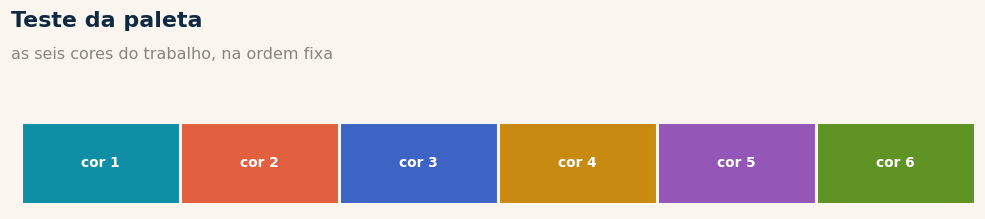

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# A IDENTIDADE VISUAL DO TRABALHO
# Paleta testada para leitura por pessoas com daltonismo e para contraste no fundo creme.
# ══════════════════════════════════════════════════════════════════════════════
CREME  = '#faf6ef'   # fundo
TINTA  = '#141414'   # texto principal
NAVY   = '#0f2942'   # títulos e destaques escuros
CINZA  = '#8a857c'   # texto secundário, grades, anotações

TEAL   = '#0e8fa6'   # cor 1
CORAL  = '#e2603f'   # cor 2
AZUL   = '#3d63c4'   # cor 3
AMBAR  = '#c98a12'   # cor 4
ROXO   = '#9457b8'   # cor 5
VERDE  = '#5f9424'   # cor 6
PALETA = [TEAL, CORAL, AZUL, AMBAR, ROXO, VERDE]

# Cores fixas por categoria: a mesma cor significa a mesma coisa em TODOS os gráficos.
COR_SEXO = {'homem': AZUL, 'mulher': CORAL}
COR_RACA = {'branca': TEAL, 'amarela': ROXO, 'parda': AMBAR, 'preta': CORAL,
            'indigena': VERDE, 'ignorada': CINZA}

mpl.rcParams.update({
    'figure.facecolor': CREME, 'axes.facecolor': CREME, 'savefig.facecolor': CREME,
    'figure.dpi': 110, 'figure.figsize': (11, 4.6),
    'font.size': 11, 'text.color': TINTA,
    'axes.edgecolor': '#d9d2c5', 'axes.labelcolor': TINTA, 'axes.titlecolor': NAVY,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 14, 'axes.labelsize': 10.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': CINZA, 'ytick.color': CINZA, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'grid.color': '#e6dfd2', 'grid.linewidth': 0.9, 'axes.grid': False,
    'legend.frameon': False, 'legend.fontsize': 10,
    'text.parse_math': False,   # 'R$ 1.000' é texto, não fórmula matemática
})

# ── atalhos de formatação ─────────────────────────────────────────────────────
def brl(v, casas=0):
    """1212.0 -> 'R$ 1.212' (padrão brasileiro)"""
    if pd.isna(v): return 's/ dado'
    s = f'{v:,.{casas}f}'.replace(',', '§').replace('.', ',').replace('§', '.')
    return f'R$ {s}'

def num(v, casas=0):
    if pd.isna(v): return 's/ dado'
    return f'{v:,.{casas}f}'.replace(',', '§').replace('.', ',').replace('§', '.')

def pct(v, casas=1):
    return f'{v:.{casas}f}%'.replace('.', ',')

# ── atalhos de gráfico ────────────────────────────────────────────────────────
def titulo_fig(fig, titulo, subtitulo=''):
    """Título e subtítulo acima da figura, com o espaçamento certo em qualquer altura."""
    h = fig.get_figheight()
    fig.suptitle(titulo, fontsize=14.5, fontweight='bold', color=NAVY,
                 x=0.008, ha='left', y=1 + 0.46/h)
    if subtitulo:
        fig.text(0.008, 1 + 0.13/h, subtitulo, fontsize=10.5, color=CINZA, ha='left', va='top')

def painel(titulo='', subtitulo='', linhas=1, colunas=1, figsize=(11, 4.6)):
    """Cria a figura já com título e subtítulo no padrão do trabalho."""
    fig, ax = plt.subplots(linhas, colunas, figsize=figsize)
    titulo_fig(fig, titulo, subtitulo)
    return fig, ax

def grade(ax, eixo='y'):
    """Grade discreta, atrás dos dados."""
    ax.grid(axis=eixo, color='#e6dfd2', linewidth=0.9)
    ax.set_axisbelow(True)

def eixo_reais(ax, eixo='y'):
    f = FuncFormatter(lambda v, p: brl(v))
    (ax.yaxis if eixo == 'y' else ax.xaxis).set_major_formatter(f)

def rotulos_v(ax, valores, fmt=brl, dy=0.012, tam=9.5, peso='bold'):
    """Escreve o valor em cima de cada barra vertical."""
    alt = ax.get_ylim()[1]
    for i, v in enumerate(valores):
        ax.text(i, v + alt*dy, fmt(v), ha='center', fontsize=tam, fontweight=peso, color=TINTA)

def rotulos_h(ax, valores, fmt=brl, dx=0.012, tam=9.5, peso='bold'):
    """Escreve o valor ao lado de cada barra horizontal."""
    larg = ax.get_xlim()[1]
    for i, v in enumerate(valores):
        ax.text(v + larg*dx, i, fmt(v), va='center', fontsize=tam, fontweight=peso, color=TINTA)

def nota(texto, titulo='📖 Como ler'):
    """Caixa de leitura embaixo do gráfico, sempre no mesmo formato."""
    corpo = '<br>'.join(textwrap.wrap(' '.join(texto.split()), 118))
    display(HTML(f"""<div style="background:#f2ece0;border-left:4px solid {NAVY};
      padding:12px 16px;margin:6px 0 18px;border-radius:6px;font-size:14px;
      line-height:1.55;color:#141414;font-family:system-ui,-apple-system,sans-serif">
      <b style="color:{NAVY}">{titulo}</b><br>{corpo}</div>"""))

def titulo_secao(txt, sub=''):
    display(HTML(f"""<div style="border-bottom:2px solid {NAVY};margin:6px 0 14px;padding-bottom:6px">
      <span style="font-size:17px;font-weight:700;color:{NAVY}">{txt}</span>
      <span style="font-size:13px;color:{CINZA};margin-left:10px">{sub}</span></div>"""))

def tabela(df, titulo='', destaque=None, casas=2):
    """Mostra um DataFrame com o visual do trabalho."""
    if titulo: titulo_secao(titulo)
    est = (df.style
             .format(precision=casas, thousands='.', decimal=',')
             .set_table_styles([
                {'selector':'th','props':[('background-color',NAVY),('color',CREME),
                                          ('font-weight','600'),('text-align','left'),
                                          ('padding','7px 11px'),('font-size','12.5px')]},
                {'selector':'td','props':[('padding','6px 11px'),('font-size','13px'),
                                          ('border-bottom','1px solid #e6dfd2')]},
                {'selector':'','props':[('border-collapse','collapse')]}]))
    if destaque:
        est = est.background_gradient(subset=destaque, cmap='BuPu')
    display(est.hide(axis='index') if df.index.name is None and
            isinstance(df.index, pd.RangeIndex) else est)

print('Identidade visual carregada.')
fig, ax = painel('Teste da paleta', 'as seis cores do trabalho, na ordem fixa', figsize=(9, 1.5))
for i, c in enumerate(PALETA):
    ax.barh(0, 1, left=i, color=c, edgecolor=CREME, linewidth=2)
    ax.text(i+0.5, 0, f'cor {i+1}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.set_xlim(0, len(PALETA)); ax.axis('off'); plt.tight_layout(); plt.show()

---
# Parte 1 · Carregar os dados, direto do IBGE

**🔎 O que vamos fazer:** baixar o microdado da PNAD Contínua **direto do FTP público do IBGE**,
sem BigQuery, sem conta Google, sem login nenhum.

Quem faz o trabalho pesado é o pacote **`pnadium`**: ele busca o arquivo do trimestre no FTP,
baixa o dicionário oficial de variáveis, lê o arquivo de largura fixa usando as posições desse
dicionário e devolve um DataFrame. É o mesmo dado que está na Base dos Dados, só que vindo da fonte.

Dois caminhos, e você escolhe um:

- **Caminho A (uma vez):** baixar do IBGE e salvar em `.parquet`. Leva alguns minutos, porque o
  arquivo do trimestre tem cerca de 200 MB.
- **Caminho B (todo dia):** carregar o `.parquet` já salvo. É instantâneo.

**Três decisões que estão dentro da célula e precisam estar no TCC:**

1. **Qual trimestre.** A PNAD Contínua é um painel: o mesmo domicílio é entrevistado em até cinco
   trimestres seguidos. Se juntarmos os quatro trimestres de 2022, a mesma pessoa entra mais de uma
   vez e a base fica com repetição disfarçada. Por isso o padrão aqui é **um trimestre só**, e a
   redação correta passa a ser "no terceiro trimestre de 2022".
2. **A fração da amostra.** Um trimestre traz mais de meio milhão de pessoas. Isso é ótimo para a
   descritiva e pesado demais para treinar dezenas de modelos em um Colab. O padrão é ficar com uma
   fração aleatória, o que cumpre o mesmo papel do `TABLESAMPLE` que usávamos antes. Coloque `1.0`
   se quiser rodar com tudo.
3. **O peso amostral continua valendo.** Como o recorte é aleatório, as estatísticas ponderadas
   continuam representando o Brasil, apenas com menos precisão do que a amostra inteira daria.

> ### ⚠️ As colunas de trabalho são o que salva o modelo
> A lista abaixo traz **22 variáveis**, incluindo jornada, posição na ocupação, setor, grupo
> ocupacional e contribuição para a previdência. Foi a ausência delas que deixou o modelo da versão
> anterior fraco: sem elas, ele não sabe se a pessoa trabalha 4 ou 44 horas por semana.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CAMINHO A: baixar o microdado DIRETO do FTP do IBGE.
# Sem BigQuery, sem conta Google, sem login. Rode UMA vez e guarde o parquet.
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q pnadium

import pnadium, re

ANO        = 2022
TRIMESTRES = [3]     # a PNAD é um painel: um trimestre por vez evita repetir a mesma pessoa
FRACAO     = 0.20    # fração aleatória que vamos guardar. 1.0 = a amostra inteira do trimestre

# As 22 variáveis, com o código do IBGE e o que cada uma significa.
VARIAVEIS = {
    # --- identificação e geografia ---
    'Ano':       'ano',
    'Trimestre': 'trimestre',
    'UF':        'uf_codigo',            # 11 a 53; viram sigla na célula seguinte
    'V1022':     'situacao_domicilio',   # 1 urbana, 2 rural
    'V1023':     'tipo_area',            # 1 capital, 2 resto da RM, 3 resto da RIDE, 4 interior
    # --- quem é a pessoa ---
    'V2007':     'sexo',                 # 1 homem, 2 mulher
    'V2010':     'raca_cor',             # 1 branca, 2 preta, 3 amarela, 4 parda, 5 indígena, 9 ignorado
    'V2009':     'idade',
    'VD2002':    'condicao_domicilio',   # 1 responsável, 2 cônjuge, 3 filho(a)...
    'V2001':     'pessoas_domicilio',
    # --- educação ---
    'VD3004':    'escolaridade',         # 1 sem instrução ... 7 superior completo
    'VD3005':    'anos_estudo',          # 0 a 16 anos
    'V3002':     'frequenta_escola',     # 1 sim, 2 não
    # --- trabalho: é isto que faz o modelo enxergar a vida real ---
    'VD4002':    'ocupacao',             # 1 ocupada, 2 desocupada
    'VD4009':    'posicao_ocupacao',     # com carteira, sem carteira, conta própria, empregadora...
    'VD4010':    'setor_atividade',      # agropecuária, indústria, comércio, serviços...
    'VD4011':    'grupo_ocupacional',    # diretoras, profissionais, técnicas, elementares...
    'VD4012':    'contribui_previdencia',# 1 sim, 2 não (a formalidade, na prática)
    'VD4031':    'horas_semanais',       # jornada habitual em todos os trabalhos
    # --- a renda e o primo proibido ---
    'VD4020':    'renda',                # ALVO: rendimento efetivo de todos os trabalhos
    'VD4019':    'renda_habitual',       # PROIBIDA no modelo: é quase o próprio alvo
    # --- peso amostral ---
    'V1028':     'peso',                 # NÃO é variável do modelo
}

def baixar_trimestre(ano, tri, codigos):
    """Baixa um trimestre do FTP do IBGE. Se alguma variável não existir naquele
    arquivo, ela é descartada com aviso e o download é refeito, em vez de quebrar."""
    pedidas = list(codigos)
    for _ in range(3):
        try:
            return pnadium.baixar_microdados(ano=ano, periodo=tri,
                                             tipo='trimestral', variaveis=pedidas)
        except ValueError as erro:
            citadas = re.findall(r"['\"]([A-Za-z0-9_]+)['\"]", str(erro))
            faltando = [v for v in pedidas if v in citadas]
            if not faltando:
                raise
            print('⚠️  Sem estas variáveis neste arquivo, seguindo sem elas:', faltando)
            pedidas = [v for v in pedidas if v not in faltando]
    raise RuntimeError('Não consegui baixar o trimestre. Confira a conexão e tente de novo.')

print(f'Baixando do FTP do IBGE: {ANO}, trimestre(s) {TRIMESTRES}.')
print('São cerca de 200 MB por trimestre, então leva alguns minutos.\n')
cru = pd.concat([baixar_trimestre(ANO, t, list(VARIAVEIS)) for t in TRIMESTRES],
                ignore_index=True)
print('\nArquivo lido:', cru.shape[0], 'pessoas x', cru.shape[1], 'colunas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 6.4 MB/s eta 0:00:00
Baixando do FTP do IBGE: 2022, trimestre(s) [3].
São cerca de 200 MB por trimestre, então leva alguns minutos.


PNAD Continua - trimestral
Periodo: 3/2022
Arquivo IBGE: PNADC_032022_20250815.zip
Variaveis: Ano, Trimestre, UF, V1022, V1023, V2007, V2010, V2009 ... (+14)
Saida: DataFrame em memoria
Etapa 1/3: baixando microdados e documentacao do FTP do IBGE...
Etapa 1/3 concluida: arquivos baixados.
Etapa 2/3: preparando os dados para uso em Python...
Etapa 2/3 concluida: dados processados.
DataFrame criado em memoria.

Arquivo lido: 487786 pessoas x 28 colunas


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CAMINHO A, parte 2: dar nome às colunas e arrumar os tipos
# O IBGE entrega código numérico. O notebook inteiro espera o código como TEXTO
# e os números como número. Esta célula garante isso.
# ══════════════════════════════════════════════════════════════════════════════
UF_SIGLA = {11:'RO', 12:'AC', 13:'AM', 14:'RR', 15:'PA', 16:'AP', 17:'TO',
            21:'MA', 22:'PI', 23:'CE', 24:'RN', 25:'PB', 26:'PE', 27:'AL', 28:'SE', 29:'BA',
            31:'MG', 32:'ES', 33:'RJ', 35:'SP', 41:'PR', 42:'SC', 43:'RS',
            50:'MS', 51:'MT', 52:'GO', 53:'DF'}

CODIGOS = ['sexo', 'raca_cor', 'situacao_domicilio', 'tipo_area', 'condicao_domicilio',
           'escolaridade', 'frequenta_escola', 'ocupacao', 'posicao_ocupacao',
           'setor_atividade', 'grupo_ocupacional', 'contribui_previdencia']
INTEIROS = ['ano', 'trimestre', 'idade', 'pessoas_domicilio', 'anos_estudo', 'horas_semanais']
REAIS    = ['renda', 'renda_habitual', 'peso']

base = cru.rename(columns=VARIAVEIS)

if 'uf_codigo' in base.columns:
    base['sigla_uf'] = (pd.to_numeric(base['uf_codigo'], errors='coerce')
                          .map(UF_SIGLA).astype(object))

def como_codigo(s):
    """5.0 vira '5'. O resto do notebook espera o código do IBGE como texto."""
    v = pd.to_numeric(s, errors='coerce').astype('Int64')
    return v.astype(str).where(v.notna(), np.nan).astype(object)

for c in CODIGOS:
    if c in base: base[c] = como_codigo(base[c])
for c in INTEIROS:
    if c in base: base[c] = pd.to_numeric(base[c], errors='coerce').astype('Int64')
for c in REAIS:
    if c in base: base[c] = pd.to_numeric(base[c], errors='coerce').astype(float)

ORDEM = ['ano','trimestre','sigla_uf','situacao_domicilio','tipo_area','sexo','raca_cor','idade',
         'condicao_domicilio','pessoas_domicilio','escolaridade','anos_estudo','frequenta_escola',
         'ocupacao','posicao_ocupacao','setor_atividade','grupo_ocupacional',
         'contribui_previdencia','horas_semanais','renda','renda_habitual','peso']
base = base[[c for c in ORDEM if c in base.columns]]

# o recorte de idade, o mesmo de antes: 16 anos ou mais
antes = len(base)
base = base[base['idade'] >= 16]
print(f'Pessoas de 16 anos ou mais: {len(base):,} de {antes:,}'.replace(',', '.'))

# a fração aleatória: guarda uma parte sorteada, para o notebook rodar rápido
if FRACAO < 1:
    base = base.sample(frac=FRACAO, random_state=42).reset_index(drop=True)
    print(f'Fração aleatória de {FRACAO:.0%} guardada: {len(base):,} pessoas'.replace(',', '.'))

base.to_parquet('dados/01_bruto.parquet', index=False)
print('\nCheckpoint 01_bruto salvo em dados/01_bruto.parquet')
print('Dica: no Colab a pasta some quando a sessão encerra. Para guardar de vez, baixe o arquivo')
print('pelo painel de arquivos (ícone de pasta à esquerda) e suba junto do notebook na próxima vez.')
print('\nFormato final:', base.shape[0], 'linhas x', base.shape[1], 'colunas')
display(base.head())

Pessoas de 16 anos ou mais: 385.803 de 487.786
Fração aleatória de 20% guardada: 77.161 pessoas

Checkpoint 01_bruto salvo em dados/01_bruto.parquet
Dica: no Colab a pasta some quando a sessão encerra. Para guardar de vez, baixe o arquivo
pelo painel de arquivos (ícone de pasta à esquerda) e suba junto do notebook na próxima vez.

Formato final: 77161 linhas x 22 colunas


,ano,trimestre,sigla_uf,situacao_domicilio,tipo_area,sexo,raca_cor,idade,condicao_domicilio,pessoas_domicilio,...,frequenta_escola,ocupacao,posicao_ocupacao,setor_atividade,grupo_ocupacional,contribui_previdencia,horas_semanais,renda,renda_habitual,peso
0,2022,3,RJ,1,4,2,4,66,1,3,...,2,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,150.316596
1,2022,3,MG,2,4,2,4,23,3,4,...,2,1,10,4,5,2,4,NaN,NaN,396.997569
2,2022,3,GO,1,4,1,1,42,1,4,...,2,1,1,4,5,1,44,2500.0,2500.0,627.736070
3,2022,3,MG,1,3,2,1,22,10,3,...,1,1,1,4,5,1,44,1212.0,1212.0,152.519093
4,2022,3,SC,1,4,2,1,42,10,3,...,1,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,350.813558


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CAMINHO B: carregar o arquivo já salvo (é este que vocês vão rodar no dia a dia)
# ══════════════════════════════════════════════════════════════════════════════
CAMINHOS = [
    'dados/01_bruto.parquet',   # o arquivo salvo pelo Caminho A
    '01_bruto.parquet',         # ou solto na raiz, se vocês subiram ele pro Colab
]

base = None
for c in CAMINHOS:
    if os.path.exists(c):
        base = pd.read_parquet(c)
        print(f'Base carregada de: {c}')
        break
if base is None:
    raise FileNotFoundError(
        'Nenhum arquivo encontrado. Rode o Caminho A uma vez, ou suba o parquet do '
        'grupo para o Colab e ajuste a lista CAMINHOS.')

print(f'Formato: {base.shape[0]:,} linhas x {base.shape[1]} colunas'.replace(',', '.'))

Base carregada de: dados/01_bruto.parquet
Formato: 77.161 linhas x 22 colunas


---
# Parte 2 · O raio X da base

> **Regra desta parte: olhar sem consertar.** Nada é limpo, traduzido ou apagado aqui.
> A limpeza só pode ser decidida depois que a gente sabe o que tem.

Um raio X de base responde a **cinco perguntas**, nesta ordem:

1. **Qual é o tamanho e o recorte?** Quantas linhas, quantas colunas, de que período.
2. **O que cada coluna é?** Tipo de dado, quantos valores diferentes, como os valores parecem.
3. **O que está faltando?** E, mais importante: **o vazio quer dizer o quê?**
4. **Como cada variável está distribuída, ainda em código cru?** É aqui que a gente descobre categoria rara, valor estranho e concentração.
5. **Tem coisa impossível?** Idade de 300 anos, renda negativa, linha repetida.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1 A FICHA DA BASE
# ══════════════════════════════════════════════════════════════════════════════
titulo_secao('2.1 A ficha da base', 'o cartão de identidade dos dados')

memoria = base.memory_usage(deep=True).sum() / 1024**2
ficha = {
    'Linhas (pessoas entrevistadas)': num(len(base)),
    'Colunas (variáveis)':            num(base.shape[1]),
    'Tamanho na memória':             f'{memoria:.1f} MB',
    'Período':                        f"ano {base['ano'].min()}" if 'ano' in base else 's/ coluna ano',
    'Trimestres presentes':           ', '.join(map(str, sorted(base['trimestre'].dropna().unique()))) if 'trimestre' in base else '-',
    'Unidades da federação':          f"{base['sigla_uf'].nunique()} UFs" if 'sigla_uf' in base else '-',
    'Idade mínima na base':           f"{base['idade'].min()} anos (o recorte da consulta foi 16+)" if 'idade' in base else '-',
    'Linhas duplicadas':              num(base.duplicated().sum()),
}
for k, v in ficha.items():
    print(f'  {k:.<38} {v}')

  Linhas (pessoas entrevistadas)........ 77.161
  Colunas (variáveis)................... 22
  Tamanho na memória.................... 49.4 MB
  Período............................... ano 2022
  Trimestres presentes.................. 3
  Unidades da federação................. 27 UFs
  Idade mínima na base.................. 16 anos (o recorte da consulta foi 16+)
  Linhas duplicadas..................... 5


**📖 Como ler:** cada linha é **uma pessoa entrevistada** de 16 anos ou mais, sorteada em
uma amostra de 5% da PNAD Contínua de 2022. Não é o Brasil inteiro: é uma amostra que
**representa** o Brasil quando usamos o peso amostral (Parte 6).

Sobre as **linhas duplicadas**: em uma pesquisa domiciliar, duas pessoas diferentes podem
ter exatamente as mesmas características em todas as colunas que pedimos. Isso é
**coincidência legítima**, não erro de coleta, e por isso não apagamos duplicatas aqui.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2 QUAIS COLUNAS CHEGARAM (o detector que adapta o notebook inteiro)
# ══════════════════════════════════════════════════════════════════════════════
titulo_secao('2.2 O que veio na base', 'e o que o notebook vai conseguir fazer com isso')

ESPERADAS = {
 'ano':'identificação', 'trimestre':'identificação', 'sigla_uf':'geografia',
 'situacao_domicilio':'geografia', 'tipo_area':'geografia',
 'sexo':'pessoa', 'raca_cor':'pessoa', 'idade':'pessoa',
 'condicao_domicilio':'domicílio', 'pessoas_domicilio':'domicílio',
 'escolaridade':'educação', 'anos_estudo':'educação', 'frequenta_escola':'educação',
 'ocupacao':'trabalho', 'posicao_ocupacao':'trabalho', 'setor_atividade':'trabalho',
 'grupo_ocupacional':'trabalho', 'contribui_previdencia':'trabalho', 'horas_semanais':'trabalho',
 'renda':'alvo', 'renda_habitual':'proibida (vazamento)', 'peso':'peso amostral',
}
TEM      = {c for c in ESPERADAS if c in base.columns}
FALTANDO = [c for c in ESPERADAS if c not in base.columns]
EXTRAS   = [c for c in base.columns if c not in ESPERADAS]

def existe(*cols):
    """Devolve só as colunas que realmente estão na base. Usada o notebook inteiro."""
    return [c for c in cols if c in base.columns]

print(f'Chegaram {len(TEM)} das {len(ESPERADAS)} colunas esperadas.')
if FALTANDO:
    print('\n⚠️  NÃO chegaram:', ', '.join(FALTANDO))
    if any(ESPERADAS[c] == 'trabalho' for c in FALTANDO):
        print('   Entre elas há colunas de TRABALHO. O notebook roda assim mesmo,')
        print('   mas o modelo fica bem mais fraco. Recomendação: rodar a consulta completa.')
else:
    print('✅ Base completa: dá para fazer o modelo com trabalho incluído.')
if EXTRAS: print('Colunas extras (serão ignoradas):', ', '.join(EXTRAS))

TEM_TRABALHO = all(c in base.columns for c in
                   ['horas_semanais', 'posicao_ocupacao', 'setor_atividade',
                    'grupo_ocupacional', 'contribui_previdencia'])
print('\nTEM_TRABALHO =', TEM_TRABALHO, ' (liga ou desliga o modelo B, na Parte 13)')

Chegaram 22 das 22 colunas esperadas.
✅ Base completa: dá para fazer o modelo com trabalho incluído.

TEM_TRABALHO = True  (liga ou desliga o modelo B, na Parte 13)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.3 AS PRIMEIRAS LINHAS, exatamente como o IBGE entrega
# ══════════════════════════════════════════════════════════════════════════════
titulo_secao('2.3 As cinco primeiras linhas', 'ainda em código cru, sem tradução nenhuma')
display(base.head())

,ano,trimestre,sigla_uf,situacao_domicilio,tipo_area,sexo,raca_cor,idade,condicao_domicilio,pessoas_domicilio,...,frequenta_escola,ocupacao,posicao_ocupacao,setor_atividade,grupo_ocupacional,contribui_previdencia,horas_semanais,renda,renda_habitual,peso
0,2022,3,RJ,1,4,2,4,66,1,3,...,2,None,None,None,None,None,<NA>,NaN,NaN,150.316596
1,2022,3,MG,2,4,2,4,23,3,4,...,2,1,10,4,5,2,4,NaN,NaN,396.997569
2,2022,3,GO,1,4,1,1,42,1,4,...,2,1,1,4,5,1,44,2500.0,2500.0,627.736070
3,2022,3,MG,1,3,2,1,22,10,3,...,1,1,1,4,5,1,44,1212.0,1212.0,152.519093
4,2022,3,SC,1,4,2,1,42,10,3,...,1,None,None,None,None,None,<NA>,NaN,NaN,350.813558


**📖 Como ler, e este é o susto inicial de quem abre um microdado do IBGE:** quase tudo é
**código numérico**. `sexo` é `1` ou `2`. `raca_cor` vai de `1` a `9`. `escolaridade` vai de
`1` a `7`. Isso não é defeito: o IBGE guarda os dados assim porque é compacto e sem ambiguidade.
A tradução desses códigos é a Parte 3, e ela vem depois do raio X **de propósito**:
primeiro a gente descobre quais códigos aparecem de verdade, depois traduz só o que existe.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.4 RAIO X COLUNA A COLUNA
# ══════════════════════════════════════════════════════════════════════════════
titulo_secao('2.4 Raio X coluna a coluna', 'tipo, vazios, variedade e exemplos de valores')

linhas_rx = []
for c in base.columns:
    s = base[c]
    exemplos = ', '.join(map(str, pd.Series(s.dropna().unique()).head(5).tolist()))
    linhas_rx.append({
        'coluna': c,
        'grupo': ESPERADAS.get(c, 'extra'),
        'tipo': str(s.dtype),
        'vazios %': round(s.isna().mean()*100, 1),
        'valores diferentes': s.nunique(),
        'exemplos de valores': exemplos[:52] + ('...' if len(exemplos) > 52 else ''),
    })
raio_x = pd.DataFrame(linhas_rx)
tabela(raio_x, casas=1)

coluna,grupo,tipo,vazios %,valores diferentes,exemplos de valores
ano,identificação,Int64,"0,0",1,2022
trimestre,identificação,Int64,"0,0",1,3
sigla_uf,geografia,object,"0,0",27,"RJ, MG, GO, SC, MA"
situacao_domicilio,geografia,object,"0,0",2,"1, 2"
tipo_area,geografia,object,"0,0",4,"4, 3, 2, 1"
sexo,pessoa,object,"0,0",2,"2, 1"
raca_cor,pessoa,object,"0,0",6,"4, 1, 2, 5, 3"
idade,pessoa,Int64,"0,0",90,"66, 23, 42, 22, 60"
condicao_domicilio,domicílio,object,"0,0",17,"1, 3, 10, 12, 2"
pessoas_domicilio,domicílio,Int64,"0,0",17,"3, 4, 7, 2, 5"


**📖 Como ler esta tabela, coluna por coluna:**

- **`tipo`**: `object` quer dizer texto (aqui, o código do IBGE guardado como texto). `Int64` e `float64` são números.
  Repare que `escolaridade` chega como **texto**, mesmo sendo uma escala ordenada. Vamos converter para número na Parte 3, e com um motivo.
- **`vazios %`**: guarde os três patamares que aparecem. Perto de 0% (todo mundo respondeu),
  perto de 40% (só quem trabalha respondeu) e um pouco acima (quem trabalha mas não declarou rendimento).
- **`valores diferentes`**: serve para separar categoria de número. `sexo` tem 2, `sigla_uf` tem 27,
  `idade` tem dezenas. Se uma coluna tivesse **1 só** valor diferente, ela não informa nada e sai da base.
- **`exemplos de valores`**: é o teste de realidade. Se aparecer algo estranho aqui (um `-1`, um `999`),
  é código de "não sei" disfarçado de número, e precisa de tratamento.

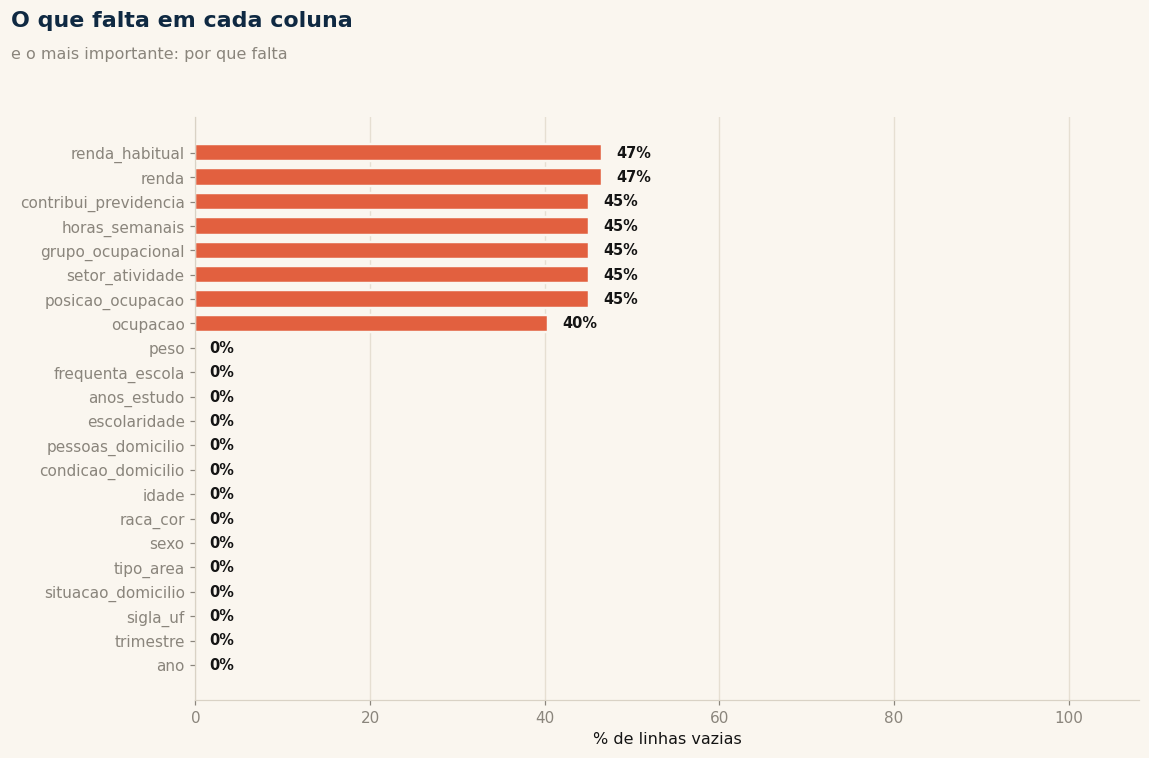

Legenda:  azul = quase nada falta  |  âmbar = falta um pouco  |  coral = falta em boa parte das linhas


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.5 O MAPA DOS VAZIOS
# ══════════════════════════════════════════════════════════════════════════════
vz = (base.isna().mean()*100).sort_values()
cores_vz = [CORAL if v > 30 else (AMBAR if v > 5 else TEAL) for v in vz]

fig, ax = painel('O que falta em cada coluna',
                 'e o mais importante: por que falta', figsize=(10.5, 6.4))
ax.barh(vz.index, vz.values, color=cores_vz, edgecolor=CREME, linewidth=1.6, height=0.72)
ax.set_xlim(0, 108); ax.set_xlabel('% de linhas vazias'); grade(ax, 'x')
for i, v in enumerate(vz.values):
    ax.text(v + 1.6, i, f'{v:.0f}%', va='center', fontsize=9.5, fontweight='bold', color=TINTA)
plt.tight_layout(); plt.show()

print('Legenda:  azul = quase nada falta  |  âmbar = falta um pouco  |  coral = falta em boa parte das linhas')

In [14]:
# O vazio TEM significado: vamos provar isso com uma tabela cruzada.
if 'ocupacao' in base.columns and 'renda' in base.columns:
    titulo_secao('Por que a renda está vazia?', 'cruzando com a situação de ocupação')
    cruz = pd.crosstab(
        base['ocupacao'].map({'1': 'está ocupada (trabalha)', '2': 'desocupada (procura trabalho)'})
                        .fillna('fora da força de trabalho'),
        base['renda'].isna().map({True: 'renda VAZIA', False: 'renda informada'}))
    cruz['% vazia'] = (cruz.get('renda VAZIA', 0) / cruz.sum(axis=1) * 100).round(1)
    display(cruz)

renda,renda VAZIA,renda informada,% vazia
ocupacao,,,
desocupada (procura trabalho),3627,0,100.0
está ocupada (trabalha),1156,41234,2.7
fora da força de trabalho,31144,0,100.0


**📖 Como ler o mapa dos vazios, e esta é a parte que separa um trabalho descuidado de um trabalho honesto:**

Existem **três tipos de vazio** nesta base, e cada um pede uma decisão diferente:

| Onde o vazio aparece | O que ele quer dizer | O que fazemos |
|---|---|---|
| `renda`, `renda_habitual` | A pessoa **não teve rendimento de trabalho**: está desempregada, aposentada, estudando, cuidando da casa | Como a renda é o **alvo**, essas linhas não podem treinar nem testar. Tirar essas linhas **define a população do estudo**, e isso é uma decisão de escopo, não uma limpeza |
| `posicao_ocupacao`, `setor_atividade`, `grupo_ocupacional`, `horas_semanais`, `contribui_previdencia` | A pergunta **só foi feita para quem trabalha**. Para quem não trabalha, ela nem existe | Depois do recorte da população, esses vazios praticamente somem sozinhos |
| Vazio espalhado, em pouca quantidade | Recusa, "não sei", erro de coleta | Preenchimento **dentro do Pipeline**, aprendido só no treino (Parte 10) |

> **A frase para o TCC:** *"o vazio da variável renda não é ausência de informação, é a informação
> de que aquela pessoa não teve rendimento de trabalho no período. Por isso ele define a
> população do estudo em vez de ser tratado como falha."*

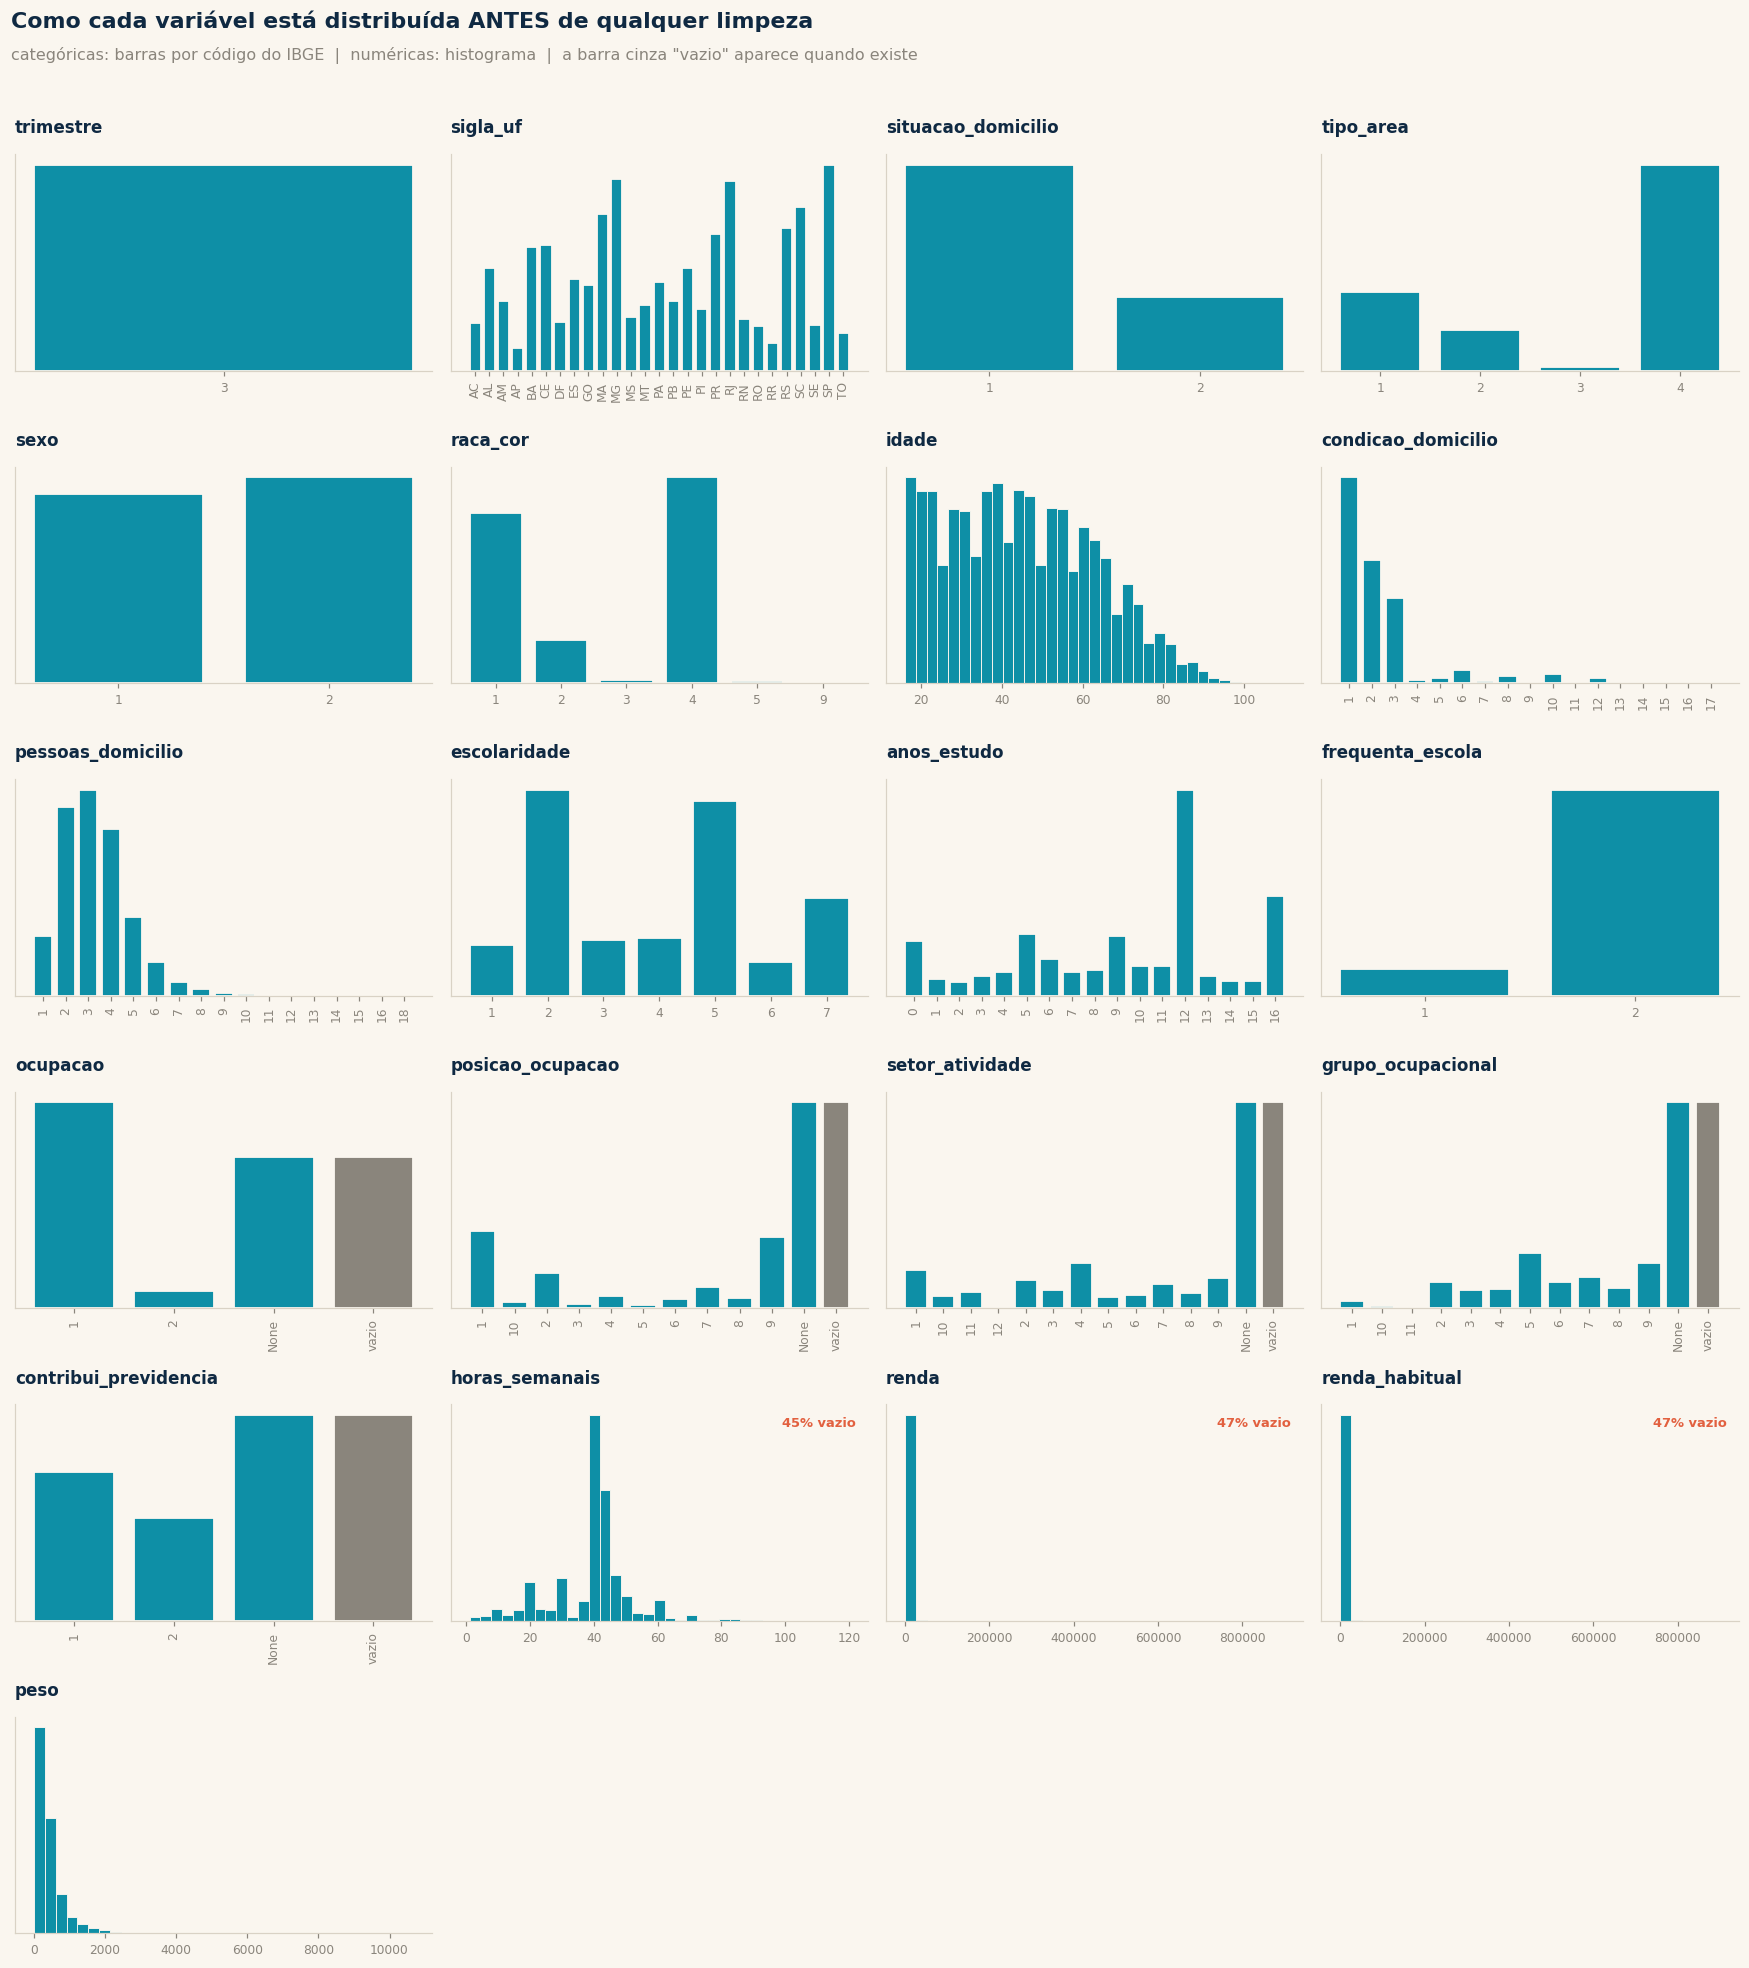

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.6 A DISTRIBUIÇÃO DE TODAS AS VARIÁVEIS, AINDA EM CÓDIGO CRU
#     (esta é a figura que mostra a base "antes de qualquer coisa")
# ══════════════════════════════════════════════════════════════════════════════
cols_plot = [c for c in base.columns if c not in ('ano',)]
n = len(cols_plot); ncol = 4; nlin = int(np.ceil(n/ncol))

fig, axes = plt.subplots(nlin, ncol, figsize=(16, 2.9*nlin))
titulo_fig(fig, 'Como cada variável está distribuída ANTES de qualquer limpeza',
           'categóricas: barras por código do IBGE  |  numéricas: histograma  |  '
           'a barra cinza "vazio" aparece quando existe')
axes = np.atleast_1d(axes).ravel()

def ordenar_codigos(indice):
    """Ordena 1, 2, 10 como números, e não como texto ('10' antes de '2')."""
    try:    return sorted(indice, key=lambda v: float(v))
    except (TypeError, ValueError): return sorted(indice, key=str)

for ax, c in zip(axes, cols_plot):
    s = base[c]
    n_vazio = int(s.isna().sum())
    if s.dtype == object or s.nunique() <= 30:
        vc = s.astype(str).value_counts()
        vc = vc[vc.index != 'nan']
        vc = vc.reindex(ordenar_codigos(vc.index)).head(28)
        if n_vazio: vc = pd.concat([vc, pd.Series({'vazio': n_vazio})])
        cores_b = [CINZA if str(i) == 'vazio' else TEAL for i in vc.index]
        ax.bar(range(len(vc)), vc.values, color=cores_b, edgecolor=CREME, linewidth=1.2)
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels(vc.index, fontsize=7.5,
                           rotation=90 if (len(vc) > 8 or max(len(str(i)) for i in vc.index) > 3) else 0)
    else:
        ax.hist(s.dropna().astype(float), bins=35, color=TEAL, edgecolor=CREME, linewidth=0.6)
        if n_vazio:
            ax.text(0.97, 0.9, f'{n_vazio/len(s)*100:.0f}% vazio', transform=ax.transAxes,
                    ha='right', fontsize=8.5, color=CORAL, fontweight='bold')
    ax.set_title(c, fontsize=11); grade(ax, 'y')
    ax.tick_params(labelsize=8); ax.set_yticks([])

for ax in axes[len(cols_plot):]: ax.axis('off')
plt.tight_layout(); plt.show()

**📖 Como ler esta figura, que é o coração do raio X:**

Ela responde à pergunta *"como os dados chegaram até nós?"* sem nenhum retoque. Cinco coisas
para procurar aqui, e todas viram frase no TCC:

1. **Categoria rara.** Em `raca_cor`, os códigos `3` (amarela) e `5` (indígena) aparecem pouquíssimo.
   Não é erro: é a composição da população brasileira em uma amostra. Consequência prática:
   qualquer conclusão sobre esses dois grupos vai ser **frágil**, e mais adiante vamos mostrar o
   número de casos ao lado de cada estimativa, exatamente por causa disso.
2. **Concentração.** Em `escolaridade`, duas barras dominam (fundamental incompleto e médio completo).
   Isso já antecipa que o modelo vai ter muita gente parecida em uma faixa só.
3. **A barra cinza `vazio`.** Ela mostra, no mesmo gráfico da distribuição, quanto de cada
   variável é ausência. Sem ela, dá para olhar um gráfico bonito e não perceber que metade da coluna não existe.
4. **A cara da renda.** No histograma de `renda`, quase tudo se amontoa à esquerda e uma cauda fina
   se estica para a direita. Isso é a desigualdade de renda aparecendo na forma da distribuição,
   e é o motivo pelo qual vamos usar **mediana** nas comparações e testar o alvo em **log** no modelo.
5. **Escalas diferentes.** `idade` vai até 90 e poucos, `horas_semanais` até 99, `renda` até dezenas de milhares.
   Modelos lineares se incomodam com isso, e é por isso que existe padronização dentro do Pipeline (Parte 10).

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.7 CHECAGENS DE SANIDADE (procurando o impossível)
# ══════════════════════════════════════════════════════════════════════════════
titulo_secao('2.7 Checagens de sanidade', 'procurando valores impossíveis antes de confiar na base')

def checar(nome, condicao_ruim, comentario):
    qtd = int(condicao_ruim.sum()) if condicao_ruim is not None else 0
    sinal = '✅' if qtd == 0 else '⚠️ '
    print(f'{sinal} {nome:.<46} {num(qtd):>8}   {comentario}')

if 'idade' in base:  checar('Idade fora da faixa 16 a 110',
                            ~base['idade'].between(16, 110), 'o recorte da consulta foi 16+')
if 'renda' in base:
    checar('Renda negativa', base['renda'] < 0, 'seria erro de digitação ou de código')
    checar('Renda exatamente zero', base['renda'] == 0,
           'existe: trabalho familiar sem remuneração')
if 'horas_semanais' in base: checar('Jornada acima de 98h/semana',
                                    base['horas_semanais'] > 98, '98 ou 99 costumam ser código de "não sabe"')
if 'peso' in base: checar('Peso amostral zero ou negativo', base['peso'] <= 0, 'invalidaria a ponderação')
checar('Linhas totalmente duplicadas', pd.Series(base.duplicated()),
       'em pesquisa domiciliar, coincidência é possível')

const = [c for c in base.columns if base[c].nunique(dropna=False) <= 1]
print(f'\nColunas constantes (mesmo valor em todas as linhas): {const if const else "nenhuma"}')
print('   Uma coluna constante tem ZERO informação para o modelo, então ela sai na faxina.')

✅ Idade fora da faixa 16 a 110..................        0   o recorte da consulta foi 16+
✅ Renda negativa................................        0   seria erro de digitação ou de código
⚠️  Renda exatamente zero.........................    1.172   existe: trabalho familiar sem remuneração
⚠️  Jornada acima de 98h/semana...................       44   98 ou 99 costumam ser código de "não sabe"
✅ Peso amostral zero ou negativo................        0   invalidaria a ponderação
⚠️  Linhas totalmente duplicadas..................        5   em pesquisa domiciliar, coincidência é possível

Colunas constantes (mesmo valor em todas as linhas): ['ano', 'trimestre']
   Uma coluna constante tem ZERO informação para o modelo, então ela sai na faxina.


**📖 Como ler:** o `⚠️` não quer dizer erro; quer dizer **"decida o que fazer e escreva no TCC"**.

O caso mais interessante aqui é a **renda exatamente zero**. Ela existe de verdade na PNAD:
é a pessoa que trabalha em negócio da família **sem remuneração**, e a pesquisa registra isso
como rendimento zero. Não é digitação errada e não é vazio.

Nós vamos **tirar essas linhas** da base do modelo, por dois motivos que precisam ser ditos:
1. A pergunta do trabalho é sobre **quanto se ganha**, e quem ganha zero está em outra situação social, não em uma renda baixa;
2. Manter zeros quebra a análise em escala logarítmica, que é a escala natural para renda.

E, como toda decisão de recorte, ela entra no funil da Parte 5, contada e justificada.

---
# Parte 3 · O dicionário: de código do IBGE para palavra

**🔎 O que vamos fazer:** transformar `2` em `mulher`, `4` em `parda`, `5` em `médio completo`.

**Por que isso importa mais do que parece:** um gráfico com o rótulo `raca_cor = 4` não é um
resultado, é um enigma. Um gráfico com `parda` é um resultado. Além disso, quando o código vira
palavra, **erro de tradução fica visível**: se aparecesse uma categoria `nan` gigante,
saberíamos na hora que a tabela de-para está errada.

**A tabela de-para completa** está na célula abaixo, e ela é o dicionário oficial da PNAD Contínua.
Ela merece um anexo no TCC.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.1 A TABELA DE-PARA (dicionário da PNAD Contínua)
# ══════════════════════════════════════════════════════════════════════════════
DE_PARA = {
 'sexo': {1:'homem', 2:'mulher'},

 'raca_cor': {1:'branca', 2:'preta', 3:'amarela', 4:'parda', 5:'indigena', 9:'ignorada'},

 'escolaridade': {1:'sem instrução', 2:'fundamental incompleto', 3:'fundamental completo',
                  4:'médio incompleto', 5:'médio completo', 6:'superior incompleto',
                  7:'superior completo'},

 'situacao_domicilio': {1:'urbana', 2:'rural'},

 'tipo_area': {1:'capital', 2:'região metropolitana', 3:'RIDE', 4:'interior'},

 'condicao_domicilio': {1:'responsável', 2:'cônjuge', 3:'cônjuge', 4:'filho(a)', 5:'filho(a)',
                        6:'enteado(a)', 7:'genro/nora', 8:'pai/mãe', 9:'sogro(a)',
                        10:'neto(a)', 11:'bisneto(a)', 12:'irmão/irmã', 13:'avô/avó',
                        14:'outro parente', 15:'agregado(a)', 16:'convivente',
                        17:'pensionista', 18:'empregado(a) doméstico(a)',
                        19:'parente do(a) empregado(a)'},

 'frequenta_escola': {1:'sim', 2:'não'},

 'ocupacao': {1:'ocupada', 2:'desocupada'},

 'posicao_ocupacao': {1:'empregada com carteira (setor privado)',
                      2:'empregada SEM carteira (setor privado)',
                      3:'doméstica com carteira', 4:'doméstica SEM carteira',
                      5:'setor público com carteira', 6:'setor público SEM carteira',
                      7:'militar ou estatutária', 8:'empregadora',
                      9:'conta própria', 10:'trabalho familiar sem remuneração'},

 'setor_atividade': {1:'agropecuária', 2:'indústria', 3:'construção', 4:'comércio',
                     5:'transporte', 6:'alojamento e alimentação',
                     7:'informação, finanças e serviços profissionais',
                     8:'administração pública, educação e saúde', 9:'outros serviços',
                     10:'serviços domésticos', 11:'atividades mal definidas',
                     12:'não informado'},

 'grupo_ocupacional': {1:'diretoras e gerentes', 2:'profissionais das ciências',
                       3:'técnicas de nível médio', 4:'apoio administrativo',
                       5:'serviços e vendas', 6:'agropecuária qualificada',
                       7:'operárias e artesãs', 8:'operadoras de máquinas',
                       9:'ocupações elementares', 10:'forças armadas'},

 'contribui_previdencia': {1:'sim', 2:'não'},
}

# quantos códigos diferentes cada coluna traz, e quantos o dicionário cobre
print(f'{"coluna":<24} {"códigos na base":>16}  {"cobertos pelo dicionário":>26}')
print('-'*70)
for c, mapa in DE_PARA.items():
    if c not in base.columns: continue
    vals = set(pd.to_numeric(base[c], errors='coerce').dropna().astype(int).unique())
    falta = vals - set(mapa)
    print(f'{c:<24} {len(vals):>16}  {len(vals & set(mapa)):>26}'
          + (f'   ⚠️  sem tradução: {sorted(falta)}' if falta else ''))

coluna                    códigos na base    cobertos pelo dicionário
----------------------------------------------------------------------
sexo                                    2                           2
raca_cor                                6                           6
escolaridade                            7                           7
situacao_domicilio                      2                           2
tipo_area                               4                           4
condicao_domicilio                     17                          17
frequenta_escola                        2                           2
ocupacao                                2                           2
posicao_ocupacao                       10                          10
setor_atividade                        12                          12
grupo_ocupacional                      11                          10   ⚠️  sem tradução: [np.int64(11)]
contribui_previdencia                   2             

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.2 APLICAR A TRADUÇÃO
# ══════════════════════════════════════════════════════════════════════════════
dados = base.copy()

def traduzir(serie, mapa):
    v = pd.to_numeric(serie, errors='coerce')
    return v.map({float(k): nome for k, nome in mapa.items()})

for c, mapa in DE_PARA.items():
    if c in dados.columns:
        dados[c] = traduzir(dados[c], mapa)

# escolaridade tem DOIS papéis, e por isso vira duas colunas:
#   escolaridade_nome  -> para os gráficos (a palavra)
#   escolaridade       -> para o modelo (o número 1 a 7, que guarda a ORDEM)
if 'escolaridade' in dados.columns:
    dados['escolaridade_nome'] = dados['escolaridade']
    dados['escolaridade'] = pd.to_numeric(base['escolaridade'], errors='coerce')

# números que chegaram como texto viram números de verdade
for c in existe('idade', 'anos_estudo', 'horas_semanais', 'pessoas_domicilio',
                'renda', 'renda_habitual', 'peso'):
    dados[c] = pd.to_numeric(dados[c], errors='coerce')

print('Tradução aplicada. Confira o antes e o depois:\n')
amostra = existe('sexo', 'raca_cor', 'escolaridade_nome', 'posicao_ocupacao')
comp = pd.concat([base[[c.replace('_nome','') for c in amostra]].head(6).add_prefix('CÓDIGO: '),
                  dados[amostra].head(6).add_prefix('TRADUZIDO: ')], axis=1)
display(comp)

Tradução aplicada. Confira o antes e o depois:



,CÓDIGO: sexo,CÓDIGO: raca_cor,CÓDIGO: posicao_ocupacao,TRADUZIDO: sexo,TRADUZIDO: raca_cor,TRADUZIDO: posicao_ocupacao
0,2,4,None,mulher,parda,NaN
1,2,4,10,mulher,parda,trabalho familiar sem remuneração
2,1,1,1,homem,branca,empregada com carteira (setor privado)
3,2,1,1,mulher,branca,empregada com carteira (setor privado)
4,2,1,None,mulher,branca,NaN
5,1,4,None,homem,parda,NaN


**📖 Como ler:** à esquerda o que o IBGE entrega, à direita o que o trabalho vai mostrar.
Repare em uma decisão importante: **`escolaridade` virou duas colunas**.

- `escolaridade_nome` guarda a palavra (`médio completo`) e serve para os **gráficos**.
- `escolaridade` guarda o número de 1 a 7 e serve para o **modelo**.

**Por que manter a versão numérica?** Porque escolaridade é uma variável **ordinal**: existe uma
ordem real entre as categorias (superior completo é mais do que médio completo, que é mais do que
fundamental). Se transformássemos em colunas soltas de sim/não (o famoso *one-hot*), o modelo
perderia essa ordem e passaria a tratar "sem instrução" e "superior completo" como duas categorias
sem relação. Como número, a ordem fica preservada e o modelo pode aprender "mais escolaridade puxa
a renda para cima" como uma direção.

---
# Parte 4 · As categorias que **nós** criamos

**🔎 O que vamos fazer:** criar as variáveis derivadas do trabalho e, para cada uma,
**mostrar na tela como as pessoas se distribuem nela**.

**Por que criar categoria nova:** as variáveis originais são detalhadas demais para algumas
perguntas. `idade` com 80 valores diferentes não vira gráfico legível; `faixa_etaria` com 6 grupos vira.
`sigla_uf` com 27 estados dispersa a leitura; `regiao` com 5 concentra.

**E a regra de ouro desta parte:** *toda categoria criada tem que aparecer com a sua contagem.*
Uma categoria com 39 pessoas e uma com 8.215 pessoas não podem ser lidas com a mesma confiança,
e quem lê o trabalho precisa saber disso olhando o gráfico, não descobrindo depois.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1 CRIAR AS CATEGORIAS
# ══════════════════════════════════════════════════════════════════════════════
SM_2022 = 1212.0   # salário mínimo vigente em 2022, em reais. Serve de régua social.

# ── região, a partir da UF ────────────────────────────────────────────────────
REGIAO = {
 'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
 'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
 'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
 'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
 'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
 'PR':'Sul','RS':'Sul','SC':'Sul'}
if 'sigla_uf' in dados: dados['regiao'] = dados['sigla_uf'].map(REGIAO)

# ── faixa etária: idade contínua vira grupos que a gente consegue ler ─────────
if 'idade' in dados:
    dados['faixa_etaria'] = pd.cut(
        dados['idade'], bins=[15, 24, 34, 44, 54, 64, 200],
        labels=['16 a 24', '25 a 34', '35 a 44', '45 a 54', '55 a 64', '65 ou mais'])

# ── grupo racial no padrão IBGE: "negra" = preta + parda ─────────────────────
#    Este agrupamento é oficial e é o que permite falar da população negra como grupo.
#    Amarelas e indígenas ficam à parte porque têm pouquíssimos casos na amostra.
if 'raca_cor' in dados:
    dados['grupo_racial'] = dados['raca_cor'].map(
        {'branca':'branca', 'preta':'negra (preta ou parda)', 'parda':'negra (preta ou parda)',
         'amarela':'amarela', 'indigena':'indígena', 'ignorada':'ignorada'})

# ── a interseção: gênero x grupo racial, a variável central do TCC ───────────
if {'sexo', 'grupo_racial'} <= set(dados.columns):
    dados['sexo_raca'] = dados['sexo'].str.capitalize() + ' · ' + dados['grupo_racial']

# ── formalidade: contribuir para a previdência é a marca do trabalho formal ──
if 'contribui_previdencia' in dados:
    dados['formalidade'] = dados['contribui_previdencia'].map(
        {'sim':'formal (contribui)', 'não':'informal (não contribui)'})

# ── faixa de jornada: meio período, integral, jornada longa ─────────────────
if 'horas_semanais' in dados:
    dados['faixa_jornada'] = pd.cut(
        dados['horas_semanais'], bins=[0, 29, 44, 200],
        labels=['até 29h (parcial)', '30h a 44h (integral)', '45h ou mais (jornada longa)'])

# ── renda em salários mínimos: a régua que qualquer pessoa entende ──────────
if 'renda' in dados:
    dados['faixa_renda_sm'] = pd.cut(
        dados['renda'], bins=[-0.01, 0.001, SM_2022, 2*SM_2022, 3*SM_2022, 5*SM_2022, 1e9],
        labels=['zero', 'até 1 SM', '1 a 2 SM', '2 a 3 SM', '3 a 5 SM', 'mais de 5 SM'])

CRIADAS = existe('regiao', 'faixa_etaria', 'grupo_racial', 'sexo_raca',
                 'formalidade', 'faixa_jornada', 'faixa_renda_sm')
print('Categorias criadas:', ', '.join(CRIADAS))

Categorias criadas: 


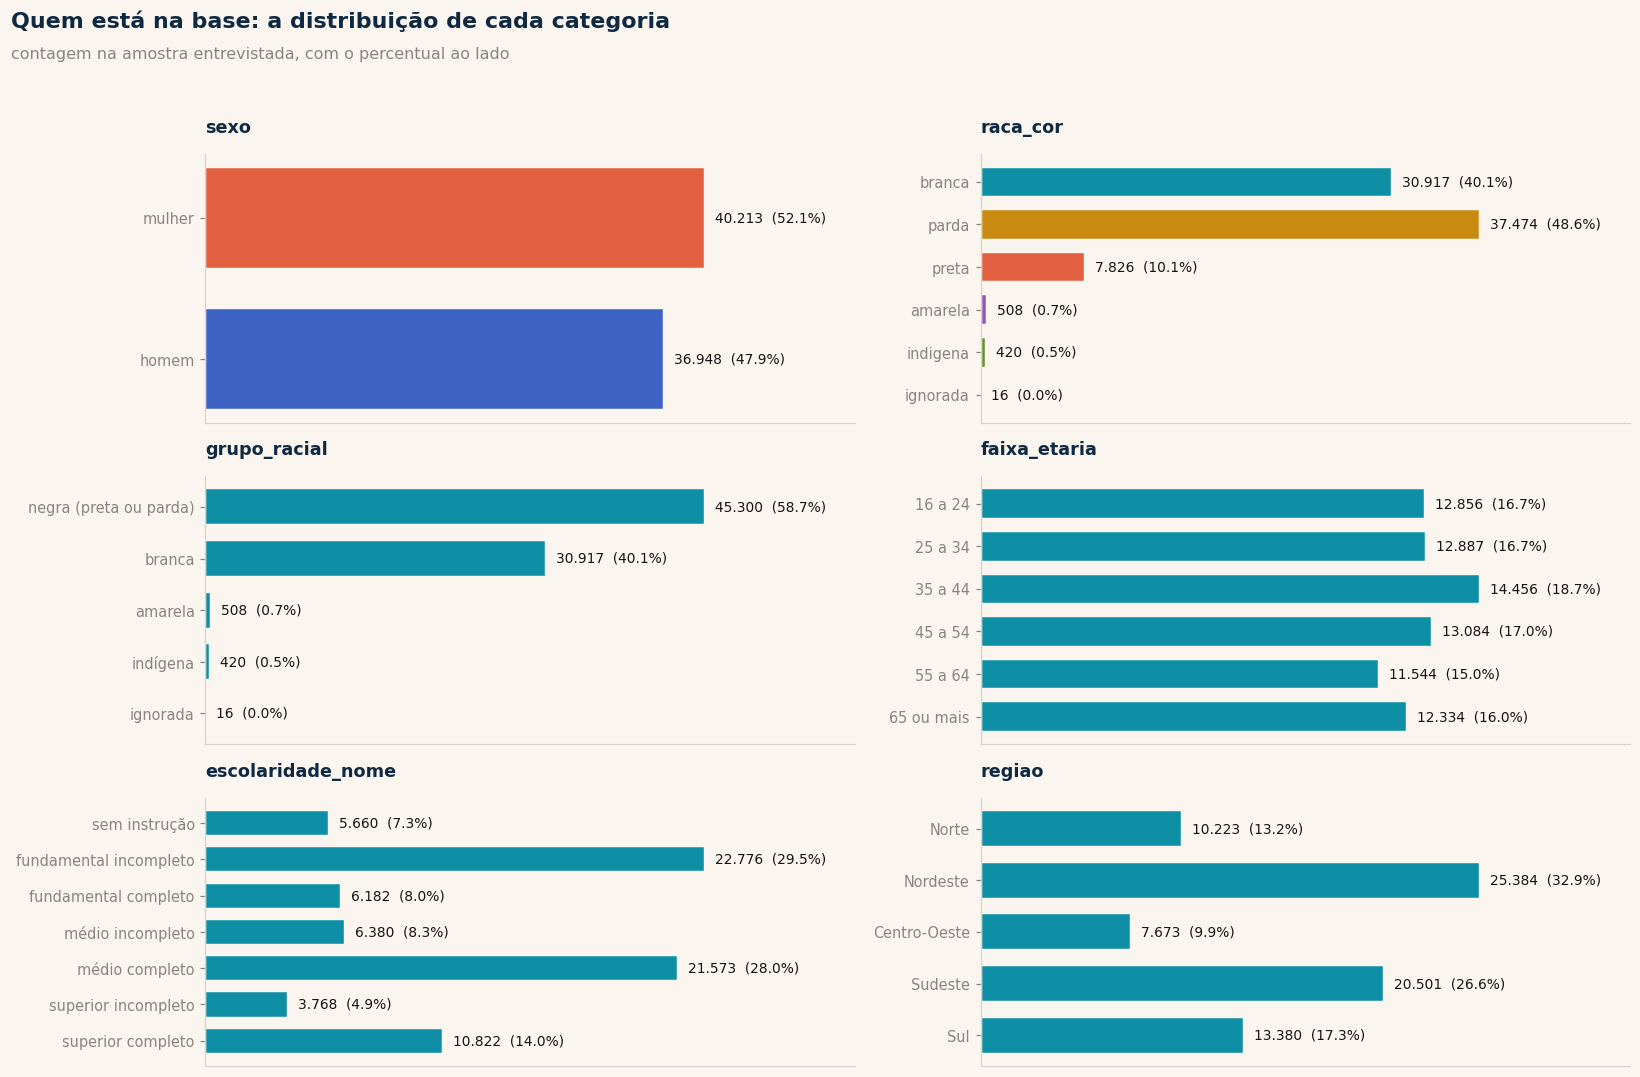

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2 O CATÁLOGO: cada categoria, com contagem e percentual
#     (simples = a amostra entrevistada; ponderado = o Brasil estimado)
# ══════════════════════════════════════════════════════════════════════════════
def catalogo(col, df=None, ordem=None):
    d = dados if df is None else df
    s = d[col].astype('object')
    t = pd.DataFrame({'pessoas na amostra': s.value_counts(dropna=False)})
    t['% da amostra'] = (t['pessoas na amostra'] / len(s) * 100).round(1)
    if 'peso' in d.columns:
        pond = d.groupby(s.fillna('(vazio)'), dropna=False)['peso'].sum()
        t['% do Brasil (ponderado)'] = (pond / pond.sum() * 100).round(1).reindex(
            t.index.map(lambda i: '(vazio)' if pd.isna(i) else i)).values
    t.index = [('(vazio)' if pd.isna(i) else i) for i in t.index]
    if ordem: t = t.reindex([o for o in ordem if o in t.index])
    t.index.name = col
    return t

def grafico_categoria(col, ax, ordem=None, cores=None, titulo=None):
    """Barras horizontais de contagem. Categoria com ordem natural (escolaridade,
    faixa etária) sai na ordem, de cima para baixo. Sem ordem natural, sai do maior
    para o menor. Cor única por padrão: cor diferente só quando ela SIGNIFICA algo."""
    s = dados[col].astype('object')
    vc = s.value_counts(dropna=False)
    vc.index = [('(vazio)' if pd.isna(i) else i) for i in vc.index]
    if ordem: vc = vc.reindex([o for o in ordem if o in vc.index])[::-1]
    else:     vc = vc.sort_values()
    if cores: c = [cores.get(i, CINZA) for i in vc.index]
    else:     c = [CINZA if str(i) == '(vazio)' else TEAL for i in vc.index]
    ax.barh(range(len(vc)), vc.values, color=c, edgecolor=CREME, linewidth=1.6, height=0.72)
    ax.set_yticks(range(len(vc))); ax.set_yticklabels(vc.index, fontsize=9.5)
    ax.set_xlim(0, vc.max()*1.30); grade(ax, 'x')
    for i, v in enumerate(vc.values):
        ax.text(v + vc.max()*0.02, i, f'{num(v)}  ({v/len(s)*100:.1f}%)',
                va='center', fontsize=9, color=TINTA)
    ax.set_title(titulo or col, fontsize=11.5)
    ax.set_xticks([])

grupos_cat = [
    ('sexo',              None, COR_SEXO),
    ('raca_cor',          ['branca','parda','preta','amarela','indigena','ignorada'], COR_RACA),
    ('grupo_racial',      None, None),
    ('faixa_etaria',      ['16 a 24','25 a 34','35 a 44','45 a 54','55 a 64','65 ou mais'], None),
    ('escolaridade_nome', ['sem instrução','fundamental incompleto','fundamental completo',
                           'médio incompleto','médio completo','superior incompleto',
                           'superior completo'], None),
    ('regiao',            ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul'], None),
]
grupos_cat = [g for g in grupos_cat if g[0] in dados.columns]

nlin = int(np.ceil(len(grupos_cat)/2))
fig, axes = plt.subplots(nlin, 2, figsize=(15, 3.1*nlin))
titulo_fig(fig, 'Quem está na base: a distribuição de cada categoria',
           'contagem na amostra entrevistada, com o percentual ao lado')
for ax, (c, ordem, cores) in zip(np.atleast_1d(axes).ravel(), grupos_cat):
    grafico_categoria(c, ax, ordem, cores)
for ax in np.atleast_1d(axes).ravel()[len(grupos_cat):]: ax.axis('off')
plt.tight_layout(); plt.show()

In [21]:
# As mesmas categorias em tabela, agora com a coluna que mais importa:
# quanto cada grupo representa do BRASIL (usando o peso amostral).
for c, ordem, _ in grupos_cat:
    tabela(catalogo(c, ordem=ordem).reset_index(), titulo=f'Categoria: {c}', casas=1)

sexo,pessoas na amostra,% da amostra,% do Brasil (ponderado)
mulher,40.213,"52,1","51,8"
homem,36.948,"47,9","48,2"


raca_cor,pessoas na amostra,% da amostra,% do Brasil (ponderado)
branca,30.917,"40,1","43,5"
parda,37.474,"48,6","44,4"
preta,7.826,"10,1","10,8"
amarela,508,"0,7","0,8"
indigena,420,"0,5","0,5"
ignorada,16,"0,0","0,0"


grupo_racial,pessoas na amostra,% da amostra,% do Brasil (ponderado)
negra (preta ou parda),45.300,"58,7","55,2"
branca,30.917,"40,1","43,5"
amarela,508,"0,7","0,8"
indígena,420,"0,5","0,5"
ignorada,16,"0,0","0,0"


faixa_etaria,pessoas na amostra,% da amostra,% do Brasil (ponderado)
16 a 24,12.856,"16,7","17,5"
25 a 34,12.887,"16,7","19,5"
35 a 44,14.456,"18,7","20,0"
45 a 54,13.084,"17,0","16,4"
55 a 64,11.544,"15,0","13,0"
65 ou mais,12.334,"16,0","13,5"


escolaridade_nome,pessoas na amostra,% da amostra,% do Brasil (ponderado)
sem instrução,5.660,"7,3","5,1"
fundamental incompleto,22.776,"29,5","25,0"
fundamental completo,6.182,"8,0","7,8"
médio incompleto,6.380,"8,3","8,5"
médio completo,21.573,"28,0","31,5"
superior incompleto,3.768,"4,9","5,7"
superior completo,10.822,"14,0","16,3"


regiao,pessoas na amostra,% da amostra,% do Brasil (ponderado)
Norte,10.223,"13,2","8,1"
Nordeste,25.384,"32,9","26,6"
Centro-Oeste,7.673,"9,9","7,8"
Sudeste,20.501,"26,6","42,8"
Sul,13.380,"17,3","14,7"


**📖 Como ler o catálogo, e é aqui que aparece a diferença entre "a amostra" e "o Brasil":**

As duas colunas de percentual quase sempre **não batem**, e isso é o esperado. A coluna
`% da amostra` conta as pessoas entrevistadas. A coluna `% do Brasil (ponderado)` usa o peso
amostral para estimar a população. A PNAD entrevista mais gente em alguns lugares do que a
proporção do país exigiria (para conseguir precisão em estados pequenos), e o peso corrige isso.

**A leitura que vale ouro para o TCC:** olhe o tamanho de cada grupo antes de olhar a renda dele.
Categorias com poucas centenas de pessoas produzem estimativas instáveis: se você repetisse a
pesquisa, o número mudaria bastante. É por isso que, do começo ao fim deste notebook, **toda
comparação por grupo vem com o número de casos ao lado**.

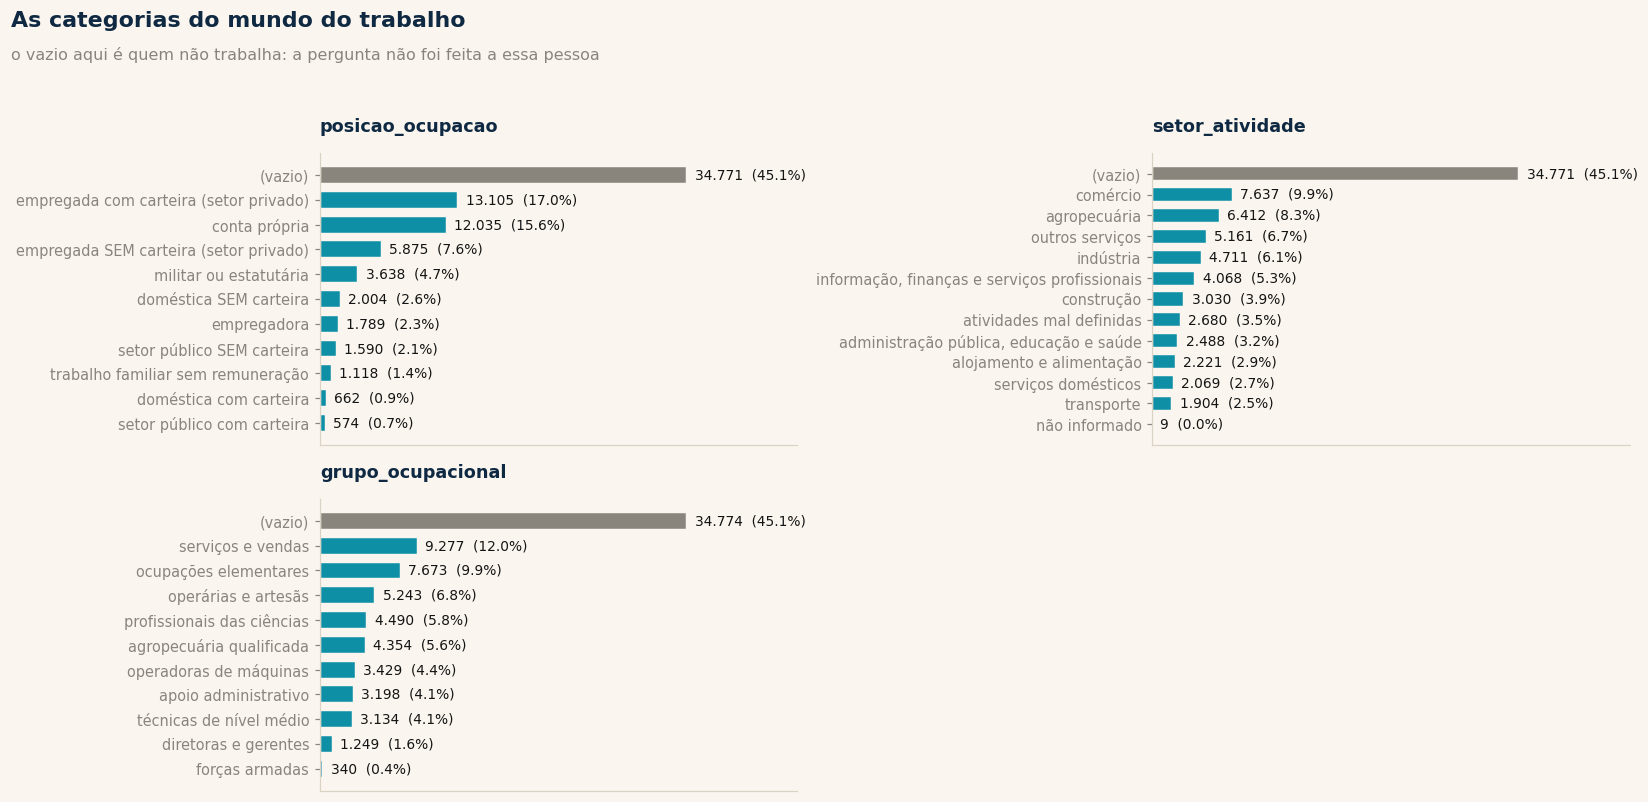

In [22]:
# As categorias que só existem para quem trabalha (formalidade, jornada, ocupação)
cols_trab = existe('formalidade', 'faixa_jornada', 'posicao_ocupacao',
                   'setor_atividade', 'grupo_ocupacional')
if cols_trab:
    nlin = int(np.ceil(len(cols_trab)/2))
    fig, axes = plt.subplots(nlin, 2, figsize=(15, 3.4*nlin))
    titulo_fig(fig, 'As categorias do mundo do trabalho',
               'o vazio aqui é quem não trabalha: a pergunta não foi feita a essa pessoa')
    for ax, c in zip(np.atleast_1d(axes).ravel(), cols_trab):
        grafico_categoria(c, ax)
    for ax in np.atleast_1d(axes).ravel()[len(cols_trab):]: ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('As colunas de trabalho não vieram nesta base. Rode a consulta completa da Parte 1.')

**📖 Como ler:** a barra `(vazio)` grande nestes gráficos é a mesma história do mapa de vazios:
essas perguntas só foram feitas para quem trabalha. Depois do recorte da população (a próxima parte),
elas praticamente desaparecem.

E repare em `posicao_ocupacao`: **conta própria** e **empregada com carteira** costumam ser as
duas maiores barras. Essa única variável carrega uma parte enorme da explicação da renda no Brasil,
porque separa quem tem salário estável de quem tem renda variável. Um modelo que não enxerga
essa coluna está tentando prever renda com os olhos fechados.

---
# Parte 5 · A população do estudo: o funil dos recortes

**🔎 O que vamos fazer:** sair da base bruta e chegar na base do estudo, **contando cada
pessoa que sai e dizendo por quê**.

**Por que um funil e não uma limpeza silenciosa:** cada recorte muda a pergunta que o trabalho
responde. Quem tira aposentados está estudando "renda de quem trabalha", não "renda dos brasileiros".
Isso não é errado, mas precisa estar escrito. O funil é a forma honesta de escrever.

Colunas constantes removidas (zero informação): ['ano', 'trimestre', 'ocupacao']


etapa,pessoas,saíram nesta etapa,% da base bruta,motivo
Base bruta (16 anos ou mais),77.161,"0,0","100,0",como a consulta entregou
Com informação de rendimento,41.234,"35.927,0","53,4",sem alvo não dá para treinar nem avaliar
Com rendimento maior que zero,40.062,"1.172,0","51,9","renda zero é trabalho familiar sem remuneração, outra situação social"


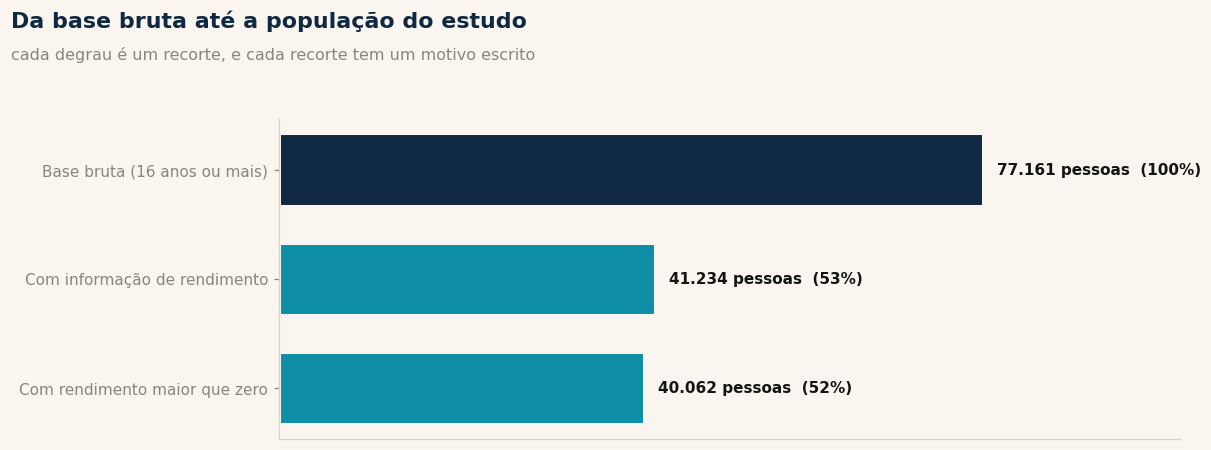


POPULAÇÃO DO ESTUDO: 40.062 pessoas de 16 anos ou mais, com rendimento de trabalho maior que zero, no Brasil, em 2022.
Elas representam 18.668.453 brasileiras e brasileiros.


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1 O FUNIL
# ══════════════════════════════════════════════════════════════════════════════
etapas = []
def registrar(nome, df, motivo):
    etapas.append({'etapa': nome, 'pessoas': len(df), 'motivo': motivo})

estudo = dados.copy()
registrar('Base bruta (16 anos ou mais)', estudo, 'como a consulta entregou')

if 'renda' in estudo:
    estudo = estudo[estudo['renda'].notna()]
    registrar('Com informação de rendimento', estudo,
              'sem alvo não dá para treinar nem avaliar')

    estudo = estudo[estudo['renda'] > 0]
    registrar('Com rendimento maior que zero', estudo,
              'renda zero é trabalho familiar sem remuneração, outra situação social')

if 'ocupacao' in estudo:
    antes = len(estudo)
    estudo = estudo[estudo['ocupacao'].isna() | (estudo['ocupacao'] == 'ocupada')]
    if len(estudo) < antes:
        registrar('Pessoas ocupadas', estudo, 'a renda analisada é a do trabalho')

# colunas sem informação nenhuma saem agora
const = [c for c in estudo.columns if estudo[c].nunique(dropna=False) <= 1]
if const:
    estudo = estudo.drop(columns=const)
    print('Colunas constantes removidas (zero informação):', const)

funil = pd.DataFrame(etapas)
funil['% da base bruta'] = (funil['pessoas'] / funil['pessoas'].iloc[0] * 100).round(1)
funil['saíram nesta etapa'] = funil['pessoas'].shift(1).fillna(funil['pessoas'].iloc[0]) - funil['pessoas']
tabela(funil[['etapa', 'pessoas', 'saíram nesta etapa', '% da base bruta', 'motivo']],
       'O funil da população do estudo', casas=1)

fig, ax = painel('Da base bruta até a população do estudo',
                 'cada degrau é um recorte, e cada recorte tem um motivo escrito', figsize=(11, 3.6))
y = range(len(funil))[::-1]
ax.barh(list(y), funil['pessoas'], color=[NAVY] + [TEAL]*(len(funil)-1),
        edgecolor=CREME, linewidth=2, height=0.66)
ax.set_yticks(list(y)); ax.set_yticklabels(funil['etapa'], fontsize=10)
ax.set_xlim(0, funil['pessoas'].max()*1.28); ax.set_xticks([]); grade(ax, 'x')
for i, (p, pc) in zip(y, zip(funil['pessoas'], funil['% da base bruta'])):
    ax.text(p + funil['pessoas'].max()*0.02, i, f'{num(p)} pessoas  ({pc:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color=TINTA)
plt.tight_layout(); plt.show()

print(f"\nPOPULAÇÃO DO ESTUDO: {num(len(estudo))} pessoas de 16 anos ou mais, "
      f"com rendimento de trabalho maior que zero, no Brasil, em 2022.")
if 'peso' in estudo:
    print(f"Elas representam {num(estudo['peso'].sum())} brasileiras e brasileiros.")

**📖 Como ler o funil, e escrevam esta frase inteira no TCC:**

> *A população deste estudo é composta por pessoas de 16 anos ou mais, residentes no Brasil,
> que declararam rendimento de trabalho maior que zero na PNAD Contínua de 2022. Não estão
> incluídas pessoas desempregadas, aposentadas sem trabalho, estudantes sem rendimento, pessoas
> dedicadas exclusivamente ao trabalho doméstico não remunerado, nem pessoas em trabalho
> familiar sem remuneração.*

**E aqui mora uma limitação séria, que precisa aparecer no trabalho:** ao estudar só quem tem
rendimento, a gente **subestima** a desigualdade de gênero. Mulheres estão em maior proporção
entre as pessoas sem rendimento de trabalho, justamente por causa do trabalho doméstico não
remunerado e do cuidado. Ou seja: a diferença que vamos medir é a que aparece **entre quem
conseguiu entrar no mercado**, e a desigualdade total é maior do que essa.

---
# Parte 6 · O peso amostral: a diferença entre "a amostra" e "o Brasil"

**🔎 O que vamos fazer:** entender, na prática, o que muda quando usamos o peso.

A PNAD **não** entrevista o Brasil inteiro. Ela entrevista uma amostra desenhada com cuidado, e
cada pessoa entrevistada **representa** um certo número de brasileiras e brasileiros. Esse número
é o peso (`V1028`).

Uma pessoa entrevistada em Roraima pode representar 80 pessoas; uma pessoa entrevistada em São Paulo
pode representar 400. Se a gente tira uma média simples, está tratando as duas como iguais e
descrevendo **a amostra**. Se a gente pondera pelo peso, está descrevendo **o país**.

> **O peso não é uma característica da pessoa.** Ele não entra no modelo como variável, jamais.
> Ele entra nas **estatísticas descritivas**. Confundir os dois papéis é um erro clássico.

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.1 FERRAMENTAS DE ESTATÍSTICA PONDERADA
# ══════════════════════════════════════════════════════════════════════════════
TEM_PESO = 'peso' in estudo.columns

def media_pond(valores, pesos):
    v, p = np.asarray(valores, float), np.asarray(pesos, float)
    ok = ~np.isnan(v) & ~np.isnan(p)
    return np.average(v[ok], weights=p[ok])

def quantil_pond(valores, pesos, q=0.5):
    """Mediana (ou qualquer quantil) levando o peso amostral em conta."""
    v, p = np.asarray(valores, float), np.asarray(pesos, float)
    ok = ~np.isnan(v) & ~np.isnan(p)
    v, p = v[ok], p[ok]
    ordem = np.argsort(v); v, p = v[ordem], p[ordem]
    acum = np.cumsum(p) - 0.5*p
    return float(np.interp(q*np.sum(p), acum, v))

def resumo_pond(df, col_grupo, col_valor='renda'):
    """Tabela por grupo: n, mediana e média ponderadas, e o % da população."""
    linhas = []
    for g, sub in df.groupby(col_grupo, observed=True):
        if len(sub) == 0: continue
        w = sub['peso'] if TEM_PESO else pd.Series(1.0, index=sub.index)
        linhas.append({
            col_grupo: g,
            'pessoas na amostra': len(sub),
            'mediana': quantil_pond(sub[col_valor], w),
            'média': media_pond(sub[col_valor], w),
            'p25': quantil_pond(sub[col_valor], w, .25),
            'p75': quantil_pond(sub[col_valor], w, .75),
            '% da população': w.sum() / (df['peso'].sum() if TEM_PESO else len(df)) * 100,
        })
    return pd.DataFrame(linhas)

if TEM_PESO:
    r, w = estudo['renda'], estudo['peso']
    print('A MESMA BASE, DUAS LEITURAS')
    print('='*66)
    print(f'  Média   SIMPLES (descreve as entrevistadas): {brl(r.mean()):>12}')
    print(f'  Média   PONDERADA (estima o Brasil):         {brl(media_pond(r, w)):>12}')
    print(f'  Mediana SIMPLES:                             {brl(r.median()):>12}')
    print(f'  Mediana PONDERADA:                           {brl(quantil_pond(r, w)):>12}')
    print(f'\n  População representada: {num(w.sum())} pessoas com rendimento de trabalho.')
    print(f'  Cada pessoa entrevistada representa, em média, {w.mean():.0f} brasileiras.')
    print('\n  REGRA DO PROJETO: toda estatística descritiva do TCC usa a versão PONDERADA.')
else:
    print('A coluna peso não veio nesta base: as estatísticas descrevem a amostra, não o país.')

A MESMA BASE, DUAS LEITURAS
  Média   SIMPLES (descreve as entrevistadas):     R$ 2.645
  Média   PONDERADA (estima o Brasil):             R$ 2.811
  Mediana SIMPLES:                                 R$ 1.500
  Mediana PONDERADA:                               R$ 1.700

  População representada: 18.668.453 pessoas com rendimento de trabalho.
  Cada pessoa entrevistada representa, em média, 466 brasileiras.

  REGRA DO PROJETO: toda estatística descritiva do TCC usa a versão PONDERADA.


---
# Parte 7 · O alvo por dentro: a distribuição da renda

**🔎 O que vamos fazer:** olhar a renda de quatro ângulos antes de tentar prevê-la.

**Por que quatro ângulos e não um histograma:** a renda é a variável mais assimétrica que existe
em dados sociais. Um histograma sozinho esconde três coisas que decidem o resto do trabalho:
onde está o piso, quão longa é a cauda e quanto da renda total fica com quem está no topo.

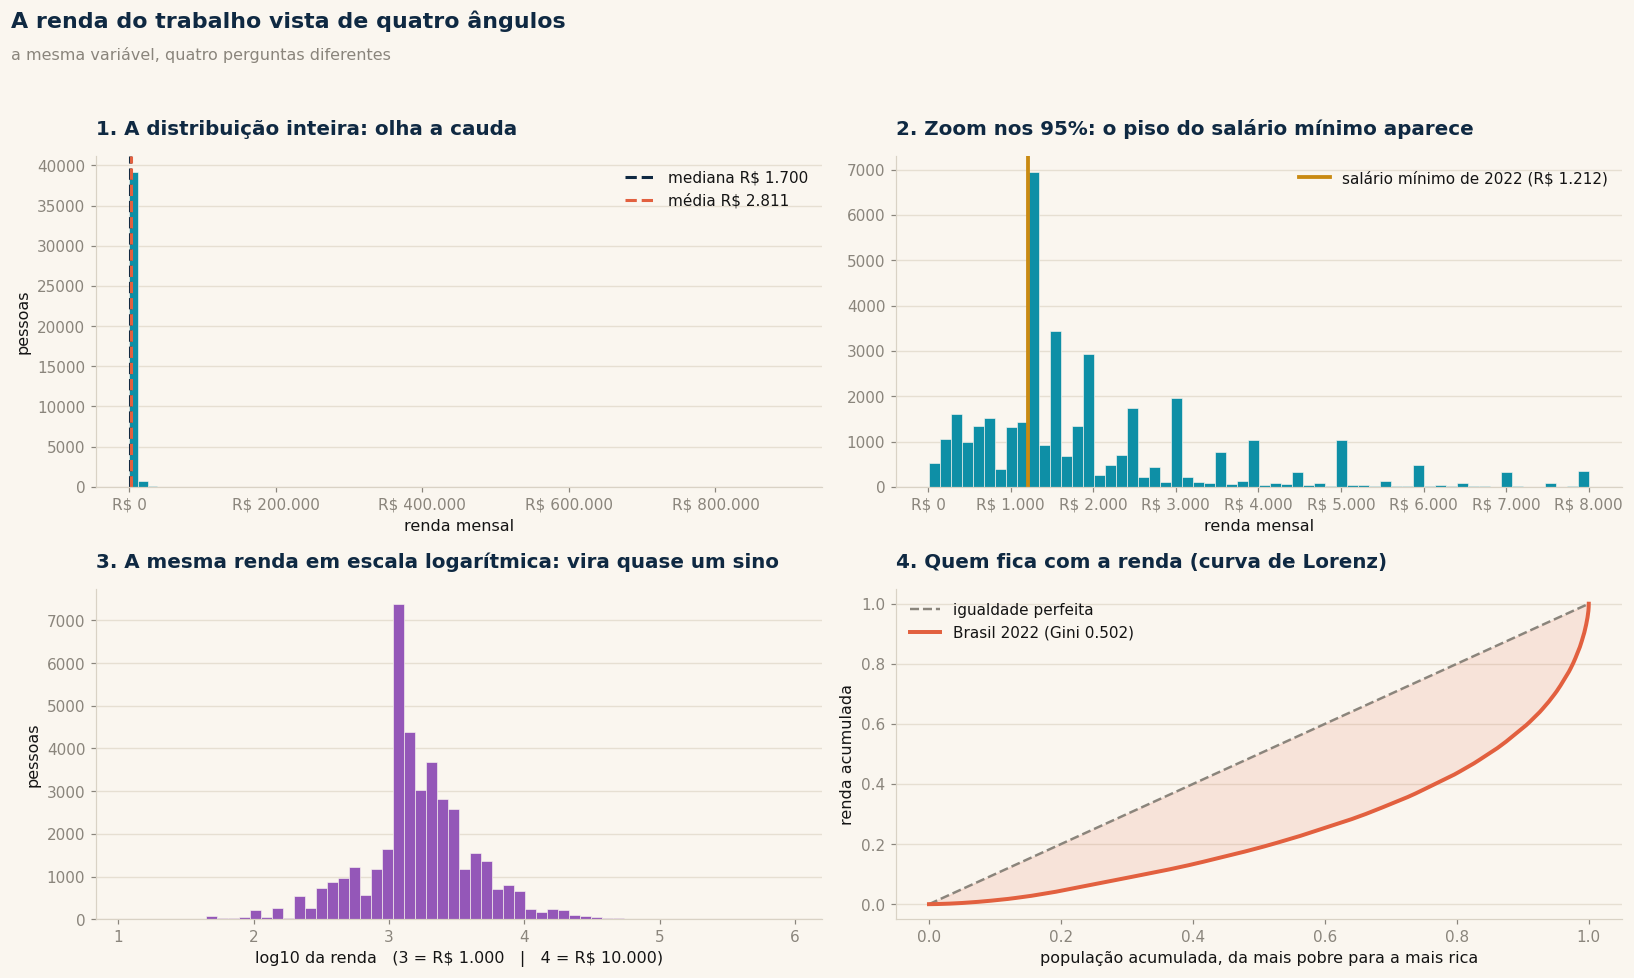

OS NÚMEROS DA DISTRIBUIÇÃO (ponderados)
   10% das pessoas ganham até       R$ 600
   25% das pessoas ganham até     R$ 1.212
   50% das pessoas ganham até     R$ 1.700
   75% das pessoas ganham até     R$ 3.000
   90% das pessoas ganham até     R$ 5.000
   95% das pessoas ganham até     R$ 8.500
   99% das pessoas ganham até    R$ 20.000

  média R$ 2.811  |  mediana R$ 1.700  |  a média é 1.65x a mediana
  quem está no topo 1% ganha 11.8x a mediana
  pessoas exatamente no salário mínimo: 5.640 (14.1% da base)
  Índice de Gini da renda do trabalho: 0.502  (0 = igualdade total, 1 = concentração total)


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.1 QUATRO ÂNGULOS DA MESMA RENDA
# ══════════════════════════════════════════════════════════════════════════════
r = estudo['renda'].dropna()
w = estudo.loc[r.index, 'peso'] if TEM_PESO else pd.Series(1.0, index=r.index)
med, mean = quantil_pond(r, w), media_pond(r, w)

fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
titulo_fig(fig, 'A renda do trabalho vista de quatro ângulos',
           'a mesma variável, quatro perguntas diferentes')

# (1) a distribuição inteira, com a cauda
a = axes[0,0]
a.hist(r, bins=70, color=TEAL, edgecolor=CREME, linewidth=0.4)
a.axvline(med,  color=NAVY,  ls='--', lw=2, label=f'mediana {brl(med)}')
a.axvline(mean, color=CORAL, ls='--', lw=2, label=f'média {brl(mean)}')
a.set_title('1. A distribuição inteira: olha a cauda'); a.set_xlabel('renda mensal')
a.set_ylabel('pessoas'); a.legend(); grade(a); eixo_reais(a, 'x')

# (2) o zoom em quem é maioria
a = axes[0,1]
lim = float(r.quantile(0.95))
a.hist(r[r <= lim], bins=60, color=TEAL, edgecolor=CREME, linewidth=0.4)
a.axvline(SM_2022, color=AMBAR, lw=2.5, label=f'salário mínimo de 2022 ({brl(SM_2022)})')
a.set_title('2. Zoom nos 95%: o piso do salário mínimo aparece')
a.set_xlabel('renda mensal'); a.legend(); grade(a); eixo_reais(a, 'x')

# (3) a mesma renda em escala de log
a = axes[1,0]
a.hist(np.log10(r), bins=60, color=ROXO, edgecolor=CREME, linewidth=0.4)
a.set_title('3. A mesma renda em escala logarítmica: vira quase um sino')
a.set_xlabel('log10 da renda   (3 = R$ 1.000   |   4 = R$ 10.000)')
a.set_ylabel('pessoas'); grade(a)

# (4) quanto da renda total fica com cada décimo da população (curva de concentração)
a = axes[1,1]
ordem = np.argsort(r.values)
rv, wv = r.values[ordem], w.values[ordem]
pop_ac = np.cumsum(wv)/wv.sum()
renda_ac = np.cumsum(rv*wv)/np.sum(rv*wv)
gini = 1 - 2*np.trapezoid(renda_ac, pop_ac)
a.plot([0,1], [0,1], ls='--', color=CINZA, lw=1.6, label='igualdade perfeita')
a.plot(pop_ac, renda_ac, color=CORAL, lw=2.6, label=f'Brasil 2022 (Gini {gini:.3f})')
a.fill_between(pop_ac, renda_ac, pop_ac, color=CORAL, alpha=0.12)
a.set_title('4. Quem fica com a renda (curva de Lorenz)')
a.set_xlabel('população acumulada, da mais pobre para a mais rica')
a.set_ylabel('renda acumulada'); a.legend(loc='upper left'); grade(a)
plt.tight_layout(); plt.show()

# os números que sustentam a leitura
q = {p: quantil_pond(r, w, p) for p in [.10,.25,.50,.75,.90,.95,.99]}
print('OS NÚMEROS DA DISTRIBUIÇÃO (ponderados)')
print('='*62)
for p, v in q.items(): print(f'  {int(p*100):>3}% das pessoas ganham até {brl(v):>12}')
print(f'\n  média {brl(mean)}  |  mediana {brl(med)}  |  '
      f'a média é {mean/med:.2f}x a mediana')
print(f'  quem está no topo 1% ganha {q[.99]/med:.1f}x a mediana')
print(f'  pessoas exatamente no salário mínimo: {num((r == SM_2022).sum())} '
      f'({(r == SM_2022).mean()*100:.1f}% da base)')
print(f'  Índice de Gini da renda do trabalho: {gini:.3f}  (0 = igualdade total, 1 = concentração total)')

**📖 Como ler os quatro ângulos, um por um. Este bloco é o que sustenta metade das decisões do trabalho:**

**1. A cauda longa.** A distribuição não é um sino: ela despenca à esquerda e se estica à direita.
Poucas pessoas com renda muito alta puxam a **média** para cima da **mediana**. Por isso, em renda,
a **mediana é a medida honesta de centro**: ela diz onde está a pessoa do meio, e não é sequestrada
pelos extremos. Todas as comparações de hipótese deste trabalho usam mediana.

**2. O piso do salário mínimo.** Aquela torre no valor do salário mínimo não é erro de dados: é o
mercado de trabalho brasileiro. Uma parcela enorme das pessoas ganha **exatamente** o mínimo, e o
mínimo é o mesmo para todo mundo, por lei. Consequência direta e importantíssima para o TCC:
**quando homens e mulheres se concentram no piso legal, a mediana dos dois pode dar o mesmo valor**,
e a desigualdade não some, ela se desloca para a média, para os quantis mais altos e para a
composição de quem está acima do piso. Vamos ver isso acontecer na Parte 8.

**3. A escala logarítmica.** A mesma renda, tirando o log, vira quase um sino. Isso não é truque
estético: é a informação de que a renda é **multiplicativa**. As pessoas pensam em "ganhar 20% a mais",
não em "ganhar R$ 300 a mais". Guardem essa figura: ela é a justificativa de treinar o modelo no
log da renda, lá na Parte 14.

**4. A curva de Lorenz e o Gini.** A distância entre a curva e a diagonal é a desigualdade.
O índice de Gini resume essa distância em um número de 0 a 1. Este gráfico coloca o trabalho no
contexto certo: **a desigualdade de gênero e raça que vamos medir acontece dentro de um país que
já é muito desigual**, e as duas coisas se somam.

---
# Parte 8 · As hipóteses

**A receita de uma hipótese honesta tem três partes:** *afirmação + mecanismo + teste*.

A **afirmação** é o que a gente espera encontrar. O **mecanismo** é a explicação de *por que* isso
aconteceria no mundo real, e é ele que separa uma hipótese de um chute. O **teste** é definido
**antes** de olhar o resultado, para que a gente não invente a régua depois de ver o número.

| # | Afirmação | Mecanismo (por que aconteceria) | Teste definido antes |
|---|---|---|---|
| **H1** | Mulheres têm renda de trabalho menor que homens | Divisão sexual do trabalho, penalidade da maternidade, segregação ocupacional, discriminação direta | Mediana e média ponderadas por sexo, e comparação da distribuição inteira |
| **H2** | Pessoas pretas e pardas têm renda menor que brancas | Racismo estrutural: acesso desigual à educação de qualidade, a redes de contato e a postos de comando | Mediana ponderada por raça/cor |
| **H3** | Mais escolaridade, mais renda | Credenciais abrem portas de ocupações mais bem pagas e mais protegidas | Mediana por nível de escolaridade e correlação de ordem |
| **H4** | A desigualdade **persiste dentro do mesmo nível de escolaridade** | Se o diploma resolvesse, o gap sumiria no topo da escolaridade. A discriminação não some com o diploma | Renda por sexo **dentro** de cada nível |
| **H5** | Gênero e raça se **somam**: mulheres negras na base da pirâmide | Interseccionalidade: as duas desvantagens operam ao mesmo tempo e não se anulam | Ranking dos grupos gênero × grupo racial |
| **H6** | Parte da diferença vem da **jornada**, mas não toda | Mulheres têm jornada remunerada menor porque acumulam trabalho de cuidado não remunerado | Comparar renda por **hora** trabalhada, além da renda mensal |

> **Hipótese derrubada também é ciência.** Se um teste não confirmar o esperado, o resultado
> continua valendo e vira uma descoberta: quer dizer que o mecanismo imaginado não aparece
> **desse jeito, nesta base**. Vocês vão ver isso acontecer na H1, e é o achado mais interessante do trabalho.

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# 8.0 FERRAMENTAS DAS HIPÓTESES
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats

VEREDITOS = []
def veredito(h, afirmacao, resultado, situacao, detalhe=''):
    VEREDITOS.append({'hipótese': h, 'afirmação': afirmacao,
                      'resultado': resultado, 'situação': situacao, 'observação': detalhe})
    cor = {'CONFIRMADA': VERDE, 'PARCIALMENTE CONFIRMADA': AMBAR, 'NÃO CONFIRMADA': CORAL}[situacao]
    display(HTML(f"""<div style="background:#f2ece0;border-left:5px solid {cor};padding:12px 16px;
      margin:8px 0 20px;border-radius:6px;font-family:system-ui;font-size:14px">
      <b style="color:{cor}">{h}: {situacao}</b><br>{resultado}
      {'<br><i style="color:#8a857c">'+detalhe+'</i>' if detalhe else ''}</div>"""))

def gap_pct(valor_a, valor_b):
    """Quanto b é menor que a, em %. Ex.: gap_pct(renda_homem, renda_mulher)."""
    return (valor_a - valor_b) / valor_a * 100

## H1 · Mulheres têm renda de trabalho menor que homens

sexo,pessoas na amostra,mediana,média,p25,p75,% da população
homem,23.223,1.800,3.116,1.212,3.000,57
mulher,16.839,1.500,2.404,1.200,2.500,43


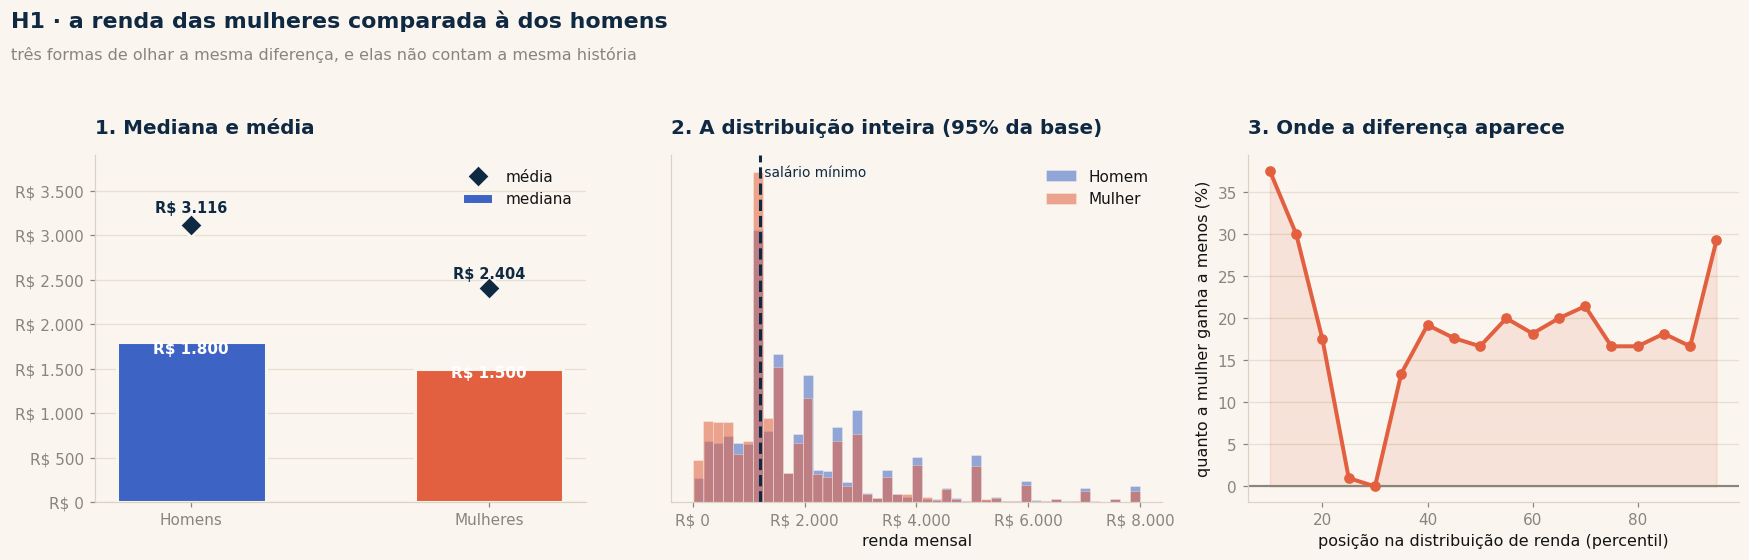

Teste de Mann-Whitney (a renda dos homens é maior?): p = 2.75e-74
  interpretação: p menor que 0,05 significa que a diferença observada dificilmente
  seria fruto do acaso da amostra.

  gap na MEDIANA: 16.7%   (R$ 1.800 contra R$ 1.500)
  gap na MÉDIA:   22.9%   (R$ 3.116 contra R$ 2.404)
  gap no percentil 90: 16.7%


In [27]:
res_sexo = resumo_pond(estudo, 'sexo').set_index('sexo')
tabela(res_sexo.reset_index(), 'H1 · renda do trabalho por sexo (valores ponderados)', casas=0)

h, m = res_sexo.loc['homem'], res_sexo.loc['mulher']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
titulo_fig(fig, 'H1 · a renda das mulheres comparada à dos homens',
           'três formas de olhar a mesma diferença, e elas não contam a mesma história')

# (1) mediana (barra) e média (losango) lado a lado
a = axes[0]
x = np.arange(2)
a.bar(x, [h['mediana'], m['mediana']], 0.5, color=[COR_SEXO['homem'], COR_SEXO['mulher']],
      edgecolor=CREME, linewidth=2, label='mediana')
a.plot(x, [h['média'], m['média']], 'D', color=NAVY, markersize=11,
       markeredgecolor=CREME, markeredgewidth=2, linestyle='none', label='média')
a.set_xticks(x); a.set_xticklabels(['Homens', 'Mulheres'])
for i, v in enumerate([h['mediana'], m['mediana']]):
    a.text(i, v*0.93, brl(v), ha='center', fontsize=10, fontweight='bold', color='white')
for i, v in enumerate([h['média'], m['média']]):
    a.text(i, v*1.045, brl(v), ha='center', fontsize=9.5, color=NAVY, fontweight='bold')
a.set_title('1. Mediana e média'); a.legend(loc='upper right'); grade(a); eixo_reais(a)
a.set_ylim(0, max(h['média'], m['média'])*1.25)

# (2) a distribuição inteira dos dois grupos
a = axes[1]
lim = float(estudo['renda'].quantile(0.95))
for s in ['homem', 'mulher']:
    sub = estudo.loc[estudo['sexo'] == s, 'renda']
    a.hist(sub[sub <= lim], bins=45, alpha=0.55, label=s.capitalize(),
           color=COR_SEXO[s], density=True, edgecolor=CREME, linewidth=0.4)
a.axvline(SM_2022, color=NAVY, lw=2, ls='--')
a.text(SM_2022, a.get_ylim()[1]*0.94, ' salário mínimo', fontsize=9, color=NAVY)
a.set_title('2. A distribuição inteira (95% da base)')
a.set_xlabel('renda mensal'); a.set_yticks([]); a.legend(); grade(a)
a.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5)); eixo_reais(a, 'x')

# (3) o gap ao longo dos quantis: onde a diferença abre
a = axes[2]
qs = np.arange(0.10, 0.96, 0.05)
wh = estudo.loc[estudo['sexo'] == 'homem']
wm = estudo.loc[estudo['sexo'] == 'mulher']
gaps = [gap_pct(quantil_pond(wh['renda'], wh['peso'] if TEM_PESO else pd.Series(1., index=wh.index), q),
                quantil_pond(wm['renda'], wm['peso'] if TEM_PESO else pd.Series(1., index=wm.index), q))
        for q in qs]
a.axhline(0, color=CINZA, lw=1.4)
a.plot(qs*100, gaps, 'o-', color=CORAL, lw=2.6, markersize=6)
a.fill_between(qs*100, 0, gaps, color=CORAL, alpha=0.13)
a.set_title('3. Onde a diferença aparece')
a.set_xlabel('posição na distribuição de renda (percentil)')
a.set_ylabel('quanto a mulher ganha a menos (%)'); grade(a)
plt.tight_layout(); plt.show()

# teste estatístico
u, p_val = stats.mannwhitneyu(estudo.loc[estudo['sexo']=='homem', 'renda'],
                              estudo.loc[estudo['sexo']=='mulher', 'renda'],
                              alternative='greater')
g_med, g_mea = gap_pct(h['mediana'], m['mediana']), gap_pct(h['média'], m['média'])
print(f"Teste de Mann-Whitney (a renda dos homens é maior?): p = {p_val:.2e}")
print(f"  interpretação: p menor que 0,05 significa que a diferença observada dificilmente")
print(f"  seria fruto do acaso da amostra.\n")
print(f"  gap na MEDIANA: {g_med:.1f}%   ({brl(h['mediana'])} contra {brl(m['mediana'])})")
print(f"  gap na MÉDIA:   {g_mea:.1f}%   ({brl(h['média'])} contra {brl(m['média'])})")
print(f"  gap no percentil 90: {gaps[-2]:.1f}%")

situacao = ('CONFIRMADA' if g_med > 1 and p_val < 0.05 else
            'PARCIALMENTE CONFIRMADA' if p_val < 0.05 else 'NÃO CONFIRMADA')
veredito('H1', 'Mulheres têm renda menor que homens',
         f'Na mediana a diferença é de {g_med:.1f}% e na média é de {g_mea:.1f}%. '
         f'O teste estatístico dá p = {p_val:.1e}.',
         situacao,
         'A mediana e a média discordam de propósito: leia o texto abaixo, é o achado mais fino do trabalho.')

**📖 Como ler a H1, e prestem muita atenção porque é aqui que quase todo trabalho de renda escorrega:**

**A mediana e a média não concordam, e isso não é erro.** Os dois números estão certos e medem
coisas diferentes:

- A **mediana** olha a pessoa do meio de cada grupo. Como uma parcela enorme de homens e de mulheres
  ganha **exatamente o salário mínimo** (aquela torre do gráfico 2 da Parte 7), a pessoa do meio dos
  dois grupos pode cair no **mesmo valor legal**. O piso do salário mínimo é o mesmo para todo mundo:
  ele **comprime** a diferença embaixo.
- A **média** olha o total dividido pelas pessoas, então ela sente o que acontece **acima do piso**,
  onde os salários variam livremente. É lá que a desigualdade tem espaço para existir.

**O gráfico 3 é a prova disso.** Ele mostra o gap em cada ponto da distribuição. Na base, perto do
mínimo, a diferença é pequena ou nula. Conforme a renda sobe, a diferença **abre**. Em economia isso
tem nome: *teto de vidro*, a barreira que aparece justamente onde estão os cargos melhores.

**A frase para a banca:** *"a igualdade na mediana não é igualdade: é o efeito do piso legal do
salário mínimo, que atinge homens e mulheres da mesma forma. A desigualdade de gênero neste
conjunto de dados aparece acima do piso, e cresce conforme a renda sobe."*

Isso também explica por que o trabalho **não pode** parar na estatística descritiva: para separar
o efeito do piso do efeito do gênero, é preciso comparar pessoas iguais em tudo o mais, e quem faz
isso é o modelo, na Parte 17.

## H2 · Pessoas pretas e pardas têm renda menor que brancas

raca_cor,pessoas na amostra,mediana,média,p25,p75,% da população
branca,16.613,2.000,3.579,1.212,3.800,45
amarela,278,2.100,4.046,1.300,4.500,1
parda,18.738,1.470,2.184,1.200,2.400,43
preta,4.212,1.500,2.085,1.200,2.300,11
indigena,214,1.500,2.138,1.212,2.500,0


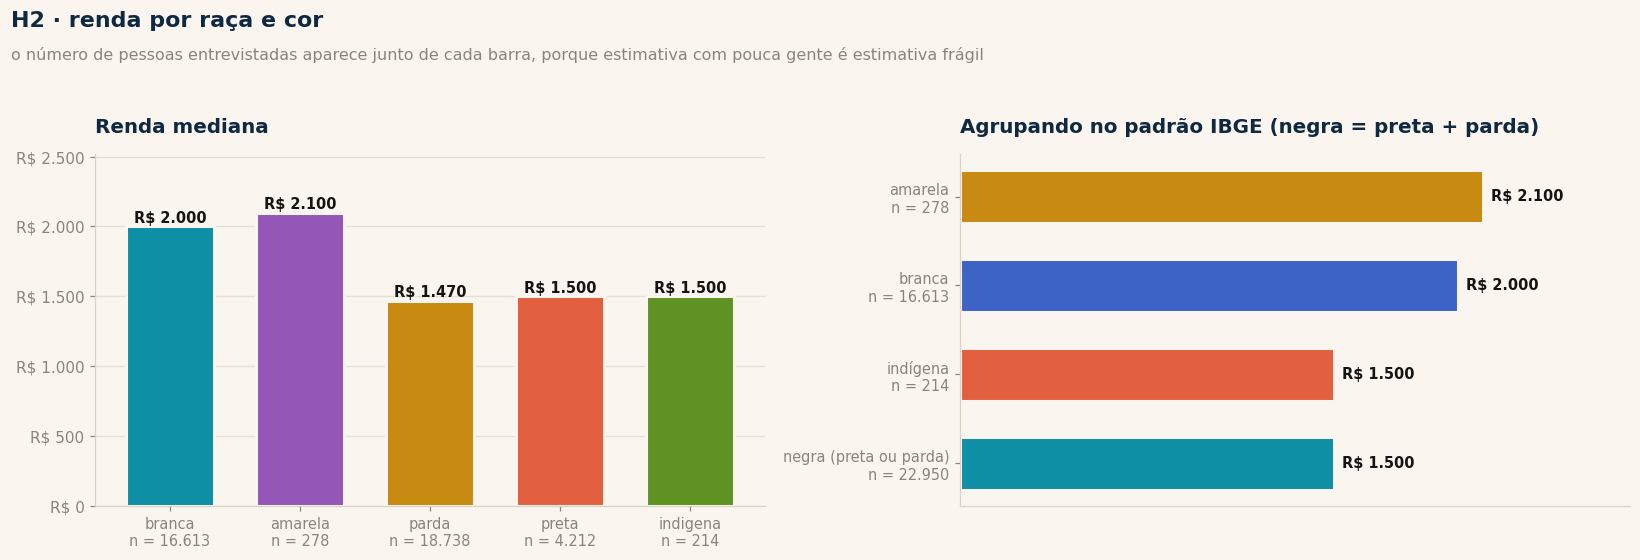

Teste de Kruskal-Wallis (as rendas dos grupos são iguais?): p = 0.00e+00

  mediana: pessoas negras ganham 25.0% menos que pessoas brancas
  média:   pessoas negras ganham 39.6% menos que pessoas brancas


In [28]:
ordem_raca = ['branca', 'amarela', 'parda', 'preta', 'indigena']
res_raca = resumo_pond(estudo, 'raca_cor').set_index('raca_cor')
res_raca = res_raca.reindex([o for o in ordem_raca if o in res_raca.index])
tabela(res_raca.reset_index(), 'H2 · renda do trabalho por raça/cor (valores ponderados)', casas=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
titulo_fig(fig, 'H2 · renda por raça e cor',
           'o número de pessoas entrevistadas aparece junto de cada barra, '
           'porque estimativa com pouca gente é estimativa frágil')

a = axes[0]
cores_r = [COR_RACA.get(i, CINZA) for i in res_raca.index]
a.bar(range(len(res_raca)), res_raca['mediana'], color=cores_r, edgecolor=CREME, linewidth=2, width=0.68)
a.set_xticks(range(len(res_raca)))
a.set_xticklabels([f"{i}\nn = {num(n)}" for i, n in zip(res_raca.index, res_raca['pessoas na amostra'])],
                  fontsize=9.5)
a.set_ylim(0, res_raca['mediana'].max()*1.2)
rotulos_v(a, res_raca['mediana'].values)
a.set_title('Renda mediana'); grade(a); eixo_reais(a)

a = axes[1]
gr = resumo_pond(estudo, 'grupo_racial').set_index('grupo_racial')
gr = gr[gr['pessoas na amostra'] >= 30].sort_values('mediana')
a.barh(range(len(gr)), gr['mediana'], color=[PALETA[i % 6] for i in range(len(gr))],
       edgecolor=CREME, linewidth=2, height=0.6)
a.set_yticks(range(len(gr)))
a.set_yticklabels([f"{i}\nn = {num(n)}" for i, n in zip(gr.index, gr['pessoas na amostra'])], fontsize=9.5)
a.set_xlim(0, gr['mediana'].max()*1.28); rotulos_h(a, gr['mediana'].values)
a.set_title('Agrupando no padrão IBGE (negra = preta + parda)'); grade(a, 'x'); a.set_xticks([])
plt.tight_layout(); plt.show()

grupos_teste = [estudo.loc[estudo['raca_cor'] == g, 'renda'] for g in res_raca.index
                if (estudo['raca_cor'] == g).sum() >= 30]
kw, p_kw = stats.kruskal(*grupos_teste)
print(f'Teste de Kruskal-Wallis (as rendas dos grupos são iguais?): p = {p_kw:.2e}')

if {'branca', 'negra (preta ou parda)'} <= set(gr.index):
    b, n_ = gr.loc['branca', 'mediana'], gr.loc['negra (preta ou parda)', 'mediana']
    bm, nm = gr.loc['branca', 'média'],  gr.loc['negra (preta ou parda)', 'média']
    print(f"\n  mediana: pessoas negras ganham {gap_pct(b, n_):.1f}% menos que pessoas brancas")
    print(f"  média:   pessoas negras ganham {gap_pct(bm, nm):.1f}% menos que pessoas brancas")
    veredito('H2', 'Pessoas pretas e pardas têm renda menor que brancas',
             f'A renda mediana da população negra é {gap_pct(b, n_):.1f}% menor, '
             f'e a média é {gap_pct(bm, nm):.1f}% menor, que a da população branca (p = {p_kw:.1e}).',
             'CONFIRMADA' if gap_pct(b, n_) > 1 and p_kw < 0.05 else 'PARCIALMENTE CONFIRMADA',
             'Amarelas e indígenas têm poucos casos na amostra: a posição delas no gráfico não é confiável.')

**📖 Como ler a H2:** aqui a diferença aparece **também na mediana**, e não só na média. Essa é uma
distinção importante em relação à H1: a desigualdade racial de renda no Brasil é tão grande que
atravessa até o piso do salário mínimo, porque ela não é só sobre *quanto se paga*, é sobre
*em qual posto de trabalho a pessoa consegue entrar*.

**A ressalva metodológica obrigatória:** os grupos `amarela` e `indígena` têm poucas pessoas nesta
amostra de 5%. A posição deles no gráfico pode mudar se a amostra fosse outra, e por isso o número
de casos está impresso embaixo de cada barra. **Conclusão sobre esses dois grupos, neste trabalho,
só com a ressalva junto.**

## H3 · Mais escolaridade, mais renda

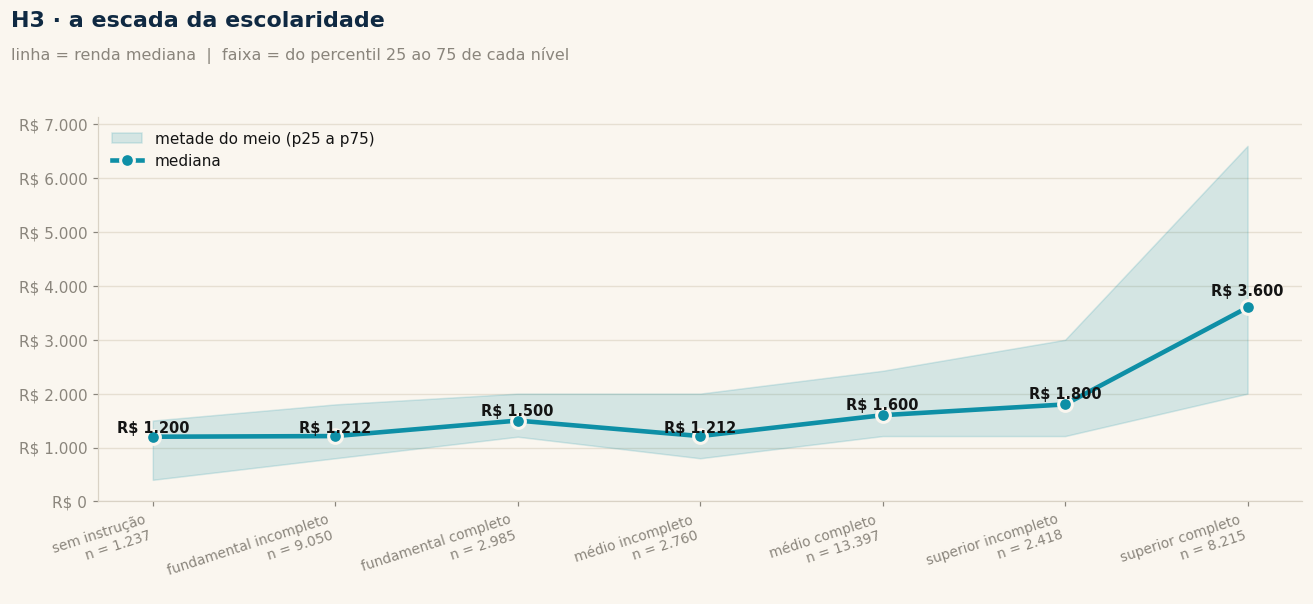

Correlação de ordem (Spearman) entre escolaridade e renda: 0.456  (p = 0.0e+00)
  Spearman mede se a ordem sobe junto, sem exigir que a relação seja uma reta.

  O salto do superior completo sobre o médio completo: +125% na renda mediana.


In [29]:
ordem_esc = ['sem instrução','fundamental incompleto','fundamental completo','médio incompleto',
             'médio completo','superior incompleto','superior completo']
res_esc = resumo_pond(estudo, 'escolaridade_nome').set_index('escolaridade_nome')
res_esc = res_esc.reindex([o for o in ordem_esc if o in res_esc.index])

fig, ax = painel('H3 · a escada da escolaridade',
                 'linha = renda mediana  |  faixa = do percentil 25 ao 75 de cada nível',
                 figsize=(12, 5))
x = np.arange(len(res_esc))
ax.fill_between(x, res_esc['p25'], res_esc['p75'], color=TEAL, alpha=0.16, label='metade do meio (p25 a p75)')
ax.plot(x, res_esc['mediana'], 'o-', color=TEAL, lw=3, markersize=9,
        markeredgecolor=CREME, markeredgewidth=2, label='mediana')
for i, v in enumerate(res_esc['mediana']):
    ax.text(i, v*1.06, brl(v), ha='center', fontsize=9.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}\nn = {num(n)}" for i, n in zip(res_esc.index, res_esc['pessoas na amostra'])],
                   fontsize=9, rotation=18, ha='right')
ax.legend(); grade(ax); eixo_reais(ax)
ax.set_ylim(0, res_esc['p75'].max()*1.08)
plt.tight_layout(); plt.show()

rho, p_rho = stats.spearmanr(estudo['escolaridade'], estudo['renda'])
salto = (res_esc.loc['superior completo','mediana'] / res_esc.loc['médio completo','mediana'] - 1) * 100 \
        if {'superior completo','médio completo'} <= set(res_esc.index) else np.nan
print(f'Correlação de ordem (Spearman) entre escolaridade e renda: {rho:.3f}  (p = {p_rho:.1e})')
print('  Spearman mede se a ordem sobe junto, sem exigir que a relação seja uma reta.')
if not np.isnan(salto):
    print(f'\n  O salto do superior completo sobre o médio completo: +{salto:.0f}% na renda mediana.')
veredito('H3', 'Mais escolaridade, mais renda',
         f'A correlação de ordem é {rho:.3f} (p = {p_rho:.1e}) e a renda mediana sobe a cada degrau.',
         'CONFIRMADA' if rho > 0.1 and p_rho < 0.05 else 'NÃO CONFIRMADA',
         'A escada não é uma reta: o degrau do ensino superior é muito maior que os outros.')

**📖 Como ler a H3, e tem uma sutileza que vale nota na banca:** a escada **não sobe em linha reta**.
Os primeiros degraus são baixos e o degrau do ensino superior é alto. Isso tem duas consequências:

1. **Para a interpretação social:** o "prêmio do diploma" no Brasil está concentrado no ensino
   superior. Terminar o ensino médio ajuda, mas não transforma a renda como o diploma superior transforma.
2. **Para a escolha do modelo:** uma regressão linear é obrigada a desenhar uma **reta** e vai
   errar essa curvatura, achatando o salto do superior. Modelos baseados em árvores conseguem
   representar o degrau. Guardem isso: é uma justificativa técnica que nasce da EDA, e não do gosto
   por um algoritmo. Na Parte 13 esse argumento reaparece.

A **faixa sombreada** também informa: além de subir, a renda fica **mais espalhada** nos níveis altos.
Entre quem tem superior completo, existe muito mais distância entre ganhar pouco e ganhar muito do
que entre quem tem fundamental incompleto.

## H4 · A desigualdade persiste dentro do mesmo nível de escolaridade

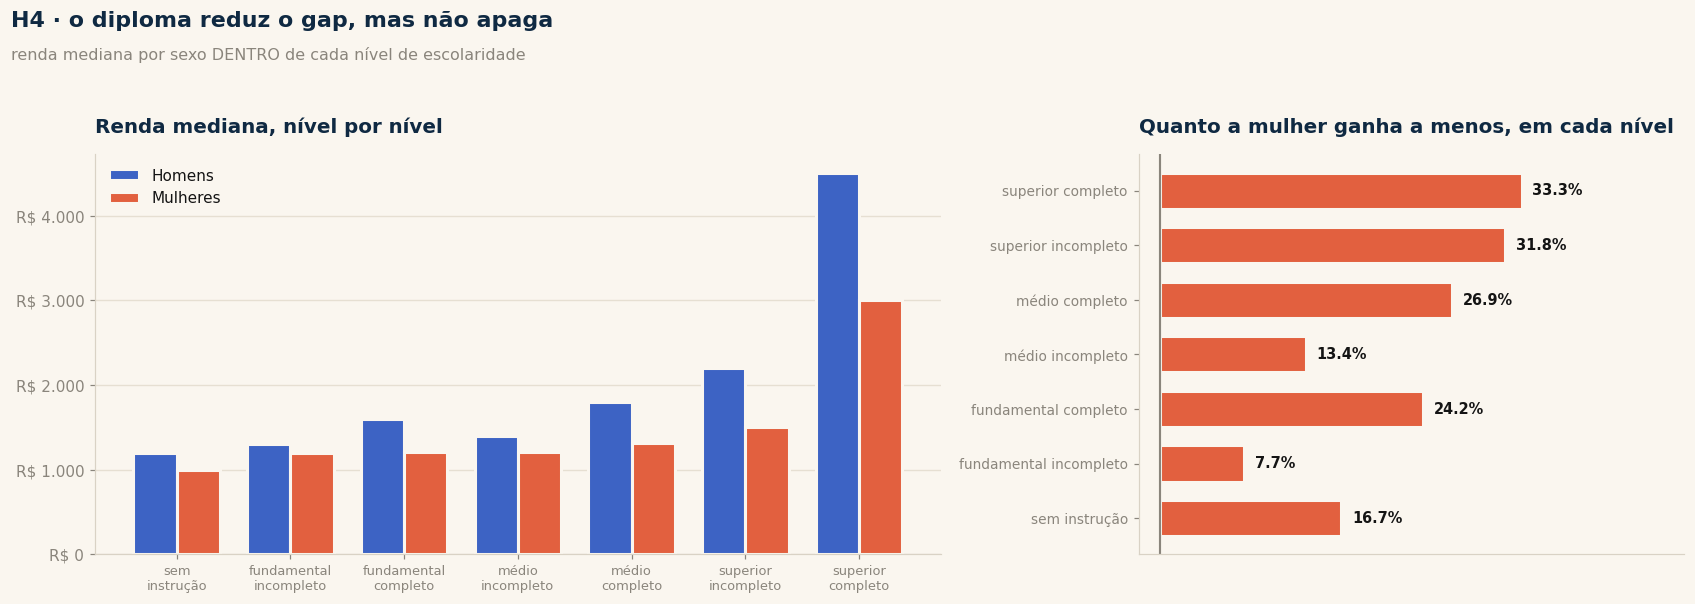

escolaridade,homem,n_homem,mulher,n_mulher,gap %
sem instrução,"1.200,0",912,"1.000,0",325,"16,7"
fundamental incompleto,"1.300,0",6.424,"1.200,0",2.626,"7,7"
fundamental completo,"1.600,0",1.927,"1.212,0",1.058,"24,2"
médio incompleto,"1.400,0",1.779,"1.212,0",981,"13,4"
médio completo,"1.800,0",7.465,"1.315,0",5.932,"26,9"
superior incompleto,"2.200,0",1.184,"1.500,0",1.234,"31,8"
superior completo,"4.500,0",3.532,"3.000,0",4.683,"33,3"


Em 7 dos 7 níveis de escolaridade, a mediana das mulheres é menor.
No topo da escolaridade (superior completo), o gap é de 33.3%.


In [30]:
piv = []
for esc in [o for o in ordem_esc if o in estudo['escolaridade_nome'].unique()]:
    linha = {'escolaridade': esc}
    for s in ['homem', 'mulher']:
        sub = estudo[(estudo['escolaridade_nome'] == esc) & (estudo['sexo'] == s)]
        wsub = sub['peso'] if TEM_PESO else pd.Series(1., index=sub.index)
        linha[s] = quantil_pond(sub['renda'], wsub) if len(sub) >= 30 else np.nan
        linha[f'n_{s}'] = len(sub)
    piv.append(linha)
piv = pd.DataFrame(piv).set_index('escolaridade')
piv['gap %'] = ((piv['homem'] - piv['mulher']) / piv['homem'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5), gridspec_kw={'width_ratios': [1.55, 1]})
titulo_fig(fig, 'H4 · o diploma reduz o gap, mas não apaga',
           'renda mediana por sexo DENTRO de cada nível de escolaridade')

a = axes[0]
x = np.arange(len(piv)); larg = 0.38
a.bar(x - larg/2, piv['homem'], larg, label='Homens', color=COR_SEXO['homem'], edgecolor=CREME, linewidth=2)
a.bar(x + larg/2, piv['mulher'], larg, label='Mulheres', color=COR_SEXO['mulher'], edgecolor=CREME, linewidth=2)
a.set_xticks(x); a.set_xticklabels([i.replace(' ', '\n', 1) for i in piv.index], fontsize=8.5)
a.legend(); grade(a); eixo_reais(a); a.set_title('Renda mediana, nível por nível')

a = axes[1]
cores_g = [CORAL if g > 0 else TEAL for g in piv['gap %'].fillna(0)]
a.barh(range(len(piv)), piv['gap %'], color=cores_g, edgecolor=CREME, linewidth=2, height=0.66)
a.axvline(0, color=CINZA, lw=1.4)
a.set_yticks(range(len(piv))); a.set_yticklabels(piv.index, fontsize=9)
for i, v in enumerate(piv['gap %'].fillna(0)):
    a.text(v + (1 if v >= 0 else -1), i, f'{v:.1f}%', va='center',
           ha='left' if v >= 0 else 'right', fontsize=9.5, fontweight='bold')
a.set_xlim(min(piv['gap %'].min()*1.5, -2), max(piv['gap %'].max()*1.45, 5))
a.set_title('Quanto a mulher ganha a menos, em cada nível'); grade(a, 'x'); a.set_xticks([])
plt.tight_layout(); plt.show()

tabela(piv.reset_index(), 'H4 · os números por trás do gráfico', casas=1)

niveis_com_gap = int((piv['gap %'] > 0).sum()); total_niveis = int(piv['gap %'].notna().sum())
topo = piv.loc['superior completo', 'gap %'] if 'superior completo' in piv.index else np.nan
print(f'Em {niveis_com_gap} dos {total_niveis} níveis de escolaridade, a mediana das mulheres é menor.')
if not np.isnan(topo):
    print(f'No topo da escolaridade (superior completo), o gap é de {topo:.1f}%.')
veredito('H4', 'A desigualdade persiste dentro do mesmo nível de escolaridade',
         f'A mediana feminina é menor em {niveis_com_gap} de {total_niveis} níveis, '
         f'e no ensino superior completo o gap é de {topo:.1f}%.',
         'CONFIRMADA' if niveis_com_gap >= total_niveis - 1 else 'PARCIALMENTE CONFIRMADA',
         'Nos níveis mais baixos o gap é comprimido pelo piso do salário mínimo, como na H1.')

**📖 Como ler a H4, que é a joia do projeto:** se a diferença de renda viesse **só** da escolaridade,
as barras azul e coral teriam a mesma altura dentro de cada nível, e o gráfico da direita seria todo zero.

Não é o que acontece. E repare no **formato** do gráfico da direita: o gap costuma ser pequeno nos
níveis baixos (onde o salário mínimo comprime tudo) e **maior no topo**, exatamente onde estão os
salários mais altos e mais liberdade de negociação. Ou seja: **quanto mais o diploma abre portas,
mais a diferença de gênero aparece**.

**A frase para o TCC:** *"a educação melhora a vida das mulheres, mas não as coloca no mesmo
patamar dos homens com a mesma educação. Escolaridade não é o que explica a diferença: dentro do
mesmo nível, a diferença continua lá."*

## H5 · Gênero e raça se somam (interseccionalidade)

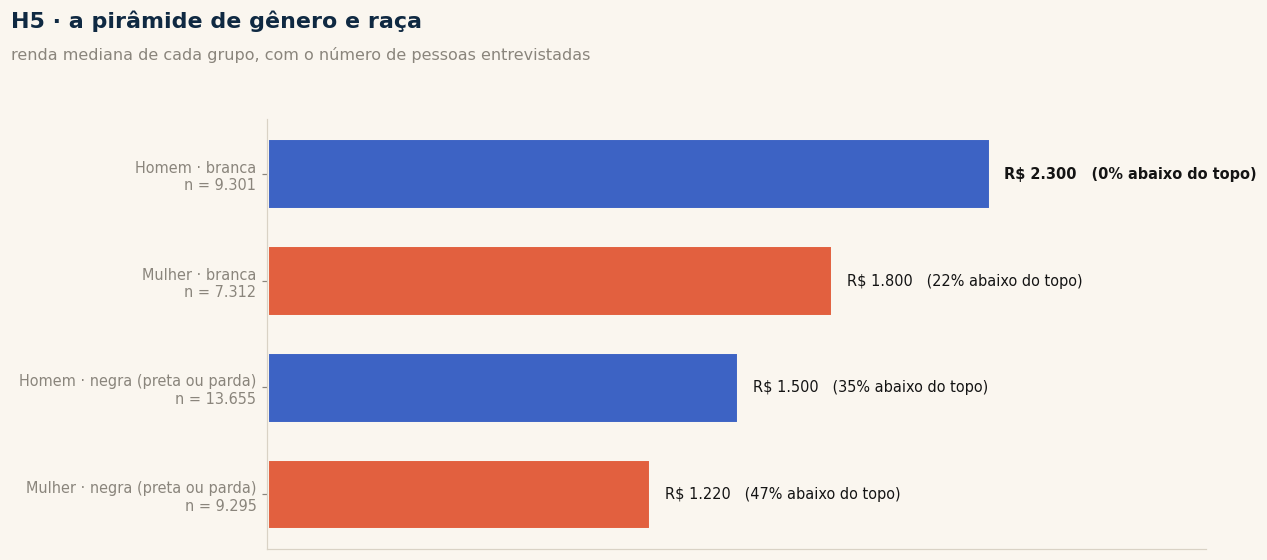

No topo:  Homem · branca                   R$ 2.300
Na base:  Mulher · negra (preta ou parda)  R$ 1.220

Distância entre o topo e a base: 47.0% (R$ 1.080 por mês, R$ 12.960 por ano)


In [31]:
inter = resumo_pond(estudo[estudo['grupo_racial'].isin(['branca', 'negra (preta ou parda)'])], 'sexo_raca')
inter = inter[inter['pessoas na amostra'] >= 30].sort_values('mediana')

fig, ax = painel('H5 · a pirâmide de gênero e raça',
                 'renda mediana de cada grupo, com o número de pessoas entrevistadas',
                 figsize=(11.5, 4.6))
cores_i = [COR_SEXO['mulher'] if p.lower().startswith('mulher') else COR_SEXO['homem']
           for p in inter['sexo_raca']]
ax.barh(range(len(inter)), inter['mediana'], color=cores_i, edgecolor=CREME, linewidth=2, height=0.66)
ax.set_yticks(range(len(inter)))
ax.set_yticklabels([f"{p}\nn = {num(n)}" for p, n in zip(inter['sexo_raca'], inter['pessoas na amostra'])],
                   fontsize=9.5)
ax.set_xlim(0, inter['mediana'].max()*1.30); ax.set_xticks([]); grade(ax, 'x')
topo_v = inter['mediana'].max()
for i, v in enumerate(inter['mediana']):
    ax.text(v + topo_v*0.02, i, f'{brl(v)}   ({gap_pct(topo_v, v):.0f}% abaixo do topo)',
            va='center', fontsize=9.5, fontweight='bold' if i == len(inter)-1 else 'normal')
plt.tight_layout(); plt.show()

base_p, topo_p = inter.iloc[0], inter.iloc[-1]
print(f"No topo:  {topo_p['sexo_raca']:<32} {brl(topo_p['mediana'])}")
print(f"Na base:  {base_p['sexo_raca']:<32} {brl(base_p['mediana'])}")
print(f"\nDistância entre o topo e a base: {gap_pct(topo_p['mediana'], base_p['mediana']):.1f}% "
      f"({brl(topo_p['mediana'] - base_p['mediana'])} por mês, "
      f"{brl((topo_p['mediana'] - base_p['mediana'])*12)} por ano)")
veredito('H5', 'Gênero e raça se somam',
         f"O grupo no topo ({topo_p['sexo_raca']}) tem renda mediana "
         f"{gap_pct(topo_p['mediana'], base_p['mediana']):.1f}% maior que o grupo na base "
         f"({base_p['sexo_raca']}).",
         'CONFIRMADA' if gap_pct(topo_p['mediana'], base_p['mediana']) > 5 else 'PARCIALMENTE CONFIRMADA',
         'A ordem dos grupos do meio pode variar; o topo e a base são o achado robusto.')

**📖 Como ler a H5:** este gráfico é o argumento da **interseccionalidade** em uma imagem. Não existe
"a desigualdade de gênero" de um lado e "a desigualdade racial" do outro, cada uma no seu quadrado.
Elas se acumulam na mesma pessoa, e a distância entre o topo e a base da pirâmide é maior do que
qualquer uma das duas sozinha.

**A ressalva honesta:** as diferenças entre os grupos **do meio** podem ser pequenas e instáveis.
O que este gráfico sustenta com segurança é a distância entre o **topo** e a **base**, não a ordem
exata de cada degrau.

## H6 · Parte da diferença vem da jornada, mas não toda

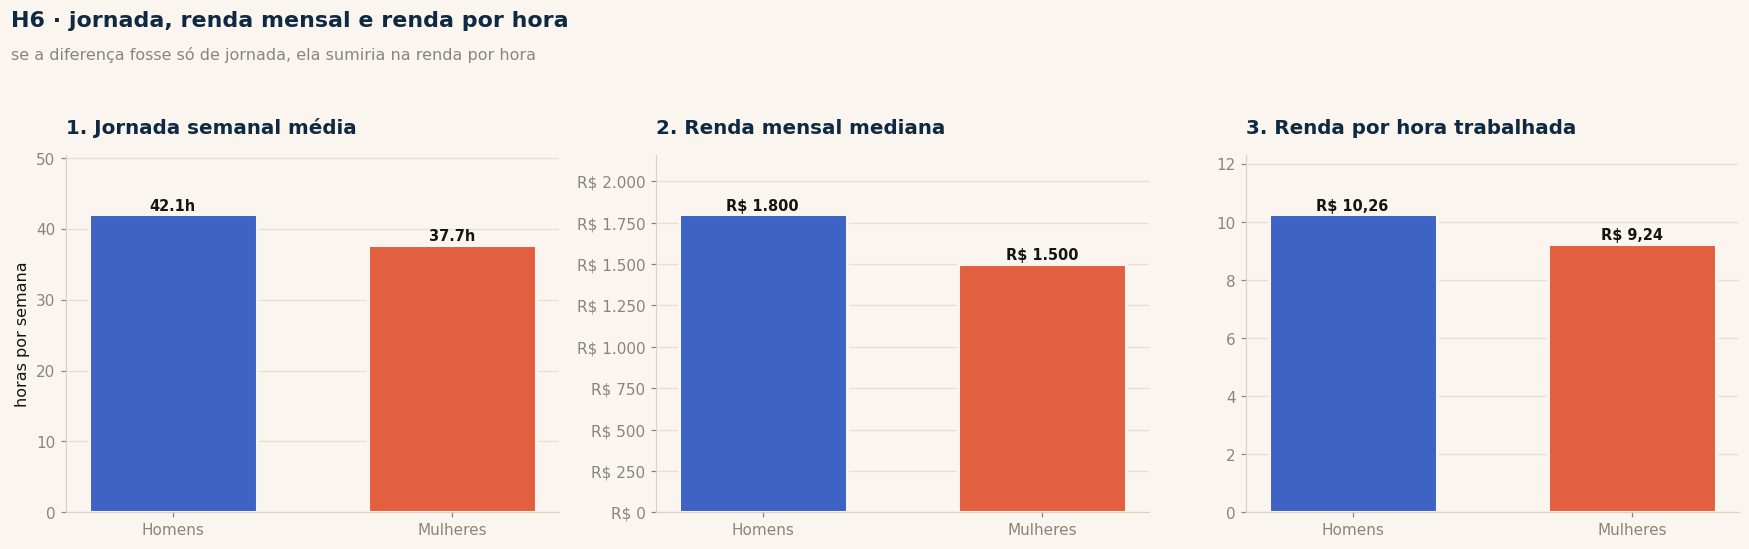

  diferença na JORNADA:        +10.3%  (mulheres trabalham menos horas remuneradas)
  diferença na RENDA MENSAL:   +16.7%
  diferença na RENDA POR HORA: +10.0%


In [32]:
if 'horas_semanais' in estudo.columns:
    trab = estudo[estudo['horas_semanais'].between(1, 98)].copy()
    trab['renda_hora'] = trab['renda'] / (trab['horas_semanais'] * 4.33)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    titulo_fig(fig, 'H6 · jornada, renda mensal e renda por hora',
               'se a diferença fosse só de jornada, ela sumiria na renda por hora')

    a = axes[0]
    hj = resumo_pond(trab, 'sexo', 'horas_semanais').set_index('sexo')
    a.bar(range(2), hj.loc[['homem','mulher'], 'média'],
          color=[COR_SEXO['homem'], COR_SEXO['mulher']], edgecolor=CREME, linewidth=2, width=0.6)
    a.set_xticks(range(2)); a.set_xticklabels(['Homens','Mulheres'])
    a.set_ylim(0, hj['média'].max()*1.2)
    rotulos_v(a, hj.loc[['homem','mulher'], 'média'].values, fmt=lambda v: f'{v:.1f}h')
    a.set_title('1. Jornada semanal média'); a.set_ylabel('horas por semana'); grade(a)

    a = axes[1]
    rm = resumo_pond(trab, 'sexo').set_index('sexo')
    a.bar(range(2), rm.loc[['homem','mulher'], 'mediana'],
          color=[COR_SEXO['homem'], COR_SEXO['mulher']], edgecolor=CREME, linewidth=2, width=0.6)
    a.set_xticks(range(2)); a.set_xticklabels(['Homens','Mulheres'])
    a.set_ylim(0, rm['mediana'].max()*1.2)
    rotulos_v(a, rm.loc[['homem','mulher'], 'mediana'].values)
    a.set_title('2. Renda mensal mediana'); grade(a); eixo_reais(a)

    a = axes[2]
    rh = resumo_pond(trab, 'sexo', 'renda_hora').set_index('sexo')
    a.bar(range(2), rh.loc[['homem','mulher'], 'mediana'],
          color=[COR_SEXO['homem'], COR_SEXO['mulher']], edgecolor=CREME, linewidth=2, width=0.6)
    a.set_xticks(range(2)); a.set_xticklabels(['Homens','Mulheres'])
    a.set_ylim(0, rh['mediana'].max()*1.2)
    rotulos_v(a, rh.loc[['homem','mulher'], 'mediana'].values, fmt=lambda v: brl(v, 2))
    a.set_title('3. Renda por hora trabalhada'); grade(a)
    plt.tight_layout(); plt.show()

    g_horas = gap_pct(hj.loc['homem','média'], hj.loc['mulher','média'])
    g_mes   = gap_pct(rm.loc['homem','mediana'], rm.loc['mulher','mediana'])
    g_hora  = gap_pct(rh.loc['homem','mediana'], rh.loc['mulher','mediana'])
    print(f'  diferença na JORNADA:        {g_horas:+.1f}%  (mulheres trabalham menos horas remuneradas)')
    print(f'  diferença na RENDA MENSAL:   {g_mes:+.1f}%')
    print(f'  diferença na RENDA POR HORA: {g_hora:+.1f}%')
    veredito('H6', 'Parte da diferença vem da jornada, mas não toda',
             f'Mulheres trabalham {g_horas:.1f}% menos horas remuneradas. Mesmo assim, a diferença '
             f'na renda por hora é de {g_hora:+.1f}%.',
             'CONFIRMADA' if g_hora > 0 else 'PARCIALMENTE CONFIRMADA',
             'Renda por hora é a comparação mais justa entre jornadas diferentes.')
else:
    print('A coluna horas_semanais não veio nesta base: a H6 não pode ser testada. '
          'Rode a consulta completa da Parte 1.')

**📖 Como ler a H6, que é a hipótese mais adulta do conjunto:** uma objeção comum a estudos de
desigualdade salarial é *"mas as mulheres trabalham menos horas"*. Ela merece uma resposta com dado,
não com opinião, e é isso que este bloco faz.

O gráfico 1 mostra que **sim**, a jornada remunerada média das mulheres é menor. Mas o gráfico 3
compara o que se ganha **por hora trabalhada**, o que coloca jornadas diferentes na mesma régua.
Se toda a diferença viesse da jornada, o gráfico 3 estaria empatado.

**E a interpretação social do gráfico 1 é o outro lado da mesma moeda:** a jornada remunerada menor
não é escolha livre em um vácuo. Ela convive com o trabalho de cuidado e o trabalho doméstico não
remunerado, que a PNAD Contínua trimestral **não mede nesta base**. Dizer "trabalham menos" sem dizer
"em trabalho remunerado" é omitir metade da jornada.

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# O PLACAR DAS HIPÓTESES
# ══════════════════════════════════════════════════════════════════════════════
tabela(pd.DataFrame(VEREDITOS), 'O placar das hipóteses, para colar no TCC')

hipótese,afirmação,resultado,situação,observação
H1,Mulheres têm renda menor que homens,Na mediana a diferença é de 16.7% e na média é de 22.9%. O teste estatístico dá p = 2.8e-74.,CONFIRMADA,"A mediana e a média discordam de propósito: leia o texto abaixo, é o achado mais fino do trabalho."
H2,Pessoas pretas e pardas têm renda menor que brancas,"A renda mediana da população negra é 25.0% menor, e a média é 39.6% menor, que a da população branca (p = 0.0e+00).",CONFIRMADA,Amarelas e indígenas têm poucos casos na amostra: a posição delas no gráfico não é confiável.
H3,"Mais escolaridade, mais renda",A correlação de ordem é 0.456 (p = 0.0e+00) e a renda mediana sobe a cada degrau.,CONFIRMADA,A escada não é uma reta: o degrau do ensino superior é muito maior que os outros.
H4,A desigualdade persiste dentro do mesmo nível de escolaridade,"A mediana feminina é menor em 7 de 7 níveis, e no ensino superior completo o gap é de 33.3%.",CONFIRMADA,"Nos níveis mais baixos o gap é comprimido pelo piso do salário mínimo, como na H1."
H5,Gênero e raça se somam,O grupo no topo (Homem · branca) tem renda mediana 47.0% maior que o grupo na base (Mulher · negra (preta ou parda)).,CONFIRMADA,A ordem dos grupos do meio pode variar; o topo e a base são o achado robusto.
H6,"Parte da diferença vem da jornada, mas não toda","Mulheres trabalham 10.3% menos horas remuneradas. Mesmo assim, a diferença na renda por hora é de +10.0%.",CONFIRMADA,Renda por hora é a comparação mais justa entre jornadas diferentes.


---
# Parte 9 · Limitações da base (o que a PNAD **não** enxerga)

**Por que esta parte vem antes do modelo, e não no fim:** limitação escrita depois do resultado
parece desculpa. Limitação escrita antes é método. Além disso, cada limitação abaixo muda a
**forma correta de escrever a conclusão**, então ela precisa estar clara antes de a conclusão existir.

| Limitação | O que isso significa na prática | Como escrever a conclusão |
|---|---|---|
| **A base é observacional** | A PNAD observa o que aconteceu, não faz experimento. Ninguém sorteou o gênero das pessoas | Falar em **associação** e **diferença estimada**, nunca em "causa" ou "efeito de ser mulher" |
| **Raça e cor são autodeclaradas** | A pessoa escolhe sua classificação. É o padrão do IBGE e é correto, mas mede identidade declarada, não como a pessoa é percebida socialmente | Dizer "pessoas que se declaram pretas ou pardas" |
| **Só quem tem rendimento entra** | Quem está fora do mercado ficou fora do estudo, e mulheres são maioria nesse grupo | Dizer que a desigualdade medida é uma **subestimação** da total |
| **Trabalho não remunerado é invisível** | Cuidado, trabalho doméstico e trabalho voluntário não aparecem nesta base | Nunca afirmar que "mulheres trabalham menos": elas trabalham menos **em trabalho remunerado** |
| **É uma foto de 2022** | Corte transversal, um ano só. Não dá para ver trajetória nem evolução | Falar de "em 2022", e propor série histórica nos próximos passos |
| **É uma amostra de 5%** | Grupos pequenos (indígenas, amarelas) têm poucos casos | Sempre reportar o n ao lado da estimativa |
| **O peso corrige a representatividade, não o desenho** | A PNAD tem plano amostral complexo (conglomerados e estratos). Os testes deste notebook usam a amostra simples | Dizer que os testes de significância são aproximados, sem correção do efeito de desenho |
| **Faltam variáveis que explicam renda** | Experiência efetiva, tempo na empresa, tamanho da empresa e área de formação não estão aqui | Aceitar um R² moderado como honesto, e não forçar o número |

> **A limitação mais importante de todas, e ela protege o trabalho inteiro:**
> este modelo **descreve** a desigualdade que existe nos dados. Ele não a justifica e não deve
> ser usado para decidir salário de ninguém. Usar um modelo assim para definir remuneração seria
> **automatizar** a desigualdade que ele foi feito para denunciar.

---
# Parte 10 · Preparar para o modelo

**🔎 O que vamos fazer:** escolher quais variáveis o modelo pode ver, separar treino e teste,
e explicar as duas armadilhas que aparecem aqui.

## Armadilha 1: o vazamento (a variável que "sabe demais")

`renda_habitual` (VD4019) é o rendimento **habitual**, e o alvo é o rendimento **efetivo**. São
quase a mesma coisa. Se ela entrar no modelo, o R² sobe para perto de 1 e o trabalho vira uma
fraude involuntária: o modelo não está prevendo renda, está **copiando** a renda. Isso se chama
**vazamento de dados**, e é o erro mais comum em projeto de dados iniciante.

Pela mesma razão, `peso` fica fora: ele não é característica da pessoa, é o desenho da pesquisa.

## Armadilha 2: dois conjuntos de variáveis respondem duas perguntas diferentes

Esta é a decisão mais importante do trabalho, e ela precisa estar no TCC:

| Conjunto | O que ele contém | Que pergunta ele responde |
|---|---|---|
| **A · quem a pessoa é** | sexo, raça/cor, idade, escolaridade, estado, área urbana ou rural | *"Quanto a renda varia com gênero e raça, considerando idade, escolaridade e lugar?"* Mede a diferença **total** que a pessoa encontra no mercado |
| **B · quem a pessoa é + o que ela faz** | tudo do A, mais jornada, posição na ocupação, setor, grupo ocupacional e formalidade | *"Duas pessoas na mesma ocupação, com a mesma jornada e a mesma formalidade, ganham igual?"* Mede a diferença que sobra **dentro do mesmo posto de trabalho** |

**Nenhum dos dois é o certo sozinho.** O conjunto B prevê muito melhor, porque ocupação e jornada
são as variáveis que mais explicam renda. Mas ele **absorve** parte da desigualdade: se as mulheres
são empurradas para ocupações que pagam menos, controlar por ocupação **esconde** justamente esse
empurrão. É o que a literatura chama de *over-control*.

Por isso o trabalho usa os **dois**: o A mede o gap total, o B mede o gap residual, e a **diferença
entre os dois** é a parte da desigualdade que passa pela segregação ocupacional. Isso é a Parte 17.

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.1 OS DOIS CONJUNTOS DE VARIÁVEIS
# ══════════════════════════════════════════════════════════════════════════════
PROIBIDAS = ['renda_habitual',   # vazamento: é quase o próprio alvo
             'peso',             # desenho da pesquisa, não é atributo da pessoa
             'renda',            # o alvo
             'faixa_renda_sm',   # derivada do alvo: vazamento também
             'escolaridade_nome','sexo_raca','grupo_racial','faixa_etaria','faixa_jornada',
             'formalidade','regiao']   # versões "para gráfico" das variáveis que já entram

NUM_A = existe('idade', 'escolaridade', 'anos_estudo', 'pessoas_domicilio')
CAT_A = existe('sexo', 'raca_cor', 'sigla_uf', 'situacao_domicilio', 'tipo_area')

NUM_B = NUM_A + existe('horas_semanais')
CAT_B = CAT_A + existe('posicao_ocupacao', 'setor_atividade', 'grupo_ocupacional',
                       'contribui_previdencia')

CONJUNTOS = {'A · perfil': (NUM_A, CAT_A)}
if TEM_TRABALHO:
    CONJUNTOS['B · perfil + trabalho'] = (NUM_B, CAT_B)

for nome, (n_, c_) in CONJUNTOS.items():
    print(f'{nome}')
    print(f'   numéricas   ({len(n_)}): {", ".join(n_)}')
    print(f'   categóricas ({len(c_)}): {", ".join(c_)}')
    print(f'   total: {len(n_)+len(c_)} variáveis\n')
print('Fora do modelo, de propósito:', ', '.join([p for p in PROIBIDAS if p in estudo.columns]))

A · perfil
   numéricas   (4): idade, escolaridade, anos_estudo, pessoas_domicilio
   categóricas (5): sexo, raca_cor, sigla_uf, situacao_domicilio, tipo_area
   total: 9 variáveis

B · perfil + trabalho
   numéricas   (5): idade, escolaridade, anos_estudo, pessoas_domicilio, horas_semanais
   categóricas (9): sexo, raca_cor, sigla_uf, situacao_domicilio, tipo_area, posicao_ocupacao, setor_atividade, grupo_ocupacional, contribui_previdencia
   total: 14 variáveis

Fora do modelo, de propósito: renda_habitual, peso, renda, faixa_renda_sm, escolaridade_nome, sexo_raca, grupo_racial, faixa_etaria, faixa_jornada, formalidade, regiao


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.2 SEPARAR TREINO E TESTE
# ══════════════════════════════════════════════════════════════════════════════
NUM_MAX, CAT_MAX = (NUM_B, CAT_B) if TEM_TRABALHO else (NUM_A, CAT_A)

X = estudo[NUM_MAX + CAT_MAX].copy()
y = estudo['renda'].copy()

# Estratificar por FAIXA de renda: o alvo é contínuo, mas dá para garantir que treino e
# teste tenham a mesma proporção de gente pobre, de classe média e de renda alta.
faixas = pd.qcut(y, 10, labels=False, duplicates='drop')

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEMENTE, stratify=faixas)

# guardamos o peso e as colunas de leitura das MESMAS linhas do teste, para a Parte 17
extras_te = estudo.loc[X_te.index, existe('peso', 'sexo_raca', 'grupo_racial', 'escolaridade_nome')]

# a trava contra vazamento: nenhuma coluna proibida pode estar no X
vazou = [c for c in PROIBIDAS if c in X.columns]
assert not vazou, f'VAZAMENTO: {vazou} não pode entrar no modelo!'
print('✅ Checagem de vazamento: nenhuma coluna proibida entrou no X.\n')

print(f'Treino: {num(len(X_tr))} pessoas   |   Teste: {num(len(X_te))} pessoas (o cofre 🔒)\n')
conf = pd.DataFrame({
    'treino': [brl(y_tr.median()), brl(y_tr.mean()), f"{(X_tr['sexo']=='mulher').mean()*100:.1f}%"],
    'teste':  [brl(y_te.median()), brl(y_te.mean()), f"{(X_te['sexo']=='mulher').mean()*100:.1f}%"]},
    index=['renda mediana', 'renda média', '% de mulheres'])
display(conf)
print('Os dois lados parecidos = sorteio honesto. Se estivessem diferentes, a comparação seria injusta.')

for nome, obj in [('04_X_treino', X_tr), ('04_X_teste', X_te),
                  ('04_y_treino', y_tr.to_frame()), ('04_y_teste', y_te.to_frame())]:
    obj.to_parquet(f'dados/{nome}.parquet')
print('\nCheckpoint 04 salvo.')

✅ Checagem de vazamento: nenhuma coluna proibida entrou no X.

Treino: 30.046 pessoas   |   Teste: 10.016 pessoas (o cofre 🔒)



,treino,teste
renda mediana,R$ 1.500,R$ 1.500
renda média,R$ 2.656,R$ 2.612
% de mulheres,42.1%,41.9%


Os dois lados parecidos = sorteio honesto. Se estivessem diferentes, a comparação seria injusta.

Checkpoint 04 salvo.


**📖 Como ler, e tem uma correção metodológica aqui em relação à versão anterior do notebook:**

O teste é o **cofre**. Ele é aberto **uma vez só**, no fim, com o modelo já escolhido. Enquanto a
gente estiver comparando ideias, a régua é a **validação cruzada dentro do treino**. O motivo é
simples de entender e fácil de errar: se você testa vinte ideias no conjunto de teste e escolhe a
melhor, o teste virou treino disfarçado, e o resultado final sai otimista demais.

Sobre o **stratify**: dizem por aí que "estratificar só serve para classificação, porque alvo
contínuo não tem classes". A ideia por trás está certa, mas dá para resolver: a gente **cria** as
classes a partir do alvo (dez faixas de renda) e estratifica por elas. Assim treino e teste têm a
mesma proporção de gente em cada faixa, e a comparação fica mais estável.

---
# Parte 11 · Seleção de variáveis: quem ajuda e quem é repetição

**🔎 O que vamos fazer:** medir a força de cada variável **só no treino**, com a ferramenta certa
para cada tipo de par.

**O guia de bolso:**

| O par | A ferramenta | O que ela responde |
|---|---|---|
| número x número | correlação de Pearson | Sobe junto **em linha reta**? Tem sinal (+ ou -) |
| número x número | informação mútua | Tem relação de **qualquer formato**, mesmo curva? Não tem sinal |
| categoria x número (o alvo) | eta² (razão de variância) | O quanto a categoria **separa** o alvo em grupos distintos |
| categoria x categoria | V de Cramér | Uma categoria **já contém** a informação da outra? |

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# 11.1 AS NUMÉRICAS
# ══════════════════════════════════════════════════════════════════════════════
X_num = X_tr[NUM_MAX].apply(pd.to_numeric, errors='coerce')
X_num = X_num.fillna(X_num.median())   # mediana do TREINO, só para os testes

mesa = pd.DataFrame({
    'correlação (com sinal)': X_num.corrwith(y_tr).round(3),
    'correlação com log(renda)': X_num.corrwith(np.log(y_tr)).round(3),
    'informação mútua': pd.Series(mutual_info_regression(X_num, y_tr, random_state=SEMENTE),
                                  index=NUM_MAX).round(3),
}).sort_values('informação mútua', ascending=False)
tabela(mesa.reset_index().rename(columns={'index': 'variável'}),
       '11.1 A mesa das numéricas', casas=3)

variável,correlação (com sinal),correlação com log(renda),informação mútua
escolaridade,"0,180","0,438","0,153"
horas_semanais,"0,108","0,378","0,146"
anos_estudo,"0,166","0,424","0,146"
idade,"0,075","0,094","0,053"
pessoas_domicilio,"-0,041","-0,084","0,009"


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# 11.2 AS CATEGÓRICAS CONTRA O ALVO (eta²)
# ══════════════════════════════════════════════════════════════════════════════
def eta2(cat, alvo):
    """Quanto da variação do alvo é explicada por pertencer a cada categoria (0 a 1)."""
    d = pd.DataFrame({'c': cat.astype('object'), 'y': alvo}).dropna()
    media_geral = d['y'].mean()
    entre = d.groupby('c')['y'].agg(['mean', 'count'])
    sq_entre = (entre['count'] * (entre['mean'] - media_geral)**2).sum()
    sq_total = ((d['y'] - media_geral)**2).sum()
    return sq_entre / sq_total

forca = pd.DataFrame([{
    'variável': c,
    'categorias': X_tr[c].nunique(),
    'eta² (renda)': round(eta2(X_tr[c], y_tr), 4),
    'eta² (log da renda)': round(eta2(X_tr[c], np.log(y_tr)), 4),
} for c in CAT_MAX]).sort_values('eta² (log da renda)', ascending=False)
tabela(forca, '11.2 A força das categóricas', casas=4)

,variável,categorias,eta² (renda),eta² (log da renda)
7,grupo_ocupacional,10,"0,0564","0,2444"
5,posicao_ocupacao,10,"0,0491","0,2281"
8,contribui_previdencia,2,"0,0169","0,2080"
6,setor_atividade,12,"0,0201","0,1407"
2,sigla_uf,27,"0,0113","0,1127"
3,situacao_domicilio,2,"0,0039","0,0530"
1,raca_cor,6,"0,0090","0,0527"
4,tipo_area,4,"0,0059","0,0284"
0,sexo,2,"0,0019","0,0085"


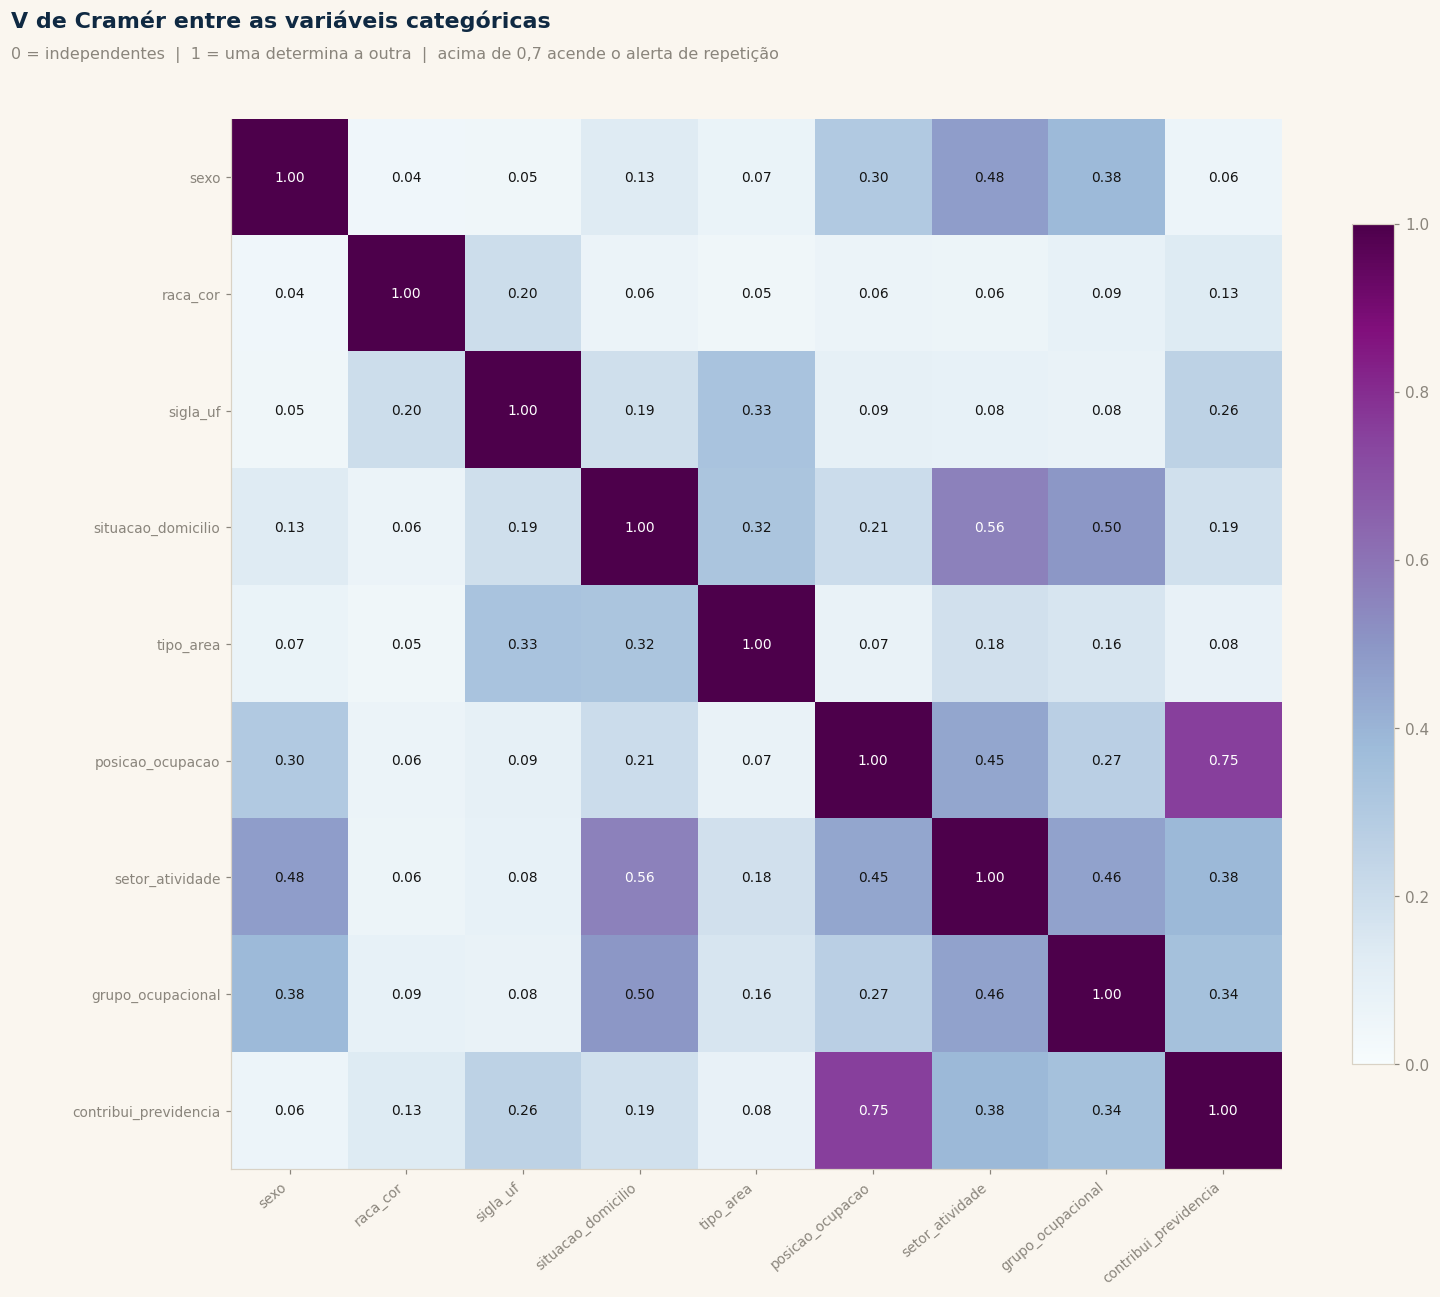

Pares com informação muito repetida (V acima de 0,7): [('posicao_ocupacao', 'contribui_previdencia', np.float64(0.7518818068495208))]


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# 11.3 V DE CRAMÉR: informação repetida entre as categóricas?
# ══════════════════════════════════════════════════════════════════════════════
def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(t)[0]
    n_, k = t.values.sum(), min(t.shape) - 1
    return np.sqrt(chi2 / (n_ * k)) if k > 0 else np.nan

M = pd.DataFrame(index=CAT_MAX, columns=CAT_MAX, dtype=float)
for i, a in enumerate(CAT_MAX):
    for b in CAT_MAX[i:]:
        v = 1.0 if a == b else cramers_v(X_tr[a], X_tr[b])
        M.loc[a, b] = M.loc[b, a] = v

fig, ax = painel('V de Cramér entre as variáveis categóricas',
                 '0 = independentes  |  1 = uma determina a outra  |  acima de 0,7 acende o alerta de repetição',
                 figsize=(1.1*len(CAT_MAX)+4.5, 0.9*len(CAT_MAX)+3.2))
im = ax.imshow(M.values.astype(float), cmap='BuPu', vmin=0, vmax=1)
ax.set_xticks(range(len(CAT_MAX))); ax.set_xticklabels(CAT_MAX, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(CAT_MAX))); ax.set_yticklabels(CAT_MAX, fontsize=9)
for i in range(len(CAT_MAX)):
    for j in range(len(CAT_MAX)):
        v = M.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if v > 0.55 else TINTA)
ax.grid(False); plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

pares_altos = [(a, b, M.loc[a, b]) for i, a in enumerate(CAT_MAX) for b in CAT_MAX[i+1:]
               if M.loc[a, b] > 0.7]
print('Pares com informação muito repetida (V acima de 0,7):',
      pares_altos if pares_altos else 'nenhum. Todas as categóricas ficam.')

**📖 Como ler a seleção, e a decisão que sai daqui:**

1. **`escolaridade` e `anos_estudo` medem quase a mesma coisa**, e isso aparece na correlação alta
   entre as duas. Modelos de árvore lidam bem com isso (eles simplesmente escolhem uma), então
   mantemos as duas. Em uma regressão linear, essa repetição atrapalharia a leitura dos coeficientes,
   e é bom saber disso.
2. **`grupo_ocupacional` e `setor_atividade` costumam ter V de Cramér médio**: quem é operária tende
   a estar na indústria. Médio não é repetição total, e as duas trazem coisas diferentes.
3. **A correlação com o log da renda é quase sempre maior** do que com a renda em reais. Esse é mais
   um sinal, agora numérico, de que a escala natural da renda é a multiplicativa. Ele volta na Parte 14.

> **A decisão sobre sexo e raça, que precisa estar escrita no TCC:** essas duas variáveis entram no
> modelo **porque o objetivo é medir a desigualdade**, e não para decidir o salário de ninguém.
> Um modelo que descreve a injustiça existente é uma ferramenta de denúncia; o mesmo modelo usado
> para definir remuneração seria uma ferramenta de automação da injustiça. É a mesma equação com
> dois usos opostos, e a diferença está inteira na finalidade.

---
# Parte 12 · A régua: como saber se o modelo é bom

**🔎 O que vamos fazer:** definir a métrica **antes** de rodar qualquer modelo, para não escolher a
régua que favorece o resultado que a gente gostou.

$$\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i| \qquad
\text{RMSE} = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2} \qquad
R^2 = 1 - \frac{\text{erro do modelo}}{\text{erro do chute constante}}$$

| Métrica | Em português | Quando ela é a certa | Cuidado |
|---|---|---|---|
| **MAE** | "em média, erramos R$ X" | Quando o erro precisa ser **explicável** para pessoas | Trata errar R$ 500 numa renda de R$ 1.000 igual a errar R$ 500 numa de R$ 20.000 |
| **RMSE** | o erro que **pune erro grande** | Quando errar muito é desproporcionalmente ruim | Com cauda longa, ele fica bem acima do MAE. Isso é a cauda, não é defeito |
| **R²** | quanto do vaivém da renda o modelo explica | Para comparar com o chute constante | Não é nota de prova. R² baixo em dado social pode ser honesto |
| **Erro % mediano** | "metade das previsões erra menos que X%" | Renda, onde o que importa é o erro **em proporção** | Precisa que o alvo seja maior que zero |

**A escolha deste trabalho: o MAE é o critério de decisão.** Motivo: é a métrica que a gente
consegue explicar em uma frase para qualquer pessoa, e o TCC é sobre comunicar desigualdade. As
outras três aparecem sempre ao lado, como contexto.

**E os dois chutes que todo modelo tem que vencer:**
- chutar sempre a **média** para todo mundo;
- chutar sempre a **mediana** para todo mundo. Este é o piso justo quando a métrica é o MAE,
  porque a mediana é exatamente o número que minimiza o erro absoluto. Vencer só o chute da média
  é fácil demais.

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.1 A FUNÇÃO QUE MEDE, E OS DOIS CHUTES
# ══════════════════════════════════════════════════════════════════════════════
def avaliar(y_real, y_prev):
    y_real = np.asarray(y_real, float); y_prev = np.asarray(y_prev, float)
    ok = y_real > 0
    return {
        'MAE (R$)':  round(mean_absolute_error(y_real, y_prev), 0),
        'RMSE (R$)': round(float(np.sqrt(mean_squared_error(y_real, y_prev))), 0),
        'R²':        round(r2_score(y_real, y_prev), 3),
        'erro % mediano': round(float(np.median(np.abs(y_prev[ok]-y_real[ok])/y_real[ok])*100), 1),
    }

chute_media   = np.full(len(y_te), y_tr.mean())
chute_mediana = np.full(len(y_te), y_tr.median())
pisos = pd.DataFrame([
    {'chute': 'sempre a média do treino',   **avaliar(y_te, chute_media)},
    {'chute': 'sempre a mediana do treino', **avaliar(y_te, chute_mediana)},
])
tabela(pisos, '12.1 Os dois pisos que todo modelo precisa vencer', casas=1)
PISO_MAE = pisos['MAE (R$)'].min()
print(f'O piso a bater (o menor MAE dos dois chutes): {brl(PISO_MAE)}')

chute,MAE (R$),RMSE (R$),R²,erro % mediano
sempre a média do treino,"1.957,0","3.828,0","-0,0","77,0"
sempre a mediana do treino,"1.644,0","3.986,0","-0,1","40,0"


O piso a bater (o menor MAE dos dois chutes): R$ 1.644


---
# Parte 13 · Os modelos: quem são e por que cada um está aqui

**🔎 O que vamos fazer:** rodar sete famílias de modelo na mesma prova e comparar por **validação
cruzada dentro do treino**.

**Como funciona a validação cruzada, em uma frase:** em vez de confiar em uma única divisão, a
gente parte o treino em 4 pedaços, treina em 3 e testa no que sobrou, repete quatro vezes e tira a
média. Assim o resultado não depende da sorte de uma divisão específica, e a gente ainda ganha um
**desvio**, que diz o quanto o número balança.

| Família | Como ela pensa | Por que ela está aqui | O que ela não consegue |
|---|---|---|---|
| **Chute constante** | ignora tudo e sempre responde o mesmo número | É o piso. Sem ele, não dá para saber se o modelo aprendeu | Tudo |
| **Regressão Linear** | soma pesos fixos: "cada ano de estudo vale +R$ X" | Coeficiente legível, ótimo para explicar no TCC | Só desenha reta: perde o salto do ensino superior |
| **Ridge e Lasso** | regressão linear com freio | Evitam pesos absurdos quando variáveis se repetem. O Lasso ainda zera as inúteis | Continuam sendo retas |
| **Árvore de decisão** | faz perguntas em cascata: "tem superior? trabalha mais de 40h?" | É o modelo mais fácil de mostrar e explicar visualmente | Sozinha, decora o treino |
| **Random Forest** | centenas de árvores diferentes votando | Robusta, quase sem ajuste, captura curva e interação | Pesada e difícil de ler |
| **Gradient Boosting** | árvores em série, cada uma corrigindo o erro da anterior | Costuma ser o melhor em dados de tabela | Mais lento e mais sensível a ajuste |
| **HistGB e LightGBM** | o mesmo boosting, com os números agrupados em caixas | Muito mais rápidos, mesma qualidade ou melhor | Mesmas limitações do boosting |

**Por que boosting tende a ganhar aqui, e isso vem direto da EDA:** a renda tem **degrau**
(o salto do diploma superior) e tem **interação** (o efeito de trabalhar 44 horas não é o mesmo
para quem é empregadora e para quem é conta própria). Reta não representa degrau, e reta sem
interação não representa "depende de". Árvore em série representa os dois.

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.1 O PREPARO (dentro do Pipeline: só aprende no treino)
# ══════════════════════════════════════════════════════════════════════════════
def novo_preparo(num_cols, cat_cols):
    """Preparo ZERADO. Função, e não objeto solto, para nunca reaproveitar um
    transformador já treinado em outro lugar (fonte clássica de vazamento)."""
    return ColumnTransformer([
        ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                          ('escala',    StandardScaler())]), num_cols),
        ('cat', Pipeline([('preencher', SimpleImputer(strategy='most_frequent')),
                          ('codificar', OneHotEncoder(handle_unknown='ignore',
                                                      sparse_output=False))]), cat_cols)])

def fluxo(modelo, num_cols=None, cat_cols=None, em_log=False):
    """Monta o Pipeline completo. em_log=True treina no log da renda e devolve reais."""
    num_cols = NUM_MAX if num_cols is None else num_cols
    cat_cols = CAT_MAX if cat_cols is None else cat_cols
    p = Pipeline([('preparo', novo_preparo(num_cols, cat_cols)), ('modelo', clone(modelo))])
    if em_log:
        return TransformedTargetRegressor(regressor=p, func=np.log, inverse_func=np.exp)
    return p

try:
    import lightgbm as lgb
    TEM_LGBM = True
except ImportError:
    print('LightGBM não encontrado, instalando...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm'], check=False)
    try:
        import lightgbm as lgb; TEM_LGBM = True
    except ImportError:
        TEM_LGBM = False; print('Seguimos sem LightGBM: todo o resto funciona.')

from sklearn.tree import DecisionTreeRegressor
print('Preparo pronto.  LightGBM disponível:', TEM_LGBM)
print(f'Variáveis do modelo: {len(NUM_MAX)} numéricas + {len(CAT_MAX)} categóricas')

Preparo pronto.  LightGBM disponível: True
Variáveis do modelo: 5 numéricas + 9 categóricas


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.2 A PRIMEIRA RODADA: sete famílias, mesma prova
#      (validação cruzada de 4 partes, no TREINO. O teste continua trancado.)
# ══════════════════════════════════════════════════════════════════════════════
cv = KFold(n_splits=4, shuffle=True, random_state=SEMENTE)

familias = {
    'Chute da média':      DummyRegressor(strategy='mean'),
    'Chute da mediana':    DummyRegressor(strategy='quantile', quantile=0.5),
    'Regressão Linear':    LinearRegression(),
    'Ridge':               Ridge(alpha=1.0),
    'Lasso':               Lasso(alpha=1.0, max_iter=5000),
    'Árvore de decisão':   DecisionTreeRegressor(max_depth=8, min_samples_leaf=40, random_state=SEMENTE),
    'Random Forest':       RandomForestRegressor(n_estimators=200, max_depth=16, min_samples_leaf=5,
                                                 random_state=SEMENTE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, learning_rate=0.06,
                                                     max_depth=3, random_state=SEMENTE),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=300, learning_rate=0.07,
                                                          random_state=SEMENTE),
}
if TEM_LGBM:
    familias['LightGBM'] = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                             random_state=SEMENTE, n_jobs=-1, verbose=-1)

def medir_cv(est, X_, y_, nome=''):
    r = cross_validate(est, X_, y_, cv=cv, n_jobs=-1,
                       scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'))
    return {'modelo': nome,
            'MAE_cv (R$)':  round(-r['test_neg_mean_absolute_error'].mean(), 0),
            'desvio (R$)':  round(r['test_neg_mean_absolute_error'].std(), 0),
            'RMSE_cv (R$)': round(-r['test_neg_root_mean_squared_error'].mean(), 0),
            'R²_cv':        round(r['test_r2'].mean(), 3),
            'segundos':     round(r['fit_time'].mean(), 1)}

print('Rodando a validação cruzada. Isto leva alguns minutos.\n')
linhas, ESTIMADORES = [], {}
for nome, m in familias.items():
    est = fluxo(m)
    ESTIMADORES[nome] = est
    linhas.append(medir_cv(est, X_tr, y_tr, nome))
    print(f"  ✓ {nome:<22} MAE_cv {brl(linhas[-1]['MAE_cv (R$)']):>10}   "
          f"R² {linhas[-1]['R²_cv']:>6}   ({linhas[-1]['segundos']}s por treino)")

placar1 = pd.DataFrame(linhas).sort_values('MAE_cv (R$)').reset_index(drop=True)
tabela(placar1, '13.2 Primeira rodada: as famílias na mesma régua', casas=1)

Rodando a validação cruzada. Isto leva alguns minutos.

  ✓ Chute da média         MAE_cv   R$ 2.001   R²   -0.0   (0.2s por treino)
  ✓ Chute da mediana       MAE_cv   R$ 1.687   R² -0.058   (0.2s por treino)
  ✓ Regressão Linear       MAE_cv   R$ 1.635   R²  0.189   (0.4s por treino)
  ✓ Ridge                  MAE_cv   R$ 1.635   R²  0.189   (0.2s por treino)
  ✓ Lasso                  MAE_cv   R$ 1.630   R²  0.189   (0.7s por treino)
  ✓ Árvore de decisão      MAE_cv   R$ 1.513   R²  0.139   (0.5s por treino)
  ✓ Random Forest          MAE_cv   R$ 1.409   R²   0.16   (53.7s por treino)
  ✓ Gradient Boosting      MAE_cv   R$ 1.441   R² -0.301   (24.1s por treino)
  ✓ HistGradientBoosting   MAE_cv   R$ 1.446   R²  0.174   (1.3s por treino)
  ✓ LightGBM               MAE_cv   R$ 1.454   R²  0.035   (8.8s por treino)


modelo,MAE_cv (R$),desvio (R$),RMSE_cv (R$),R²_cv,segundos
Random Forest,"1.409,0","59,0","5.621,0","0,2","53,7"
Gradient Boosting,"1.441,0","50,0","6.259,0","-0,3","24,1"
HistGradientBoosting,"1.446,0","42,0","5.582,0","0,2","1,3"
LightGBM,"1.454,0","44,0","5.846,0","0,0","8,8"
Árvore de decisão,"1.513,0","52,0","5.678,0","0,1","0,5"
Lasso,"1.630,0","44,0","5.560,0","0,2","0,7"
Regressão Linear,"1.635,0","44,0","5.560,0","0,2","0,4"
Ridge,"1.635,0","44,0","5.560,0","0,2","0,2"
Chute da mediana,"1.687,0","74,0","6.152,0","-0,1","0,2"
Chute da média,"2.001,0","72,0","6.025,0","-0,0","0,2"


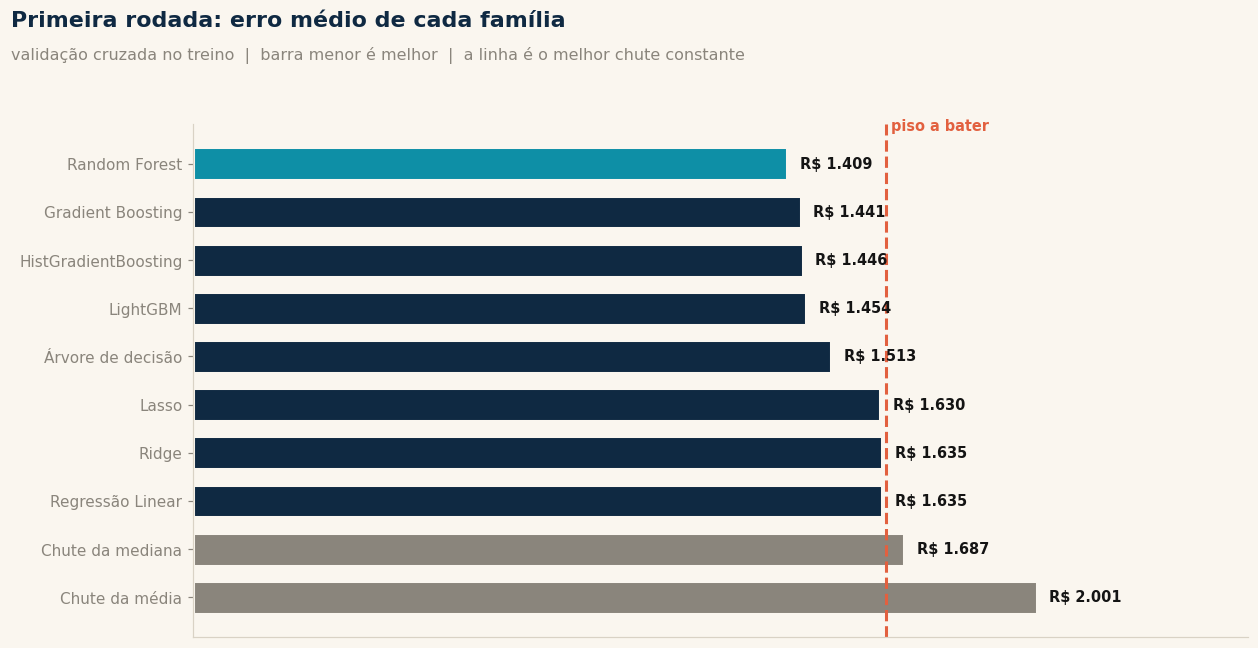

In [42]:
# o gráfico do placar
p1 = placar1.sort_values('MAE_cv (R$)', ascending=False)
fig, ax = painel('Primeira rodada: erro médio de cada família',
                 'validação cruzada no treino  |  barra menor é melhor  |  a linha é o melhor chute constante',
                 figsize=(11.5, 5.4))
cores_p = [CINZA if 'Chute' in m else (TEAL if i == len(p1)-1 else NAVY)
           for i, m in enumerate(p1['modelo'])]
ax.barh(p1['modelo'], p1['MAE_cv (R$)'], color=cores_p, edgecolor=CREME, linewidth=2, height=0.68)
ax.axvline(PISO_MAE, color=CORAL, ls='--', lw=2)
ax.text(PISO_MAE, len(p1)-0.3, ' piso a bater', color=CORAL, fontsize=9.5, fontweight='bold')
ax.set_xlim(0, p1['MAE_cv (R$)'].max()*1.25); ax.set_xticks([]); grade(ax, 'x')
for i, v in enumerate(p1['MAE_cv (R$)']):
    ax.text(v + p1['MAE_cv (R$)'].max()*0.015, i, brl(v), va='center', fontsize=9.5, fontweight='bold')
plt.tight_layout(); plt.show()

**📖 Como ler a primeira rodada:**

- **Os dois chutes constantes são o piso.** Qualquer modelo que não fique claramente abaixo deles
  não aprendeu nada, e o chute da mediana é o piso mais difícil quando a régua é o MAE.
- **A distância entre a Regressão Linear e o boosting é a curvatura da renda.** A linear é obrigada
  a desenhar retas; o boosting representa o degrau do diploma e as interações. A diferença entre as
  duas barras é, literalmente, o quanto a renda **não** é uma reta.
- **A coluna `segundos` existe para uma decisão prática.** Se um modelo ganha 1% de erro e demora
  dez vezes mais, talvez não compense. Aqui o custo é baixo, mas saber olhar isso é parte do ofício.
- **A coluna `desvio` é a honestidade da comparação.** Se dois modelos estão a R$ 10 de distância e
  o desvio é de R$ 50, eles estão **empatados**, e escolher o "melhor" seria escolher ruído.

In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.3 O CONJUNTO A CONTRA O CONJUNTO B (a decisão da Parte 10, medida)
# ══════════════════════════════════════════════════════════════════════════════
if TEM_TRABALHO:
    melhor_alg = placar1.loc[~placar1['modelo'].str.contains('Chute'), 'modelo'].iloc[0]
    print(f'Usando a mesma família nos dois conjuntos, para a comparação ser justa: {melhor_alg}\n')
    comp = []
    for nome_c, (n_, c_) in CONJUNTOS.items():
        est = fluxo(familias[melhor_alg], n_, c_)
        r = medir_cv(est, X_tr[n_+c_], y_tr, nome_c)
        r['variáveis'] = len(n_) + len(c_)
        comp.append(r)
    comp = pd.DataFrame(comp).rename(columns={'modelo': 'conjunto'})
    comp['queda do erro'] = ((comp['MAE_cv (R$)'].iloc[0] - comp['MAE_cv (R$)']) /
                             comp['MAE_cv (R$)'].iloc[0] * 100).round(1)
    tabela(comp[['conjunto', 'variáveis', 'MAE_cv (R$)', 'RMSE_cv (R$)', 'R²_cv', 'queda do erro']],
           '13.3 O que o modelo ganha ao enxergar o trabalho', casas=1)
    print(f"Enxergar jornada, ocupação, setor e formalidade reduz o erro em "
          f"{comp['queda do erro'].iloc[-1]:.1f}% e leva o R² de "
          f"{comp['R²_cv'].iloc[0]} para {comp['R²_cv'].iloc[-1]}.")
else:
    print('Sem as colunas de trabalho, só existe o conjunto A. Rode a consulta completa da Parte 1 '
          'para ter esta comparação, que é uma das mais importantes do trabalho.')

Usando a mesma família nos dois conjuntos, para a comparação ser justa: Random Forest



conjunto,variáveis,MAE_cv (R$),RMSE_cv (R$),R²_cv,queda do erro
A · perfil,9,"1.625,0","5.878,0","0,1","0,0"
B · perfil + trabalho,14,"1.409,0","5.621,0","0,2","13,3"


Enxergar jornada, ocupação, setor e formalidade reduz o erro em 13.3% e leva o R² de 0.056 para 0.16.


**📖 Como ler a comparação A contra B, e este é o diagnóstico do problema da versão anterior do notebook:**

O modelo antigo enxergava **cinco variáveis**: sexo, raça, idade, escolaridade e estado. Com isso ele
não tinha como saber se a pessoa trabalha 4 horas ou 44 por semana, se é empregada com carteira ou
conta própria, se está na administração pública ou em serviços domésticos. E essas são justamente as
variáveis que mais determinam quanto se ganha no Brasil.

Não era um problema de algoritmo: **era um problema de informação**. Nenhum ajuste de
hiperparâmetro compensa uma variável que não está na tabela.

**A leitura correta do ganho, e ela precisa aparecer no TCC:** o conjunto B prevê melhor, mas ele
responde outra pergunta. Ao controlar por ocupação, o modelo passa a comparar *pessoas dentro do
mesmo tipo de trabalho*, e a desigualdade que opera **empurrando as mulheres para ocupações que
pagam menos** deixa de aparecer no coeficiente de gênero. A diferença entre os dois é informação,
e é o que a Parte 17 vai decompor.

---
# Parte 14 · O ajuste fino: as alavancas que fazem o erro cair

**🔎 O que vamos fazer:** pegar as duas melhores famílias e testar quatro mudanças, **uma por vez**,
para medir quanto cada uma rende. Isso é método, e não tentativa e erro.

### Alavanca 1 · treinar no **log** da renda
A renda tem cauda longa. Um modelo treinado em reais gasta quase toda a energia tentando acertar as
poucas pessoas de renda muito alta, e erra sistematicamente a maioria. Treinando no logaritmo, o
modelo passa a minimizar erro **em proporção**: errar R$ 200 num salário de R$ 1.000 pesa igual a
errar R$ 2.000 num salário de R$ 10.000. É assim que desigualdade de renda funciona de verdade.
O `TransformedTargetRegressor` aplica o log antes de treinar e a exponencial depois de prever,
então **as previsões continuam saindo em reais** e nada muda no resto do notebook.

### Alavanca 2 · treinar com a **mesma métrica** que vai julgar
O Gradient Boosting padrão minimiza erro **quadrático**, mas nós julgamos por **MAE**. É treinar
para uma prova e ser avaliado em outra. Trocar a função de perda para `absolute_error` alinha as duas.

### Alavanca 3 · mais árvores com passo menor
Boosting aprende em passos. Passo menor com mais passos costuma chegar mais longe do que passo
grande com poucos passos, ao custo de tempo.

### Alavanca 4 · a busca de hiperparâmetros
Só depois de escolher a estrutura é que vale procurar os detalhes: profundidade, número de folhas,
taxa de aprendizado. Fazer isso antes é ajustar a moldura de um quadro que ainda não foi pintado.

Testando as alavancas (validação cruzada no treino):

  ✓ GB padrão (ponto de partida)             MAE_cv   R$ 1.441  (26.9s)
  ✓ GB no log da renda                       MAE_cv   R$ 1.253  (24.4s)
  ✓ GB com perda absoluta                    MAE_cv   R$ 1.262  (37.2s)
  ✓ GB mais fundo, passo menor               MAE_cv   R$ 1.442  (70.9s)
  ✓ GB fundo no log da renda                 MAE_cv   R$ 1.227  (73.1s)
  ✓ HistGB no log da renda                   MAE_cv   R$ 1.228  (3.6s)
  ✓ LightGBM no log da renda                 MAE_cv   R$ 1.229  (10.7s)


modelo,alavanca,MAE_cv (R$),desvio (R$),RMSE_cv (R$),R²_cv,ganho %,segundos
GB fundo no log da renda,1 + 3,"1.227,0","77,0","5.479,0","0,2","14,9","73,1"
HistGB no log da renda,1 + motor rápido,"1.228,0","75,0","5.490,0","0,2","14,8","3,6"
LightGBM no log da renda,1 + motor rápido,"1.229,0","76,0","5.474,0","0,2","14,7","10,7"
GB no log da renda,1 (escala do alvo),"1.253,0","77,0","5.547,0","0,2","13,0","24,4"
GB com perda absoluta,2 (perda = métrica),"1.262,0","78,0","5.633,0","0,2","12,4","37,2"
GB padrão (ponto de partida),-,"1.441,0","50,0","6.259,0","-0,3","0,0","26,9"
"GB mais fundo, passo menor","3 (mais árvores, passo menor)","1.442,0","50,0","6.929,0","-0,6","-0,1","70,9"


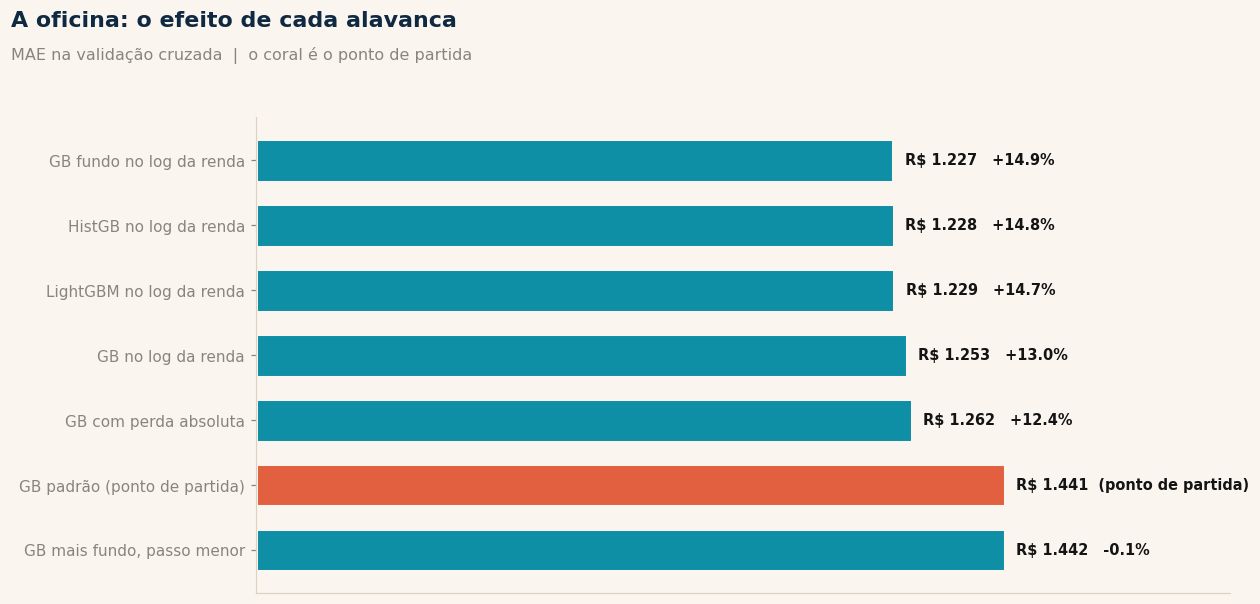

In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# 14.1 AS ALAVANCAS, UMA POR VEZ
# ══════════════════════════════════════════════════════════════════════════════
base_gb   = GradientBoostingRegressor(n_estimators=200, learning_rate=0.06, max_depth=3,
                                      random_state=SEMENTE)
base_hist = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.07, random_state=SEMENTE)

PARTIDA = 'GB padrão (ponto de partida)'
oficina = {
 PARTIDA:                        fluxo(base_gb),
 'GB no log da renda':           fluxo(base_gb, em_log=True),
 'GB com perda absoluta':        fluxo(GradientBoostingRegressor(
                                     n_estimators=300, learning_rate=0.06, max_depth=3,
                                     loss='absolute_error', random_state=SEMENTE)),
 'GB mais fundo, passo menor':   fluxo(GradientBoostingRegressor(
                                     n_estimators=500, learning_rate=0.03, max_depth=5,
                                     subsample=0.8, random_state=SEMENTE)),
 'GB fundo no log da renda':     fluxo(GradientBoostingRegressor(
                                     n_estimators=500, learning_rate=0.03, max_depth=5,
                                     subsample=0.8, random_state=SEMENTE), em_log=True),
 'HistGB no log da renda':       fluxo(base_hist, em_log=True),
}
if TEM_LGBM:
    oficina['LightGBM no log da renda'] = fluxo(lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.04, num_leaves=48, random_state=SEMENTE,
        n_jobs=-1, verbose=-1), em_log=True)

ALAVANCA = {PARTIDA: '-', 'GB no log da renda': '1 (escala do alvo)',
            'GB com perda absoluta': '2 (perda = métrica)',
            'GB mais fundo, passo menor': '3 (mais árvores, passo menor)',
            'GB fundo no log da renda': '1 + 3', 'HistGB no log da renda': '1 + motor rápido',
            'LightGBM no log da renda': '1 + motor rápido'}

print('Testando as alavancas (validação cruzada no treino):\n')
linhas_of = []
for nome, est in oficina.items():
    linhas_of.append(medir_cv(est, X_tr, y_tr, nome))
    print(f"  ✓ {nome:<40} MAE_cv {brl(linhas_of[-1]['MAE_cv (R$)']):>10}  "
          f"({linhas_of[-1]['segundos']}s)")

of = pd.DataFrame(linhas_of)
partida = of.loc[of['modelo'] == PARTIDA, 'MAE_cv (R$)'].iloc[0]
of['ganho %'] = ((partida - of['MAE_cv (R$)']) / partida * 100).round(1)
of['alavanca'] = of['modelo'].map(ALAVANCA)
of = of.sort_values('MAE_cv (R$)').reset_index(drop=True)
tabela(of[['modelo','alavanca','MAE_cv (R$)','desvio (R$)','RMSE_cv (R$)','R²_cv','ganho %','segundos']],
       '14.1 Quanto cada alavanca rendeu', casas=1)

ofg = of.sort_values('MAE_cv (R$)', ascending=False)
fig, ax = painel('A oficina: o efeito de cada alavanca',
                 'MAE na validação cruzada  |  o coral é o ponto de partida', figsize=(11.5, 5))
cores_o = [CORAL if m == PARTIDA else TEAL for m in ofg['modelo']]
ax.barh(ofg['modelo'], ofg['MAE_cv (R$)'], color=cores_o, edgecolor=CREME, linewidth=2, height=0.66)
ax.set_xlim(0, ofg['MAE_cv (R$)'].max()*1.3); ax.set_xticks([]); grade(ax, 'x')
for i, (v, g) in enumerate(zip(ofg['MAE_cv (R$)'], ofg['ganho %'])):
    marca = '  (ponto de partida)' if g == 0 else f'   {g:+.1f}%'
    ax.text(v + ofg['MAE_cv (R$)'].max()*0.015, i, f'{brl(v)}{marca}',
            va='center', fontsize=9.5, fontweight='bold')
plt.tight_layout(); plt.show()

**📖 Como ler a oficina, e é uma das seções mais valiosas do trabalho:** ela mostra **método**, e não
sorte. Vocês não trocaram de modelo até um número melhorar. Vocês formularam quatro hipóteses sobre
*por que* o modelo estava limitado, testaram cada uma isoladamente e mediram o ganho de cada uma.

**A ressalva técnica honesta, para a banca:** ao aplicar a exponencial numa previsão feita em log,
o resultado estima a **mediana** da renda daquele perfil, não a média. Isso se chama desigualdade de
Jensen. Para comparar modelos e para falar de renda típica, a mediana é exatamente o que a gente
quer, então está tudo certo. Mas se alguém quiser somar as previsões para estimar a **massa salarial**
de um grupo, aí precisaria de uma correção. Saber a diferença é o que separa usar a ferramenta de
entender a ferramenta.

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# 14.2 A BUSCA DE HIPERPARÂMETROS, só no melhor da oficina
# ══════════════════════════════════════════════════════════════════════════════
melhor_of = of.iloc[0]['modelo']
usa_log   = 'log' in melhor_of
print(f'Melhor da oficina: {melhor_of}\nAjustando os detalhes deste modelo.\n')

if 'LightGBM' in melhor_of and TEM_LGBM:
    motor, grade_par = lgb.LGBMRegressor(random_state=SEMENTE, n_jobs=-1, verbose=-1), {
        'n_estimators': [400, 700, 1000], 'learning_rate': [0.02, 0.04, 0.07],
        'num_leaves': [31, 48, 80], 'min_child_samples': [10, 25, 50],
        'colsample_bytree': [0.7, 0.9, 1.0]}
elif 'HistGB' in melhor_of:
    motor, grade_par = HistGradientBoostingRegressor(random_state=SEMENTE), {
        'max_iter': [300, 500, 800], 'learning_rate': [0.03, 0.06, 0.1],
        'max_leaf_nodes': [21, 31, 63], 'min_samples_leaf': [10, 25, 50],
        'l2_regularization': [0.0, 0.5, 2.0]}
else:
    motor, grade_par = GradientBoostingRegressor(random_state=SEMENTE), {
        'n_estimators': [300, 500, 800], 'learning_rate': [0.02, 0.04, 0.08],
        'max_depth': [3, 4, 5, 6], 'subsample': [0.7, 0.9, 1.0],
        'min_samples_leaf': [5, 20, 50]}

prefixo = 'regressor__modelo__' if usa_log else 'modelo__'
grade_pipeline = {prefixo + k: v for k, v in grade_par.items()}

busca = RandomizedSearchCV(
    fluxo(motor, em_log=usa_log), grade_pipeline, n_iter=15,
    scoring='neg_mean_absolute_error', cv=KFold(3, shuffle=True, random_state=SEMENTE),
    random_state=SEMENTE, n_jobs=-1, refit=True)
busca.fit(X_tr, y_tr)

print(f'Melhor combinação encontrada (MAE_cv {brl(-busca.best_score_)}):')
for k, v in busca.best_params_.items():
    print(f'   {k.split("__")[-1]:<20} {v}')

ajustado = busca.best_estimator_
r_aj = medir_cv(ajustado, X_tr, y_tr, f'{melhor_of} + ajuste fino')
antes, depois = of.iloc[0]['MAE_cv (R$)'], r_aj['MAE_cv (R$)']
print(f'\nNa MESMA régua dos outros candidatos (validação cruzada de 4 partes):')
print(f'  antes do ajuste: {brl(antes)}   |   depois do ajuste: {brl(depois)}')
if depois < antes:
    print(f'  O ajuste fino melhorou o erro em {(antes-depois)/antes*100:.1f}%.')
else:
    print(f'  O ajuste fino NÃO melhorou ({(depois-antes)/antes*100:.1f}% pior). Isso acontece, e é')
    print('  informação boa: quer dizer que a configuração original já estava perto do limite')
    print('  destas variáveis. A coroação, logo abaixo, vai simplesmente manter o modelo sem ajuste.')

Melhor da oficina: GB fundo no log da renda
Ajustando os detalhes deste modelo.

Melhor combinação encontrada (MAE_cv R$ 1.223):
   subsample            0.7
   n_estimators         800
   min_samples_leaf     50
   max_depth            5
   learning_rate        0.04

Na MESMA régua dos outros candidatos (validação cruzada de 4 partes):
  antes do ajuste: R$ 1.227   |   depois do ajuste: R$ 1.223
  O ajuste fino melhorou o erro em 0.3%.


**📖 Como ler a busca:** `RandomizedSearchCV` sorteia 15 combinações de configuração e mede cada uma
com validação cruzada. Por que sortear em vez de testar tudo? Porque testar todas as combinações
desta grade daria centenas de treinos, e a literatura mostra que o sorteio encontra
combinações quase tão boas com uma fração do tempo.

**E não se assustem se o ganho aqui for pequeno.** Quando ele é pequeno, isso é uma **informação
boa**: quer dizer que o modelo já estava perto do limite do que essas variáveis conseguem explicar,
e que o resultado não depende de uma configuração mágica. Os ganhos grandes deste trabalho vieram
de **variáveis melhores** e da **escala certa do alvo**, não do ajuste fino. Essa é uma lição de
ciência de dados que vale mais do que qualquer décimo de R².

---
# Parte 15 · A coroação e a prova final

> ### 👑 A regra
> Todos os candidatos, os da primeira rodada e os da oficina, são medidos na **mesma régua**
> (MAE na validação cruzada, dentro do treino). **Um vence**, e a partir daqui todo gráfico, toda
> importância e toda conclusão sai **dele**. Existe uma função de trava, `usar_campeao()`, que
> anuncia o modelo em uso e **interrompe a execução** se algo estiver fora do lugar.

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# 15.1 A COROAÇÃO
# ══════════════════════════════════════════════════════════════════════════════
CRITERIO = 'MAE_cv (R$)'   # definido na Parte 12, ANTES de ver qualquer resultado

candidatos_finais = {}
candidatos_finais.update({n: e for n, e in ESTIMADORES.items() if 'Chute' not in n})
candidatos_finais.update(oficina)
candidatos_finais[f'{melhor_of} + ajuste fino'] = ajustado

ja_medidos = {**{l['modelo']: l[CRITERIO] for l in linhas},
              **{r['modelo']: r[CRITERIO] for r in linhas_of},
              r_aj['modelo']: r_aj[CRITERIO]}

placar = (pd.DataFrame([{'modelo': n, CRITERIO: ja_medidos.get(n, np.nan)}
                        for n in candidatos_finais])
          .dropna().sort_values(CRITERIO).reset_index(drop=True))
tabela(placar, '15.1 O placar geral, todos na mesma régua', casas=0)

NOME_CAMPEAO = placar.iloc[0]['modelo']
CAMPEAO      = candidatos_finais[NOME_CAMPEAO]
MAE_CV_CAMPEAO = placar.iloc[0][CRITERIO]
EM_LOG = isinstance(CAMPEAO, TransformedTargetRegressor)

print('='*78)
print(f'👑  CAMPEÃO: {NOME_CAMPEAO}')
print('='*78)
print(f'Critério: menor {CRITERIO}, definido na Parte 12 antes de ver os resultados.')
print(f'MAE na validação cruzada: {brl(MAE_CV_CAMPEAO)}')
print(f'Treina no log da renda? {"sim" if EM_LOG else "não"} '
      f'(de qualquer forma as previsões saem em reais)')

CAMPEAO.fit(X_tr, y_tr)

def usar_campeao(para_que=''):
    """A trava. Todo bloco daqui pra frente começa chamando esta função."""
    if CAMPEAO is None or NOME_CAMPEAO not in placar['modelo'].values:
        raise RuntimeError('Campeão inconsistente. Rode a Parte 15 de novo antes de continuar.')
    print(f'👑 {para_que}  Modelo em uso: {NOME_CAMPEAO}')
    return CAMPEAO

print('\n👑 Trava instalada. Se algum dia ela gritar, foi porque um gráfico ia sair do modelo errado.')

modelo,MAE_cv (R$)
GB fundo no log da renda + ajuste fino,1.223
GB fundo no log da renda,1.227
HistGB no log da renda,1.228
LightGBM no log da renda,1.229
GB no log da renda,1.253
GB com perda absoluta,1.262
Random Forest,1.409
Gradient Boosting,1.441
GB padrão (ponto de partida),1.441
"GB mais fundo, passo menor",1.442


👑  CAMPEÃO: GB fundo no log da renda + ajuste fino
Critério: menor MAE_cv (R$), definido na Parte 12 antes de ver os resultados.
MAE na validação cruzada: R$ 1.223
Treina no log da renda? sim (de qualquer forma as previsões saem em reais)

👑 Trava instalada. Se algum dia ela gritar, foi porque um gráfico ia sair do modelo errado.


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# 15.2 A PROVA FINAL: o cofre é aberto UMA vez
# ══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Prova final no teste.')
prev = modelo.predict(X_te)

final = pd.DataFrame([
    {'modelo': 'chute da média',   **avaliar(y_te, chute_media)},
    {'modelo': 'chute da mediana', **avaliar(y_te, chute_mediana)},
    {'modelo': f'👑 {NOME_CAMPEAO}', **avaliar(y_te, prev)},
])
tabela(final, '15.2 A prova final, no conjunto de teste', casas=1)

mae_c = mean_absolute_error(y_te, prev)
print(f'Em reais: o melhor chute constante erra {brl(PISO_MAE)} por pessoa; '
      f'o modelo erra {brl(mae_c)}.')
if mae_c < PISO_MAE:
    print(f'✅ O modelo VENCEU o piso: {(1 - mae_c/PISO_MAE)*100:.1f}% menos erro.')
else:
    print('⚠️  O modelo NÃO venceu o chute constante no MAE. Isso pode acontecer quando uma')
    print('   parcela enorme da população ganha exatamente o salário mínimo: chutar o mínimo')
    print('   para todo mundo já acerta muita gente. Nesse caso, reportem também o R² e o erro')
    print('   percentual, e digam isso no TCC: é um achado sobre a estrutura salarial do país,')
    print('   não um erro de modelagem.')

👑 Prova final no teste.  Modelo em uso: GB fundo no log da renda + ajuste fino


modelo,MAE (R$),RMSE (R$),R²,erro % mediano
chute da média,"1.957,0","3.828,0","-0,0","77,0"
chute da mediana,"1.644,0","3.986,0","-0,1","40,0"
👑 GB fundo no log da renda + ajuste fino,"1.166,0","3.049,0","0,4","30,6"


Em reais: o melhor chute constante erra R$ 1.644 por pessoa; o modelo erra R$ 1.166.
✅ O modelo VENCEU o piso: 29.1% menos erro.


**📖 Como ler a prova final, e leiam com calma porque aqui é onde muita gente lê errado:**

**O R² deste trabalho não é uma nota de prova.** Ele diz qual fatia do vaivém da renda as nossas
variáveis conseguem explicar. Renda de pessoa real depende de coisas que não estão nesta base:
experiência efetiva, tempo de casa, tamanho da empresa, área de formação, rede de contatos, sorte e
o momento da economia. Um R² moderado com dados sociais é **honesto**; um R² altíssimo com cinco
variáveis seria motivo de desconfiança, e quase sempre indica vazamento.

**A comparação certa é com o chute constante, não com 100%.** A pergunta é "o modelo aprendeu
alguma coisa de verdade?", e quem responde é a distância entre o erro dele e o erro de quem não
olha nada.

**E o RMSE bem acima do MAE é a cauda longa falando.** As rendas altíssimas são difíceis de acertar
com estas variáveis, e isso não é defeito do modelo: é a distribuição de renda do Brasil.

---
# Parte 16 · O diagnóstico do campeão: onde ele acerta e onde ele erra

**🔎 O que vamos fazer:** olhar o erro do modelo por dentro. Uma métrica única esconde onde o
modelo falha, e "onde falha" é informação de projeto, não vergonha.

**E tem uma checagem aqui que quase nenhum TCC faz, e que este trabalho **tem** que fazer:**
o modelo erra igual para todos os grupos? Um modelo que erra muito mais para mulheres negras do que
para homens brancos é injusto **na própria medição**, e isso precisa ser auditado antes de qualquer
conclusão sobre desigualdade.

👑 Gráficos de diagnóstico.  Modelo em uso: GB fundo no log da renda + ajuste fino


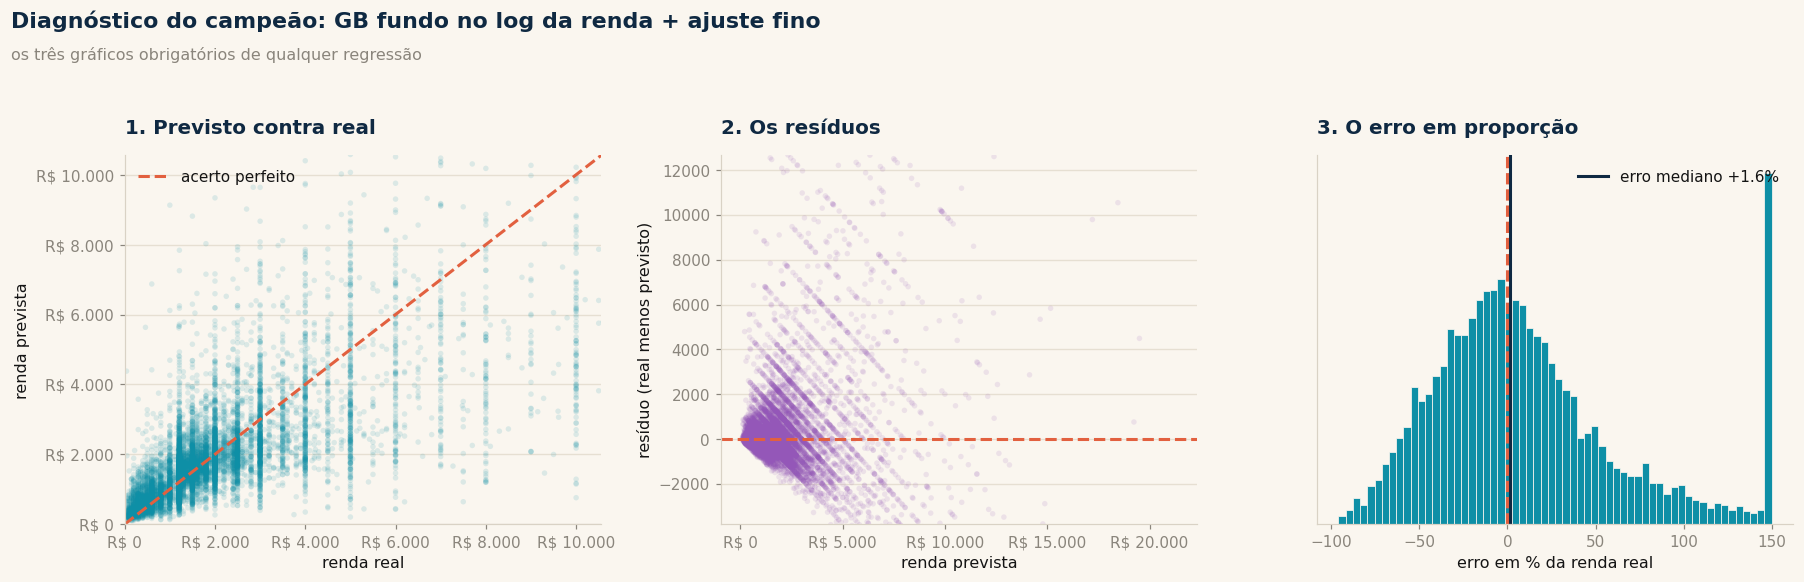

Resíduo médio: R$ 453   (perto de zero = sem viés sistemático para cima ou para baixo)
Metade das previsões erra menos que 30.6% da renda real.


In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# 16.1 OS TRÊS GRÁFICOS DE DIAGNÓSTICO
# ══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Gráficos de diagnóstico.')
p = modelo.predict(X_te)
res = y_te.values - p
lim = float(y_te.quantile(0.97))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
titulo_fig(fig, f'Diagnóstico do campeão: {NOME_CAMPEAO}',
           'os três gráficos obrigatórios de qualquer regressão')

a = axes[0]
a.scatter(y_te, p, alpha=0.13, color=TEAL, s=13, edgecolor='none')
a.plot([0, lim], [0, lim], '--', color=CORAL, lw=2, label='acerto perfeito')
a.set_xlim(0, lim); a.set_ylim(0, lim)
a.set_xlabel('renda real'); a.set_ylabel('renda prevista')
a.set_title('1. Previsto contra real'); a.legend(); grade(a)
eixo_reais(a, 'x'); eixo_reais(a, 'y')

a = axes[1]
a.scatter(p, res, alpha=0.13, color=ROXO, s=13, edgecolor='none')
a.axhline(0, color=CORAL, ls='--', lw=2)
a.set_ylim(np.quantile(res, 0.01), np.quantile(res, 0.99))
a.set_xlabel('renda prevista'); a.set_ylabel('resíduo (real menos previsto)')
a.set_title('2. Os resíduos'); grade(a); eixo_reais(a, 'x')

a = axes[2]
ok = y_te.values > 0
erro_pct = (p[ok] - y_te.values[ok]) / y_te.values[ok] * 100
a.hist(np.clip(erro_pct, -150, 150), bins=60, color=TEAL, edgecolor=CREME, linewidth=0.5)
a.axvline(0, color=CORAL, ls='--', lw=2)
a.axvline(np.median(erro_pct), color=NAVY, lw=2,
          label=f'erro mediano {np.median(erro_pct):+.1f}%')
a.set_xlabel('erro em % da renda real'); a.set_yticks([])
a.set_title('3. O erro em proporção'); a.legend(); grade(a)
plt.tight_layout(); plt.show()

print(f'Resíduo médio: {brl(res.mean())}   (perto de zero = sem viés sistemático para cima ou para baixo)')
print(f'Metade das previsões erra menos que {np.median(np.abs(erro_pct)):.1f}% da renda real.')

**📖 Como ler os três gráficos:**

**1. Previsto contra real.** Se o modelo fosse perfeito, todos os pontos ficariam sobre a linha
tracejada. O padrão que aparece na prática é uma nuvem mais **achatada** que a diagonal: o modelo
prevê alto demais para quem ganha pouco e baixo demais para quem ganha muito. Isso tem nome,
**regressão à média**, e é o comportamento esperado de qualquer modelo com variáveis limitadas.
Ele não inventa extremo que não consegue justificar, e isso é prudência, não falha.

**2. Os resíduos.** A nuvem deve estar espalhada em torno do zero, sem desenho. Se ela formasse um
funil ou uma curva, seria sinal de que falta estrutura no modelo. Um pouco de funil aqui é a cauda
da renda, e já era esperado desde a Parte 7.

**3. O erro em proporção.** Este é o gráfico que faz justiça a um modelo de renda: errar R$ 500 numa
renda de R$ 1.000 é um erro enorme; errar os mesmos R$ 500 numa renda de R$ 20.000 é quase nada.
O erro percentual trata os dois casos pelo que eles são.

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# 16.2 O MODELO ERRA IGUAL PARA TODO MUNDO? (auditoria de justiça do modelo)
# ══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Auditoria do erro por grupo.')

aud = X_te.copy()
aud['real'], aud['previsto'] = y_te.values, p
aud['erro_abs'] = np.abs(aud['previsto'] - aud['real'])
aud['erro_pct'] = (aud['previsto'] - aud['real']) / aud['real'] * 100
aud['grupo_racial'] = extras_te['grupo_racial'].values if 'grupo_racial' in extras_te else None

def auditar(col):
    t = aud.groupby(col, observed=True).agg(
        pessoas=('real', 'size'), MAE=('erro_abs', 'mean'),
        erro_pct_mediano=('erro_pct', 'median'), vies_medio=('erro_pct', 'mean')).round(1)
    return t.reset_index()

for c in existe('sexo', 'raca_cor'):
    tabela(auditar(c), f'Erro do modelo por {c}', casas=1)
if aud['grupo_racial'].notna().any():
    tabela(auditar('grupo_racial'), 'Erro do modelo por grupo racial', casas=1)

print('COMO LER: MAE parecido entre os grupos = o modelo mede todo mundo com a mesma precisão.')
print('  A coluna "vies_medio" é a mais importante: se ela for positiva para um grupo, o modelo')
print('  está SUPERESTIMANDO a renda dele; se for negativa, está subestimando. Um viés grande e')
print('  de sinais opostos entre grupos comprometeria toda a leitura de desigualdade do trabalho.')

👑 Auditoria do erro por grupo.  Modelo em uso: GB fundo no log da renda + ajuste fino


sexo,pessoas,MAE,erro_pct_mediano,vies_medio
homem,5.824,"1.329,8","2,3","22,3"
mulher,4.192,"938,2","1,3","21,6"


raca_cor,pessoas,MAE,erro_pct_mediano,vies_medio
amarela,77,"1.392,8","11,6","35,7"
branca,4.070,"1.655,1","2,6","24,9"
ignorada,1,"1.310,8","108,1","108,1"
indigena,55,"665,9","1,2","22,4"
parda,4.751,"830,8","0,7","20,4"
preta,1.062,"799,2","1,7","16,7"


COMO LER: MAE parecido entre os grupos = o modelo mede todo mundo com a mesma precisão.
  A coluna "vies_medio" é a mais importante: se ela for positiva para um grupo, o modelo
  está SUPERESTIMANDO a renda dele; se for negativa, está subestimando. Um viés grande e
  de sinais opostos entre grupos comprometeria toda a leitura de desigualdade do trabalho.


---
# Parte 17 · A resposta do TCC

Tudo o que veio antes existe para tornar esta parte confiável. Aqui a gente responde,
com o modelo campeão, a pergunta que abriu o trabalho.

👑 Peso das variáveis.  Modelo em uso: GB fundo no log da renda + ajuste fino


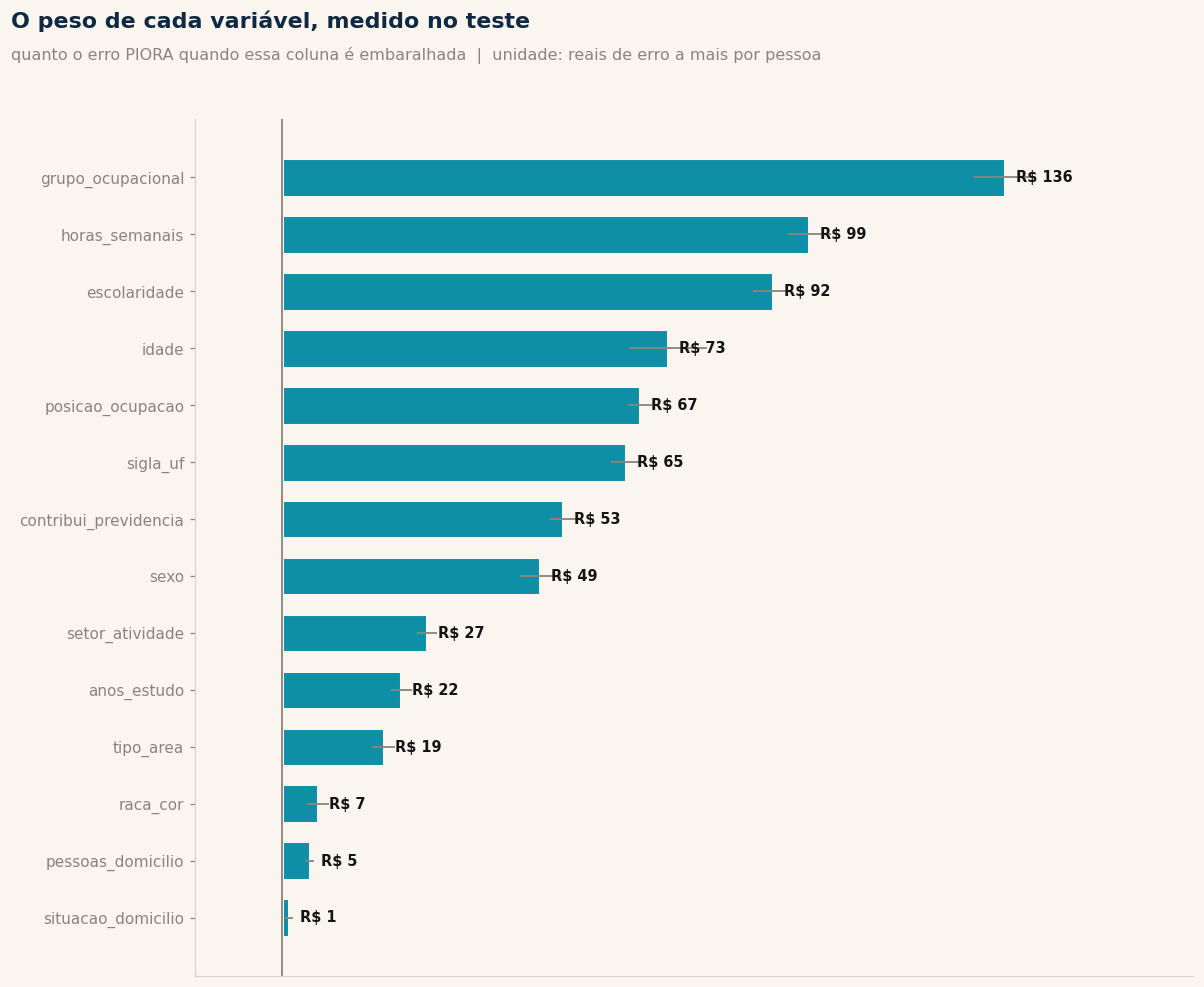

variável,piora do erro (R$),desvio
grupo_ocupacional,"135,8","5,8"
horas_semanais,"99,0","4,0"
escolaridade,"92,2","3,7"
idade,"72,5","7,3"
posicao_ocupacao,"67,2","2,3"
sigla_uf,"64,6","2,8"
contribui_previdencia,"52,8","2,5"
sexo,"48,5","3,8"
setor_atividade,"27,3","2,0"
anos_estudo,"22,4","2,0"


Barra cinza ou perto de zero: embaralhar a coluna quase não muda o erro, ou seja,
o modelo praticamente não estava usando aquela variável para prever.


In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.1 O PESO DE CADA VARIÁVEL (importância por permutação)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.inspection import permutation_importance
modelo = usar_campeao('Peso das variáveis.')

imp = permutation_importance(modelo, X_te, y_te, scoring='neg_mean_absolute_error',
                             n_repeats=6, random_state=SEMENTE, n_jobs=-1)
pesos = (pd.DataFrame({'variável': X_te.columns,
                       'piora do erro (R$)': imp.importances_mean,
                       'desvio': imp.importances_std})
         .sort_values('piora do erro (R$)', ascending=False).reset_index(drop=True))

fig, ax = painel('O peso de cada variável, medido no teste',
                 'quanto o erro PIORA quando essa coluna é embaralhada  |  '
                 'unidade: reais de erro a mais por pessoa', figsize=(11, 0.42*len(pesos)+2.6))
t = pesos.iloc[::-1]
maxv = float(pesos['piora do erro (R$)'].max())
minv = float(min(0, pesos['piora do erro (R$)'].min()))
ax.barh(t['variável'], t['piora do erro (R$)'], xerr=t['desvio'],
        color=[CINZA if v <= 0 else TEAL for v in t['piora do erro (R$)']],
        edgecolor=CREME, linewidth=2, height=0.68, error_kw={'ecolor': CINZA, 'lw': 1.2})
ax.axvline(0, color=CINZA, lw=1.2)
ax.set_xlim(minv - maxv*0.12, maxv*1.26); ax.set_xticks([]); grade(ax, 'x')
for i, v in enumerate(t['piora do erro (R$)']):
    ax.text(max(v, 0) + maxv*0.015, i, brl(abs(v) if abs(v) < 0.5 else v),
            va='center', fontsize=9.5, fontweight='bold')
plt.tight_layout(); plt.show()
tabela(pesos, casas=1)
print('Barra cinza ou perto de zero: embaralhar a coluna quase não muda o erro, ou seja,')
print('o modelo praticamente não estava usando aquela variável para prever.')

**📖 Como ler, e a unidade aqui é o presente que este gráfico dá para o TCC: a barra está em reais.**
"Embaralhar a coluna jornada piora o erro do modelo em R$ X por pessoa" é uma frase que qualquer
pessoa entende, sem precisar saber o que é importância de árvore.

**Por que permutação e não o `.feature_importances_` que o modelo já traz?** Três motivos, e os três
valem citação no trabalho:

1. A importância interna é medida **no treino** e mede o quanto o modelo **usou** a variável, inclusive
   para decorar. A permutação é medida **no teste** e mede o quanto a variável ajuda a **prever dados novos**.
2. A permutação trabalha na variável **original**. Como a coluna é embaralhada **antes** do Pipeline,
   `sigla_uf` aparece como **uma linha só**, e não como 27 coluninhas espalhadas pelo gráfico.
3. Funciona para qualquer campeão, inclusive os que não têm importância interna nenhuma.

> ### ⚠️ A leitura errada mais perigosa deste gráfico
> Se `sexo` e `raca_cor` aparecerem com barras pequenas, **isso não significa que a desigualdade é
> pequena**. Significa que, para **prever** renda, escolaridade e ocupação carregam mais informação.
> São duas perguntas diferentes: "o que mais ajuda a adivinhar a renda?" e "quanto muda a renda
> quando só gênero e raça mudam?". Quem responde a segunda é o contrafactual, logo abaixo.

👑 Direção do efeito.  Modelo em uso: GB fundo no log da renda + ajuste fino


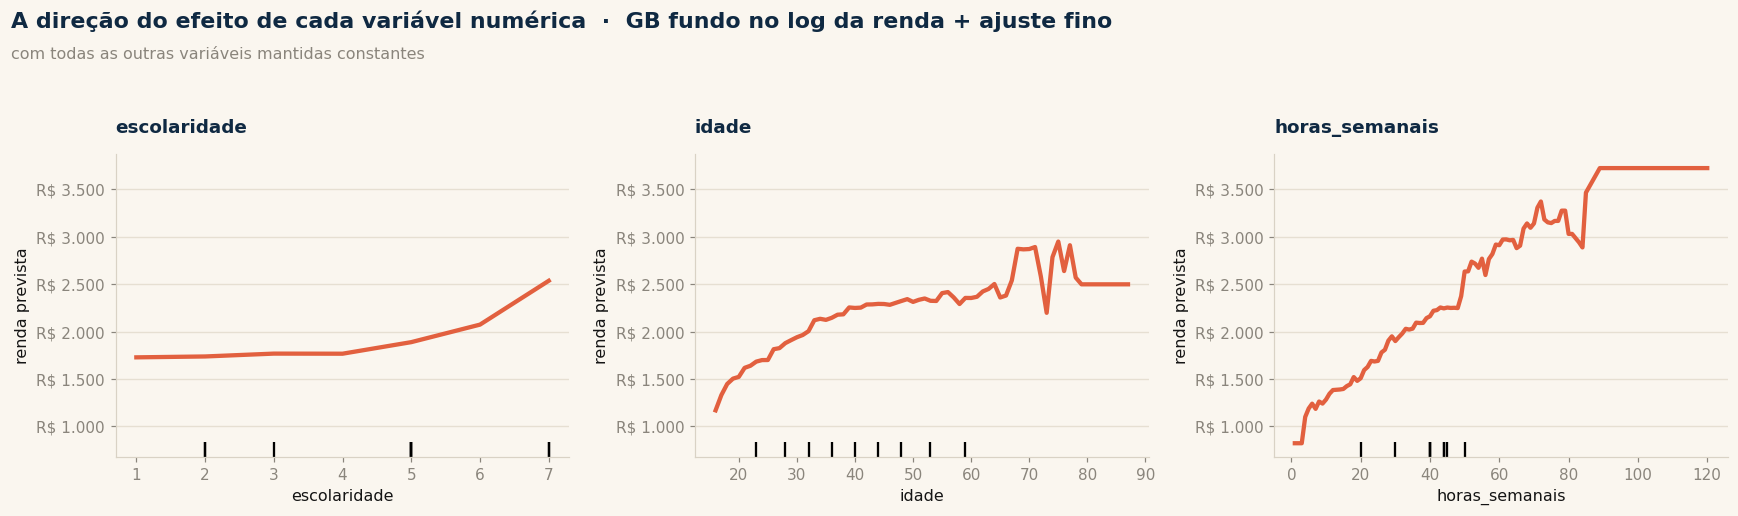

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.2 PARA QUE LADO CADA VARIÁVEL EMPURRA A RENDA
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.inspection import PartialDependenceDisplay
modelo = usar_campeao('Direção do efeito.')

vars_pdp = [v for v in ['escolaridade', 'idade', 'horas_semanais'] if v in X_te.columns]
X_pdp = X_te.copy()
for c in vars_pdp: X_pdp[c] = X_pdp[c].astype(float)

fig, axes = plt.subplots(1, len(vars_pdp), figsize=(5.3*len(vars_pdp), 4.2))
axes = np.atleast_1d(axes)
PartialDependenceDisplay.from_estimator(modelo, X_pdp, features=vars_pdp, ax=axes,
                                        line_kw={'color': CORAL, 'linewidth': 2.8})
for a, v in zip(axes, vars_pdp):
    a.set_title(v, fontsize=12, fontweight='bold', color=NAVY)
    a.set_ylabel('renda prevista'); grade(a); eixo_reais(a)
titulo_fig(fig, f'A direção do efeito de cada variável numérica  ·  {NOME_CAMPEAO}',
           'com todas as outras variáveis mantidas constantes')
plt.tight_layout(); plt.show()

**📖 Como ler:** a linha subindo quer dizer que valores maiores daquela variável aumentam a renda
prevista, **mantendo todo o resto igual**.

Três leituras esperadas, e cada uma vira uma frase no TCC:
- **escolaridade:** uma escada subindo, com um degrau maior no ensino superior. É o prêmio do diploma,
  o mesmo que a H3 mostrou na descritiva, agora com as outras variáveis controladas.
- **idade:** sobe e depois estabiliza ou cai. É o ciclo da carreira. Repare que a linha é **curva**:
  uma regressão linear seria obrigada a desenhar uma reta aqui e perderia esse formato.
- **jornada:** sobe, e é a confirmação do óbvio que precisa estar medido: mais horas remuneradas,
  mais renda no mês.

👑 Experimento contrafactual de gênero.  Modelo em uso: GB fundo no log da renda + ajuste fino
AS MESMAS 10.016 PESSOAS DO TESTE, mudando apenas o gênero
  renda mediana prevista como MULHER: R$ 1.467
  renda mediana prevista como HOMEM:  R$ 1.782

  DUAS FORMAS DE RESUMIR A MESMA COISA, e elas dão números diferentes:
   (a) diferença entre as duas MEDIANAS ....... 17.7%
   (b) MEDIANA das diferenças individuais ..... 20.0%

  em quantos perfis o homem ganha mais? 99.6% dos casos
  diferença mediana em reais: R$ 337 por mês, R$ 4.042 por ano


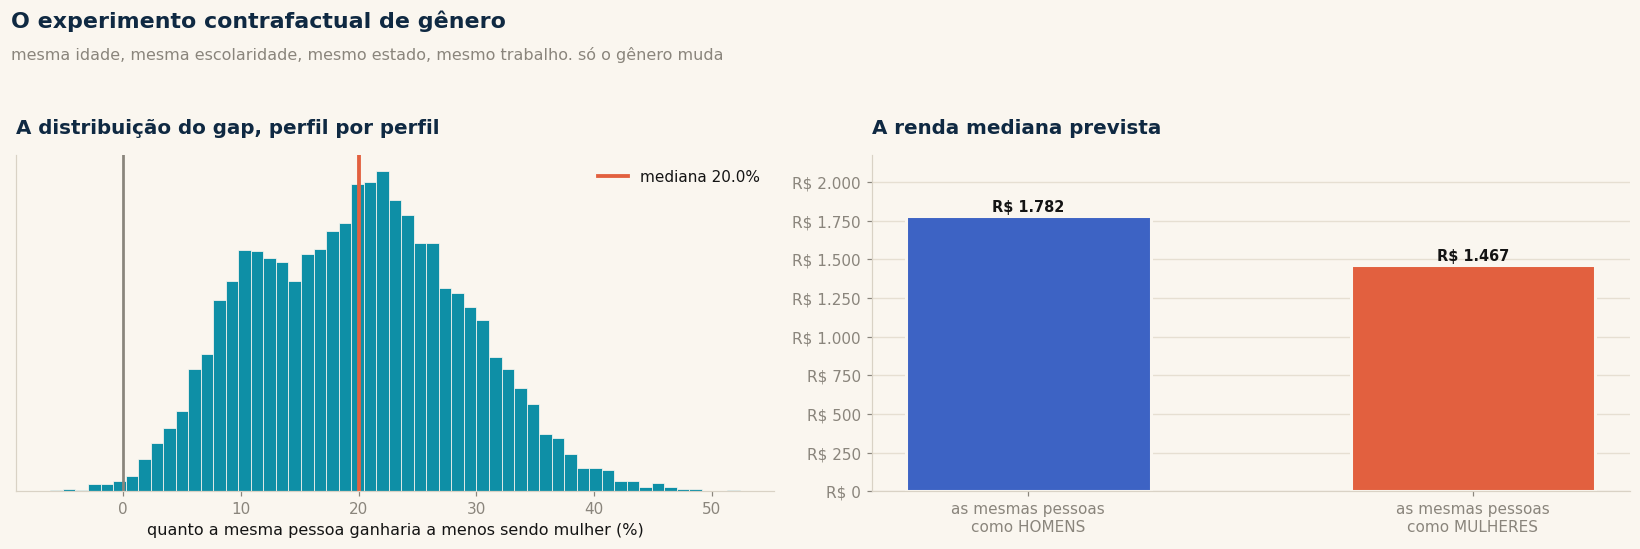

In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.3 O CONTRAFACTUAL: as MESMAS pessoas, mudando só o gênero
# ══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Experimento contrafactual de gênero.')

como_mulher = X_te.copy(); como_mulher['sexo'] = 'mulher'
como_homem  = X_te.copy(); como_homem['sexo']  = 'homem'
prev_m, prev_h = modelo.predict(como_mulher), modelo.predict(como_homem)

gap_individual = (prev_h - prev_m) / prev_h * 100          # o gap de CADA pessoa
gap_das_medianas = gap_pct(np.median(prev_h), np.median(prev_m))  # o gap das MEDIANAS

print(f'AS MESMAS {num(len(X_te))} PESSOAS DO TESTE, mudando apenas o gênero')
print('='*74)
print(f'  renda mediana prevista como MULHER: {brl(np.median(prev_m))}')
print(f'  renda mediana prevista como HOMEM:  {brl(np.median(prev_h))}')
print(f'\n  DUAS FORMAS DE RESUMIR A MESMA COISA, e elas dão números diferentes:')
print(f'   (a) diferença entre as duas MEDIANAS ....... {gap_das_medianas:.1f}%')
print(f'   (b) MEDIANA das diferenças individuais ..... {np.median(gap_individual):.1f}%')
print(f'\n  em quantos perfis o homem ganha mais? {(gap_individual > 0).mean()*100:.1f}% dos casos')
print(f'  diferença mediana em reais: {brl(np.median(prev_h - prev_m))} por mês, '
      f'{brl(np.median(prev_h - prev_m)*12)} por ano')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
titulo_fig(fig, 'O experimento contrafactual de gênero',
           'mesma idade, mesma escolaridade, mesmo estado, mesmo trabalho. só o gênero muda')
a = axes[0]
a.hist(np.clip(gap_individual, -30, 60), bins=55, color=TEAL, edgecolor=CREME, linewidth=0.5)
a.axvline(0, color=CINZA, lw=1.8)
a.axvline(np.median(gap_individual), color=CORAL, lw=2.5,
          label=f'mediana {np.median(gap_individual):.1f}%')
a.set_xlabel('quanto a mesma pessoa ganharia a menos sendo mulher (%)')
a.set_yticks([]); a.set_title('A distribuição do gap, perfil por perfil'); a.legend(); grade(a)

a = axes[1]
a.bar([0, 1], [np.median(prev_h), np.median(prev_m)],
      color=[COR_SEXO['homem'], COR_SEXO['mulher']], edgecolor=CREME, linewidth=2, width=0.55)
a.set_xticks([0, 1]); a.set_xticklabels(['as mesmas pessoas\ncomo HOMENS',
                                         'as mesmas pessoas\ncomo MULHERES'])
a.set_ylim(0, max(np.median(prev_h), np.median(prev_m))*1.22)
rotulos_v(a, [np.median(prev_h), np.median(prev_m)])
a.set_title('A renda mediana prevista'); grade(a); eixo_reais(a)
plt.tight_layout(); plt.show()

**📖 Como ler o contrafactual, e por que ele é mais forte do que comparar duas pessoas inventadas:**

Um perfil isolado pode ser um ponto fora da curva e não sustenta conclusão nenhuma. Aqui o
experimento roda sobre **milhares de perfis reais** do conjunto de teste e olha a distribuição inteira.

**Sobre os dois números do gap serem diferentes:** isso confunde muita gente e a explicação é
simples. A **mediana das diferenças** não é a **diferença das medianas**. O primeiro número responde
"para a pessoa típica, quanto muda?"; o segundo responde "entre os dois cenários inteiros, quanto o
centro se desloca?". Os dois estão certos, medem coisas diferentes, e **o trabalho precisa dizer
qual dos dois está reportando**. A recomendação aqui: use a **mediana das diferenças individuais**,
porque ela é a que corresponde à frase "a mesma pessoa, mudando só o gênero".

**A ressalva que vai junto, sempre:** o modelo estima uma **associação** em dados observacionais.
Ele mostra o padrão que o mercado praticou, não prova o mecanismo. A redação segura é:
*"mantidas constantes as variáveis observáveis do modelo, estima-se uma diferença de X% associada
ao gênero"*.

👑 Ranking gênero x raça.  Modelo em uso: GB fundo no log da renda + ajuste fino


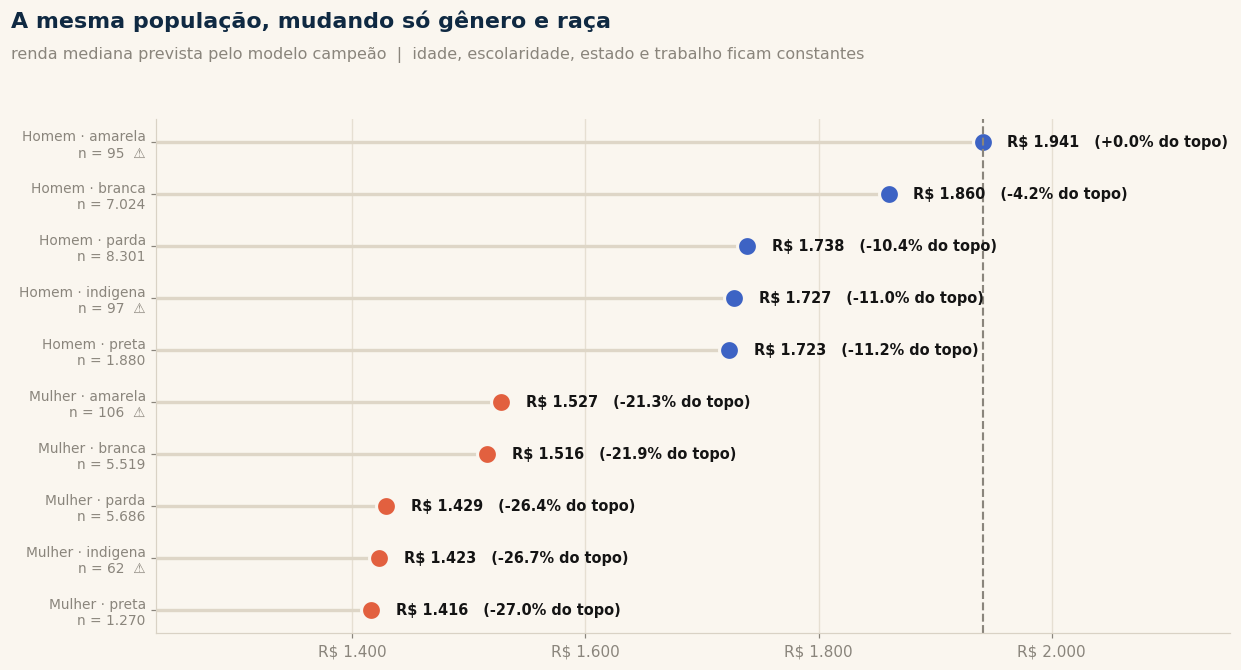

Atenção ao eixo: ele NÃO começa no zero, de propósito. Como os valores são próximos,
barras a partir do zero esconderiam a diferença. O ponto mostra a posição relativa.


perfil,renda prevista,casos no treino,distância do topo,confiança
Mulher · preta,"1.415,9",1.270,"-27,0",ok
Mulher · indigena,"1.423,2",62,"-26,7",⚠️ poucos casos
Mulher · parda,"1.429,2",5.686,"-26,4",ok
Mulher · branca,"1.515,8",5.519,"-21,9",ok
Mulher · amarela,"1.527,3",106,"-21,3",⚠️ poucos casos
Homem · preta,"1.723,0",1.880,"-11,2",ok
Homem · indigena,"1.727,4",97,"-11,0",⚠️ poucos casos
Homem · parda,"1.738,5",8.301,"-10,4",ok
Homem · branca,"1.860,0",7.024,"-4,2",ok
Homem · amarela,"1.940,6",95,"0,0",⚠️ poucos casos


Mediana dos perfis femininos:  R$ 1.429
Mediana dos perfis masculinos: R$ 1.738
Separação entre as duas metades: 17.8%

✅ ACHADO ROBUSTO: TODOS os perfis femininos ficam abaixo de TODOS os masculinos.
⚠️  Perfis com poucos casos no treino (ordem não confiável): Mulher · indigena, Mulher · amarela, Homem · indigena, Homem · amarela


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.4 O RANKING GÊNERO x RAÇA: as mesmas pessoas, todas as combinações
# ══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Ranking gênero x raça.')

racas_ok = [r for r in ['branca', 'parda', 'preta', 'amarela', 'indigena']
            if r in X_tr['raca_cor'].unique()]
linhas_rank = []
for g in ['homem', 'mulher']:
    for r in racas_ok:
        tmp = X_te.copy(); tmp['sexo'] = g; tmp['raca_cor'] = r
        linhas_rank.append({
            'perfil': f'{g.capitalize()} · {r}',
            'renda prevista': float(np.median(modelo.predict(tmp))),
            'casos no treino': int(((X_tr['sexo'] == g) & (X_tr['raca_cor'] == r)).sum())})
rank = pd.DataFrame(linhas_rank).sort_values('renda prevista').reset_index(drop=True)
topo_r = rank['renda prevista'].max()
rank['distância do topo'] = ((rank['renda prevista']/topo_r - 1)*100).round(1)
rank['confiança'] = np.where(rank['casos no treino'] < 200, '⚠️ poucos casos', 'ok')

# gráfico de PONTOS, e não de barras: quando os valores são próximos, a barra a partir
# do zero esconde a diferença. O ponto mostra a distância entre os grupos.
fig, ax = painel('A mesma população, mudando só gênero e raça',
                 'renda mediana prevista pelo modelo campeão  |  '
                 'idade, escolaridade, estado e trabalho ficam constantes', figsize=(11.5, 5.6))
cores_rk = [COR_SEXO['mulher'] if p.startswith('Mulher') else COR_SEXO['homem'] for p in rank['perfil']]
piso_x = float(rank['renda prevista'].min()) - (topo_r - float(rank['renda prevista'].min()) + 1)*0.35
for i, (v, c) in enumerate(zip(rank['renda prevista'], cores_rk)):
    ax.plot([piso_x, v], [i, i], color='#ded6c7', lw=2.2, zorder=1)
    ax.plot(v, i, 'o', color=c, markersize=13, markeredgecolor=CREME, markeredgewidth=2, zorder=2)
ax.axvline(topo_r, color=CINZA, ls='--', lw=1.4)
ax.set_yticks(range(len(rank)))
ax.set_yticklabels([f"{p}\nn = {num(n)}{'  ⚠️' if n < 200 else ''}"
                    for p, n in zip(rank['perfil'], rank['casos no treino'])], fontsize=9)
ax.set_xlim(piso_x, topo_r + (topo_r - piso_x)*0.30); grade(ax, 'x'); eixo_reais(ax, 'x')
for i, (v, d) in enumerate(zip(rank['renda prevista'], rank['distância do topo'])):
    ax.text(v + (topo_r - piso_x)*0.03, i, f'{brl(v)}   ({d:+.1f}% do topo)',
            va='center', fontsize=9.5, fontweight='bold')
plt.tight_layout(); plt.show()
print('Atenção ao eixo: ele NÃO começa no zero, de propósito. Como os valores são próximos,')
print('barras a partir do zero esconderiam a diferença. O ponto mostra a posição relativa.')
tabela(rank, casas=1)

fem = rank[rank['perfil'].str.startswith('Mulher')]
mas = rank[rank['perfil'].str.startswith('Homem')]
print(f"Mediana dos perfis femininos:  {brl(fem['renda prevista'].median())}")
print(f"Mediana dos perfis masculinos: {brl(mas['renda prevista'].median())}")
print(f"Separação entre as duas metades: "
      f"{gap_pct(mas['renda prevista'].median(), fem['renda prevista'].median()):.1f}%")
if fem['renda prevista'].max() < mas['renda prevista'].min():
    print('\n✅ ACHADO ROBUSTO: TODOS os perfis femininos ficam abaixo de TODOS os masculinos.')
else:
    print('\n⚠️  Os perfis femininos e masculinos se sobrepõem: a separação por gênero não é total.')
frageis = rank[rank['casos no treino'] < 200]['perfil'].tolist()
if frageis:
    print('⚠️  Perfis com poucos casos no treino (ordem não confiável):', ', '.join(frageis))

**📖 Como ler o ranking, e é ele que fecha o projeto:**

Todas as barras representam **a mesma população**, com as mesmas idades, as mesmas escolaridades,
os mesmos estados e o mesmo tipo de trabalho. A **única** coisa que muda de uma barra para a outra
é gênero e raça. Se esses dois atributos não mudassem nada quando todo o resto é igual, as barras
teriam o mesmo tamanho.

**Para a apresentação, este é o slide.** Uma frase basta: *"pessoas idênticas em idade, escolaridade,
estado e ocupação, e a renda prevista varia X% conforme gênero e raça"*.

**E as duas ressalvas que vão junto, sempre:**
1. Perfis marcados com ⚠️ têm poucos casos no treino. A ordem **entre eles** não é confiável.
   O achado robusto é a separação entre as duas metades, não a ordem fina de cada degrau.
2. O modelo mede associação, não causa.

Treinando o modelo COMPANHEIRO (conjunto A: sem as variáveis de trabalho),
com exatamente o mesmo algoritmo e a mesma configuração do campeão.



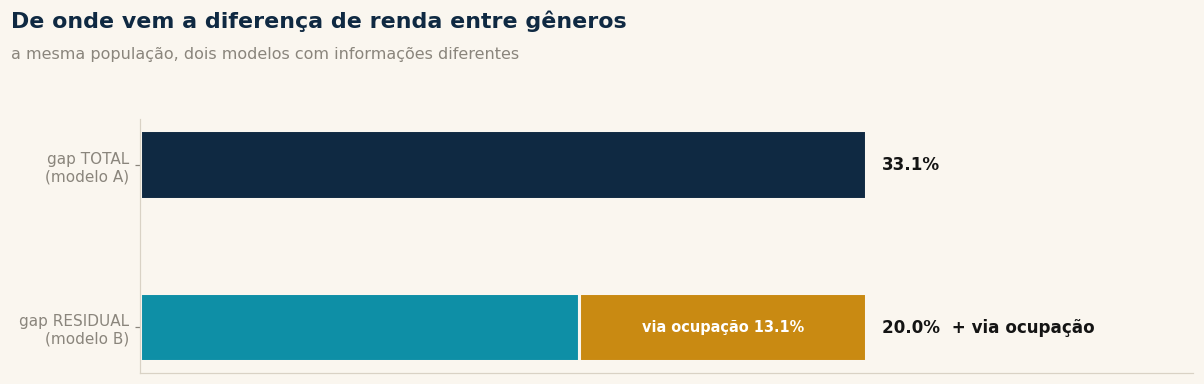

  Gap TOTAL de gênero (modelo A, sem controlar ocupação):       33.1%
  Gap RESIDUAL (modelo B, dentro do mesmo posto de trabalho):   20.0%
  Diferença entre os dois:                                      13.1%
  Leitura: essa diferença é a parcela do gap que passa pela SEGREGAÇÃO
  OCUPACIONAL, ou seja, pelo fato de mulheres e homens estarem distribuídos
  de forma desigual entre ocupações, setores, jornadas e vínculos.


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# 17.5 A DECOMPOSIÇÃO: quanto do gap passa pela ocupação
#      Esta é a ÚNICA seção que usa dois modelos, e é de propósito.
# ══════════════════════════════════════════════════════════════════════════════
if TEM_TRABALHO:
    def motor_do(est):
        p_ = est.regressor if isinstance(est, TransformedTargetRegressor) else est
        return p_.named_steps['modelo']

    print('Treinando o modelo COMPANHEIRO (conjunto A: sem as variáveis de trabalho),')
    print('com exatamente o mesmo algoritmo e a mesma configuração do campeão.\n')
    COMPANHEIRO_A = fluxo(motor_do(CAMPEAO), NUM_A, CAT_A, em_log=EM_LOG)
    COMPANHEIRO_A.fit(X_tr[NUM_A+CAT_A], y_tr)

    def gap_contrafactual(est, X_base):
        m_ = X_base.copy(); m_['sexo'] = 'mulher'
        h_ = X_base.copy(); h_['sexo'] = 'homem'
        pm, ph = est.predict(m_), est.predict(h_)
        return float(np.median((ph - pm) / ph * 100))

    gap_A = gap_contrafactual(COMPANHEIRO_A, X_te[NUM_A+CAT_A])
    gap_B = gap_contrafactual(CAMPEAO, X_te)
    via_ocupacao = gap_A - gap_B

    fig, ax = painel('De onde vem a diferença de renda entre gêneros',
                     'a mesma população, dois modelos com informações diferentes',
                     figsize=(11, 3.0))
    ax.barh([1], [gap_A], color=NAVY,  edgecolor=CREME, linewidth=2, height=0.42)
    ax.barh([0], [gap_B], color=TEAL,  edgecolor=CREME, linewidth=2, height=0.42)
    if via_ocupacao > 0:
        ax.barh([0], [via_ocupacao], left=[gap_B], color=AMBAR,
                edgecolor=CREME, linewidth=2, height=0.42)
        ax.text(gap_B + via_ocupacao/2, 0, f'via ocupação {via_ocupacao:.1f}%',
                va='center', ha='center', color='white', fontweight='bold', fontsize=9.5)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['gap RESIDUAL\n(modelo B)', 'gap TOTAL\n(modelo A)'], fontsize=10)
    lim_x = max(gap_A, gap_B, 0.1)*1.45
    ax.set_xlim(min(0, gap_A, gap_B)*1.2, lim_x); ax.set_xticks([]); grade(ax, 'x')
    ax.text(gap_A + lim_x*0.015, 1, f'{gap_A:.1f}%', va='center', fontweight='bold', fontsize=11)
    ax.text(max(gap_B, 0) + lim_x*0.015 + (via_ocupacao if via_ocupacao > 0 else 0), 0,
            f'{gap_B:.1f}%' + ('  + via ocupação' if via_ocupacao > 0 else ''),
            va='center', fontweight='bold', fontsize=11)
    plt.tight_layout(); plt.show()

    print('='*74)
    print(f'  Gap TOTAL de gênero (modelo A, sem controlar ocupação):     {gap_A:>6.1f}%')
    print(f'  Gap RESIDUAL (modelo B, dentro do mesmo posto de trabalho): {gap_B:>6.1f}%')
    print(f'  Diferença entre os dois:                                    {via_ocupacao:>6.1f}%')
    print('='*74)
    if via_ocupacao > 0:
        print('  Leitura: essa diferença é a parcela do gap que passa pela SEGREGAÇÃO')
        print('  OCUPACIONAL, ou seja, pelo fato de mulheres e homens estarem distribuídos')
        print('  de forma desigual entre ocupações, setores, jornadas e vínculos.')
    else:
        print('  Leitura: aqui o gap residual ficou MAIOR que o total. Isso acontece quando,')
        print('  DENTRO da mesma ocupação e da mesma jornada, a diferença é maior do que a')
        print('  média geral sugere. Não é erro: é um resultado, e merece um parágrafo no TCC.')
else:
    print('Sem as colunas de trabalho não dá para fazer a decomposição. '
          'Ela é uma das partes mais fortes do TCC: vale rodar a consulta completa.')

**📖 Como ler a decomposição, que é o resultado mais sofisticado do trabalho:**

O gap **total** é o que uma mulher encontra no mercado de trabalho: ele inclui o fato de que ela é
empurrada para ocupações, setores e vínculos que pagam menos.

O gap **residual** é o que sobra **depois** de comparar pessoas na mesma ocupação, com a mesma
jornada e a mesma formalidade. É a diferença que existe **dentro do mesmo tipo de trabalho**.

**A diferença entre os dois é a segregação ocupacional**: a parte da desigualdade que não acontece na
hora de definir o salário, e sim antes, na hora de definir **quem entra em qual trabalho**.

**Por que isso importa politicamente:** as duas parcelas pedem políticas diferentes. O gap residual
pede transparência salarial e fiscalização de igualdade de remuneração. A parcela que passa pela
ocupação pede creche, licença parental compartilhada, combate ao assédio e programas de acesso a
carreiras historicamente fechadas. Um trabalho que só mede o total não consegue dizer isso;
o de vocês consegue.

> **E a frase que protege o projeto inteiro:** *o modelo mede a desigualdade que existe nos dados;
> usá-lo para decidir salários seria automatizá-la. Medimos para denunciar e transformar.*

---
# Parte 18 · Salvar o modelo pronto para uso

**🔎 O que vamos fazer:** salvar o campeão **inteiro** com `joblib`, junto de uma ficha técnica,
e provar que funciona carregando do zero.

**Por que o objeto inteiro, e não só o algoritmo:** ele carrega junto todo o preparo (preenchimento,
padronização, codificação das categorias) e, se o campeão treina em log, carrega também a ida e a
volta do logaritmo. Quem abrir o arquivo depois passa **dado cru** e recebe **reais**, sem precisar
de nenhuma célula deste notebook. É isso que permite a camada de IA generativa consumir o modelo.

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.1 SALVAR
# ══════════════════════════════════════════════════════════════════════════════
import joblib
modelo = usar_campeao('Salvando o modelo final.')
p_final = modelo.predict(X_te)

FICHA = {
    'modelo': modelo,
    'nome': NOME_CAMPEAO,
    'treina_em_log': bool(EM_LOG),
    'variaveis': {'numericas': NUM_MAX, 'categoricas': CAT_MAX},
    'categorias_validas': {c: sorted(map(str, X_tr[c].dropna().unique())) for c in CAT_MAX},
    'populacao': '16 anos ou mais, com rendimento de trabalho maior que zero, Brasil, PNAD Contínua 2022',
    'linhas_treino': int(len(X_tr)), 'linhas_teste': int(len(X_te)),
    'metricas_no_teste': avaliar(y_te, p_final),
    'aviso': ('PROTÓTIPO ACADÊMICO. Este modelo descreve a desigualdade presente nos dados da PNAD '
              'e NÃO deve ser usado para decisões sobre pessoas reais, em especial definição de '
              'salário, contratação ou crédito.'),
    'como_usar': 'ficha["modelo"].predict(df) devolve a renda prevista em reais',
}
joblib.dump(FICHA, 'dados/modelo_renda_final.joblib', compress=3)
print(f"Salvo: dados/modelo_renda_final.joblib "
      f"({os.path.getsize('dados/modelo_renda_final.joblib')/1024**2:.2f} MB)\n")
print('FICHA TÉCNICA')
print('='*74)
for k, v in FICHA.items():
    if k != 'modelo': print(f'  {k:<20} {v}')

👑 Salvando o modelo final.  Modelo em uso: GB fundo no log da renda + ajuste fino
Salvo: dados/modelo_renda_final.joblib (0.79 MB)

FICHA TÉCNICA
  nome                 GB fundo no log da renda + ajuste fino
  treina_em_log        True
  variaveis            {'numericas': ['idade', 'escolaridade', 'anos_estudo', 'pessoas_domicilio', 'horas_semanais'], 'categoricas': ['sexo', 'raca_cor', 'sigla_uf', 'situacao_domicilio', 'tipo_area', 'posicao_ocupacao', 'setor_atividade', 'grupo_ocupacional', 'contribui_previdencia']}
  categorias_validas   {'sexo': ['homem', 'mulher'], 'raca_cor': ['amarela', 'branca', 'ignorada', 'indigena', 'parda', 'preta'], 'sigla_uf': ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO'], 'situacao_domicilio': ['rural', 'urbana'], 'tipo_area': ['RIDE', 'capital', 'interior', 'região metropolitana'], 'posicao_ocupacao': ['conta própria', 'doméstica SEM carte

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# 18.2 A PROVA: carregar do zero e comparar quatro pessoas idênticas
# ══════════════════════════════════════════════════════════════════════════════
pacote = joblib.load('dados/modelo_renda_final.joblib')
print(f"Modelo carregado do arquivo: {pacote['nome']}\n")

def perfil_base():
    """Uma pessoa 'mediana' do conjunto de teste, para servir de base da comparação."""
    linha = {}
    for c in NUM_MAX: linha[c] = float(X_tr[c].median())
    for c in CAT_MAX: linha[c] = X_tr[c].mode().iloc[0]
    linha.update({'idade': 35.0, 'escolaridade': 7.0})
    if 'sigla_uf' in linha: linha['sigla_uf'] = 'SP'
    if 'horas_semanais' in linha: linha['horas_semanais'] = 40.0
    return linha

pessoas = pd.DataFrame([{**perfil_base(), 'sexo': s, 'raca_cor': r}
                        for s in ['homem', 'mulher'] for r in ['branca', 'preta']])
pessoas['renda prevista'] = pacote['modelo'].predict(pessoas[NUM_MAX + CAT_MAX])

print('QUATRO PESSOAS IDÊNTICAS: 35 anos, superior completo, SP, mesma ocupação e jornada.')
print('A única diferença entre elas é gênero e raça.\n')
for _, l in pessoas.iterrows():
    print(f"  {l['sexo']:<7} {l['raca_cor']:<8} -> {brl(l['renda prevista']):>12} por mês")
dif = pessoas['renda prevista'].max() - pessoas['renda prevista'].min()
print(f"\n  Da maior para a menor: {brl(dif)} por mês "
      f"({(1 - pessoas['renda prevista'].min()/pessoas['renda prevista'].max())*100:.1f}%)")
print(f"  Ao longo de um ano: {brl(dif*12)}")
display(HTML(f"""<div style="background:#fdece7;border-left:5px solid {CORAL};padding:12px 16px;
  margin:12px 0;border-radius:6px;font-family:system-ui;font-size:14px">
  <b style="color:{CORAL}">⚠️ Aviso obrigatório em toda tela que faz previsão</b><br>
  {pacote['aviso']}</div>"""))

Modelo carregado do arquivo: GB fundo no log da renda + ajuste fino

QUATRO PESSOAS IDÊNTICAS: 35 anos, superior completo, SP, mesma ocupação e jornada.
A única diferença entre elas é gênero e raça.

  homem   branca   ->     R$ 2.765 por mês
  homem   preta    ->     R$ 2.564 por mês
  mulher  branca   ->     R$ 2.057 por mês
  mulher  preta    ->     R$ 1.947 por mês

  Da maior para a menor: R$ 818 por mês (29.6%)
  Ao longo de um ano: R$ 9.811


---
# Parte 19 · Conclusões, limitações e próximos passos

In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# 19.1 O RESUMO EXECUTIVO, montado com os números que ESTE notebook produziu
# ══════════════════════════════════════════════════════════════════════════════
m_final = avaliar(y_te, p_final)
resumo = f"""
RESUMO DO TRABALHO
{'='*74}
POPULAÇÃO
  {num(len(estudo))} pessoas de 16+ com rendimento de trabalho, PNAD Contínua 2022.
  Representam {num(estudo['peso'].sum()) if TEM_PESO else 's/ peso'} brasileiras e brasileiros.

O QUE A DESCRITIVA MOSTROU (valores ponderados)
  renda mediana geral ............ {brl(quantil_pond(estudo['renda'], estudo['peso'] if TEM_PESO else pd.Series(1., index=estudo.index)))}
  índice de Gini ................. {gini:.3f}
  gap de gênero na mediana ....... {gap_pct(res_sexo.loc['homem','mediana'], res_sexo.loc['mulher','mediana']):.1f}%
  gap de gênero na média ......... {gap_pct(res_sexo.loc['homem','média'], res_sexo.loc['mulher','média']):.1f}%

O MODELO
  campeão ........................ {NOME_CAMPEAO}
  variáveis ...................... {len(NUM_MAX)} numéricas + {len(CAT_MAX)} categóricas
  MAE no teste ................... {brl(m_final['MAE (R$)'])}   (o melhor chute constante erra {brl(PISO_MAE)})
  RMSE no teste .................. {brl(m_final['RMSE (R$)'])}
  R² no teste .................... {m_final['R²']}
  erro percentual mediano ........ {m_final['erro % mediano']}%
  ganho sobre o chute ............ {(1 - m_final['MAE (R$)']/PISO_MAE)*100:.1f}% menos erro

A RESPOSTA DO TCC (contrafactual, as mesmas pessoas mudando só gênero)
  gap de gênero estimado ......... {np.median(gap_individual):.1f}%
  perfis em que o homem ganha mais {(gap_individual > 0).mean()*100:.1f}%
"""
if TEM_TRABALHO:
    resumo += f"""  gap TOTAL (modelo A) ........... {gap_A:.1f}%
  gap RESIDUAL (modelo B) ........ {gap_B:.1f}%
  via segregação ocupacional ..... {via_ocupacao:.1f}%
"""
print(resumo)


RESUMO DO TRABALHO
POPULAÇÃO
  40.062 pessoas de 16+ com rendimento de trabalho, PNAD Contínua 2022.
  Representam 18.668.453 brasileiras e brasileiros.

O QUE A DESCRITIVA MOSTROU (valores ponderados)
  renda mediana geral ............ R$ 1.700
  índice de Gini ................. 0.502
  gap de gênero na mediana ....... 16.7%
  gap de gênero na média ......... 22.9%

O MODELO
  campeão ........................ GB fundo no log da renda + ajuste fino
  variáveis ...................... 5 numéricas + 9 categóricas
  MAE no teste ................... R$ 1.166   (o melhor chute constante erra R$ 1.644)
  RMSE no teste .................. R$ 3.049
  R² no teste .................... 0.366
  erro percentual mediano ........ 30.6%
  ganho sobre o chute ............ 29.1% menos erro

A RESPOSTA DO TCC (contrafactual, as mesmas pessoas mudando só gênero)
  gap de gênero estimado ......... 20.0%
  perfis em que o homem ganha mais 99.6%
  gap TOTAL (modelo A) ........... 33.1%
  gap RESIDUAL (modelo 

## O que dá para afirmar, e como escrever cada afirmação

| Afirmação | Redação segura para o TCC |
|---|---|
| Sobre o gap de gênero | *"Mantidas constantes as variáveis observáveis do modelo, estima-se uma diferença de X% na renda do trabalho associada ao gênero, na PNAD Contínua de 2022."* |
| Sobre a mediana igual | *"A igualdade observada na mediana não indica ausência de desigualdade: ela decorre da concentração de homens e mulheres no piso do salário mínimo. A diferença se manifesta acima do piso e cresce ao longo da distribuição."* |
| Sobre raça | *"Pessoas que se declaram pretas ou pardas apresentam renda mediana X% inferior à das que se declaram brancas."* |
| Sobre escolaridade | *"A escolaridade eleva a renda, com prêmio concentrado no ensino superior, mas não elimina a diferença entre gêneros dentro de cada nível."* |
| Sobre a decomposição | *"Parte da diferença total opera pela alocação em ocupações, setores e vínculos distintos, e parte persiste dentro do mesmo posto de trabalho."* |
| Sobre o modelo | *"O modelo estima associações em dados observacionais e não estabelece relação causal."* |

## O que **não** dá para afirmar

- ❌ "Ser mulher **causa** uma perda de X%." O estudo é observacional.
- ❌ "As mulheres trabalham menos." Elas têm jornada **remunerada** menor. O trabalho de cuidado não está nesta base.
- ❌ "O modelo pode estimar quanto uma pessoa deve ganhar." Ele descreve o que o mercado praticou, e o mercado praticou desigualdade.
- ❌ Nada sobre pessoas amarelas e indígenas sem a ressalva do número de casos.

## Limitações do modelo (diferentes das limitações da base, na Parte 9)

1. **R² moderado é o teto destas variáveis.** Falta experiência efetiva, tempo de casa, tamanho da empresa e área de formação.
2. **Previsões em log estimam a mediana condicional**, não a média. Para somar previsões e estimar massa salarial, seria preciso corrigir.
3. **O modelo comprime os extremos.** Ele erra para baixo nas rendas muito altas, como o diagnóstico da Parte 16 mostrou.
4. **A auditoria de erro por grupo precisa ser lida junto com qualquer conclusão.** Se o modelo erra mais para um grupo, a estimativa daquele grupo é menos precisa.
5. **Um ano só.** Não dá para dizer se a desigualdade está aumentando ou diminuindo.

## Próximos passos (a agenda de continuidade do trabalho)

| # | Próximo passo | O que ele acrescenta | Dificuldade |
|---|---|---|---|
| 1 | **Série histórica 2012 a 2024** | Sai da foto e vai para o filme: a desigualdade está caindo, subindo ou parada? | Média: mesma consulta, vários anos |
| 2 | **Decomposição de Oaxaca-Blinder** | O método clássico da economia do trabalho para separar "diferença de características" de "diferença de retorno". Dialoga direto com a Parte 17.5 | Média |
| 3 | **Recorte por região e por setor** | Onde a desigualdade é maior? Isso transforma o achado em pauta de política pública localizada | Baixa |
| 4 | **Incluir maternidade** | A PNAD tem variáveis de composição do domicílio. Comparar mulheres com e sem filhos pequenos mede a penalidade da maternidade | Média |
| 5 | **Modelo por quantil** (regressão quantílica) | Em vez de prever a renda típica, prever o percentil 10 e o 90: é onde o teto de vidro aparece | Alta |
| 6 | **Intervalos de confiança por bootstrap** | Hoje reportamos um número; o certo é reportar uma faixa | Média |
| 7 | **Corrigir o efeito de desenho amostral** | Usar o plano da PNAD nos testes de significância, com `statsmodels` ou `samplics` | Alta |
| 8 | **A camada de IA generativa** | Ler o modelo salvo e explicar a previsão em linguagem natural, sempre com o aviso de protótipo acadêmico | Média |

---
# Parte 20 · Checklist e glossário

## ✅ O checklist do projeto

1. **Consulta rodada uma vez** e guardada em parquet, sem gastar cota à toa.
2. **Raio X completo antes de qualquer limpeza**: tamanho, tipos, vazios, distribuição crua de cada variável e checagem de valores impossíveis.
3. **Dicionário do IBGE aplicado** e conferido: nenhum código ficou sem tradução.
4. **Categorias criadas e mostradas**: cada uma com contagem, percentual na amostra e percentual ponderado.
5. **População do estudo definida em funil**, com o motivo de cada recorte escrito.
6. **Peso amostral no papel certo**: estatísticas descritivas ponderadas, e fora do modelo.
7. **Alvo examinado de quatro ângulos**, incluindo o piso do salário mínimo e o Gini.
8. **Seis hipóteses com mecanismo, gráfico, número e teste estatístico**, e o placar com o veredito de cada uma.
9. **Limitações escritas antes do modelo**, não depois.
10. **Vazamento evitado** de forma explícita (`renda_habitual` e `peso` fora).
11. **Dois conjuntos de variáveis** com papéis distintos, e a diferença entre eles medida.
12. **Treino e teste separados com estratificação por faixa de renda**, e o teste aberto uma única vez.
13. **Régua definida antes**: MAE como critério, com os dois chutes constantes como piso.
14. **Sete famílias comparadas por validação cruzada**, com desvio e tempo na tabela.
15. **Oficina de alavancas**, cada mudança testada isoladamente, e ajuste fino por busca aleatória.
16. **Um campeão eleito uma vez, com trava de código**, e tudo daí em diante feito nele.
17. **Diagnóstico completo**, incluindo a auditoria de erro por grupo.
18. **Contrafactual sobre milhares de perfis reais**, com os dois jeitos de resumir o gap explicados.
19. **Decomposição do gap** em parcela residual e parcela via segregação ocupacional.
20. **Modelo salvo com ficha técnica e aviso de protótipo acadêmico.**

## 📚 Glossário

| Termo | Em português claro |
|---|---|
| **Alvo (target)** | A coluna que o modelo tenta prever. Aqui, a renda |
| **Variável / feature** | Cada coluna que o modelo pode olhar para fazer a previsão |
| **Regressão** | Prever um número. (Prever uma categoria seria classificação) |
| **Treino e teste** | A base de estudar e a prova. A prova é aberta uma vez só |
| **Validação cruzada** | Repartir o treino em pedaços e revezar quem é a prova, para o resultado não depender de sorte |
| **Pipeline** | A esteira que faz preparo e modelo juntos, garantindo que o preparo só aprenda com o treino |
| **Vazamento (leakage)** | Deixar entrar uma informação que, na prática, já contém a resposta |
| **One-hot** | Transformar uma categoria em várias colunas de sim/não |
| **Variável ordinal** | Categoria que tem ordem, como escolaridade. Vale manter como número |
| **MAE** | Erro médio em reais |
| **RMSE** | Erro que pune erro grande |
| **R²** | Fatia do vaivém do alvo que o modelo explica |
| **Baseline / chute constante** | O modelo burro que responde sempre a mesma coisa. É o piso |
| **Hiperparâmetro** | Configuração do modelo, escolhida por fora (profundidade, número de árvores) |
| **Boosting** | Árvores em série, cada uma corrigindo o erro da anterior |
| **Importância por permutação** | Embaralhar uma coluna e medir quanto o erro piora |
| **Dependência parcial (PDP)** | Para que lado uma variável empurra a previsão, com o resto constante |
| **Contrafactual** | "E se essa mesma pessoa fosse de outro gênero?" Mudar uma coisa só e comparar |
| **Peso amostral** | Quantas pessoas do país cada pessoa entrevistada representa |
| **Cauda longa** | Poucos valores muito altos que esticam a distribuição |
| **Mediana** | O valor do meio. Em renda, é mais honesta que a média |
| **Gini** | Resumo da desigualdade em um número de 0 a 1 |
| **Interseccionalidade** | Desvantagens que se acumulam na mesma pessoa e não se somam de forma simples |
| **Segregação ocupacional** | A desigualdade que acontece na alocação das pessoas em cada tipo de trabalho |

---

<div style="background:#0f2942;color:#faf6ef;padding:22px 28px;border-radius:12px;margin-top:16px">
<b style="font-size:16px">Dado é gente.</b><br>
Cada linha desta base é uma brasileira ou um brasileiro respondendo sobre a própria vida.
O número que sai daqui não é um placar: é uma medida de quanto o mercado de trabalho cobra
de alguém por ser mulher, por ser negra, ou pelas duas coisas ao mesmo tempo.
<br><br>
<b>Grupo 1 · Turma Fly · TCC 2026</b>
</div>